In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install flowio

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for flowio: filename=flowio-1.4.0-py3-none-any.whl size=21898 sha256=d4198b348f9141e7dc48215cdbb79d0fae6586118b9126f69917add955f3d2dd
  Stored in directory: /root/.cache/pip/wheels/8b/6d/0e/187be3e520a5baa75a82dc8b3097ba017869e67af8255d2fc2
Successfully built flowio


In [ ]:
import shutil
import pandas as pd
import random
import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging
import os
import math

PYTHONHASHSEED = '42'
TF_DETERMINISTIC_OPS = '1'
TF_CUDNN_DETERMINISTIC = '1'
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # For CuDNN ops

import glob
import json
import tensorflow as tf
import sys
import pickle
import time
import csv
import traceback
import gc

from sklearn import metrics
from sklearn.metrics import f1_score
from sklearn.metrics import fbeta_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve


In [ ]:

fixed_path = '/content/drive/MyDrive/0.Master_Thesis/'

if fixed_path not in sys.path:
    sys.path.append(fixed_path)

cellcnn_path = f'{fixed_path}CellCNN/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)

model_path = f'{cellcnn_path}Old_CellCNN/'
if model_path not in sys.path:
    sys.path.append(model_path)

save_path = f'{cellcnn_path}results/'
if save_path not in sys.path:
    sys.path.append(save_path)

modules_dir = f'{cellcnn_path}modules/'
if modules_dir not in sys.path:
    sys.path.append(modules_dir)

In [ ]:
decache_files = ['timepoints_elaboration', 'model_grid', 'run_models', 'new_datasets_generation',
                'training', 'utils', 'cv_folds', 'classification', 'plotting']

# Remove from cache
from utils import remove_from_cache
remove_from_cache(decache_files)

from model_grid import CellCnn

from timepoints_elaboration import load_data, donation_extraction
from run_models import  trials_train_CellCNN_old, trials_test_CellCNN_old
from new_datasets_generation import splitting_and_dataset_elaboration

from training import run_training, val_res_pred, train_val_finalizing, test_res_pred, find_theta_best
from utils import flatten, remove_labels, retrieve_labels, show_blast_distribution_perc
from utils import prepare_results_to_save, subset_sampling, generate_seeds
from utils import nsub_ncells_comb, save_models, load_models
from cv_folds import generate_LOPOCV_dicts, generate_LOPOCV_folds, extract_fold_features
from classification import find_robust_threshold


from plotting import plot_results, plot_filters, discriminative_filters, plot_only_tsne_heat





timepoints_elaboration not found in cache
model_grid not found in cache
run_models not found in cache
new_datasets_generation not found in cache
training not found in cache
utils removed from cache
cv_folds not found in cache
classification not found in cache
plotting not found in cache


In [ ]:
def get_actual_size(obj):
    if isinstance(obj, pd.DataFrame):
        return obj.memory_usage(deep=True).sum()
    elif isinstance(obj, pd.Series):
        return obj.memory_usage(deep=True)
    elif isinstance(obj, np.ndarray):
        return obj.nbytes
    elif isinstance(obj, dict):
        return sys.getsizeof(obj) + sum(get_actual_size(v) for v in obj.values())
    elif isinstance(obj, (list, tuple, set)):
        return sys.getsizeof(obj) + sum(get_actual_size(item) for item in obj)
    else:
        return sys.getsizeof(obj)

def print_var_memory(var_to_check = None):
    # Display all variables with ACTUAL sizes
    all_vars = %who_ls
    sizes = []
    if var_to_check is None:
        var_to_check = all_vars


    for var_name in all_vars:
        #try:
            var = eval(var_name)

            #if var_name in  ('train_datasets_extracted','val_datasets_extracted','test_datasets_extracted'):
            if var_name in var_to_check:
                #print(var)
                if isinstance(var, (list, tuple)):
                    var = flatten(var)
                    tot = 0
                    for element in var:
                        tot += get_actual_size(element)
                    size = tot
                    sizes.append((var_name, type(var).__name__, size))
            else:
                size = get_actual_size(var)
                sizes.append((var_name, type(var).__name__, size))

        #except:
        #    pass

    # Sort by size
    sizes.sort(key=lambda x: x[2], reverse=True)

    # Pretty print
    print(f"{'Variable':<25} {'Type':<20} {'Memory':>15}")
    print("-" * 65)
    total = 0
    var_to_check = []
    for name, type_name, size in sizes:
        total += size
        if size > 1024**3:  # GB
            print(f"{name:<25} {type_name:<20} {size/(1024**3):>12.2f} GB")
            var_to_check.append(name)

        elif size > 1024**2:  # MB
            print(f"{name:<25} {type_name:<20} {size/(1024**2):>12.2f} MB")
            var_to_check.append(name)
        '''
        elif size > 1024:  # KB
            print(f"{name:<25} {type_name:<20} {size/1024:>12.2f} KB")

        else:
            print(f"{name:<25} {type_name:<20} {size:>12} bytes")
        '''
    print("-" * 65)
    print(f"{'TOTAL':<25} {'':<20} {total/(1024**3):>12.2f} GB")
    return var_to_check


In [ ]:

tuning_exp = 'Trial_4_NO_AS_bayesian_tuning'


config_save_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/'
os.makedirs(config_save_dir, exist_ok=True)

with open(os.path.join(config_save_dir, 'config.pkl'), 'rb') as f:
            config = pickle.load(f)

starting_seed = config['starting_seed']


print(starting_seed)



1000


In [ ]:
%%time

# Trova tutti i file con estensione specifica in una cartella
data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'  # cambia con l'estensione che ti serve

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)#, max_file = 15 )#, remove_control = True)



Elaborating file 0: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
Elaborating file 1: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D78.csv
Elaborating file 2: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
Elaborating file 3: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
Elaborating file 4: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
Elaborating file 5: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
Elaborating file 6: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
Elaborating file 7: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE2_D15_2.csv
Elaborating file 8: /content/drive/MyDrive/0.

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

tot_perc_list = show_blast_distribution_perc(ALL_DATASETS, multiple_donations, return_perc = True, decimals = 3)
print(tot_perc_list)

[np.float64(0.088), np.float64(0.0), np.float64(39.558), np.float64(15.063), np.float64(0.035), np.float64(0.0), np.float64(1.929), np.float64(0.04), np.float64(0.0), np.float64(1.435), np.float64(0.008), np.float64(0.315), np.float64(0.207), np.float64(0.0), np.float64(0.499), np.float64(0.017), np.float64(27.792), np.float64(0.28), np.float64(0.16), np.float64(0.012), np.float64(0.0), np.float64(0.148), np.float64(0.002)]


In [ ]:

full_LOPOCV_dicts = generate_LOPOCV_dicts(multiple_donations, ALL_DATASETS)
LOPOCV_patients_folds = generate_LOPOCV_folds(full_LOPOCV_dicts, ALL_DATASETS, starting_seed)

dict_keys(['2', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['1']) [np.float64(0.08762), np.float64(0.0)]
dict_keys(['1', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['2']) [np.float64(39.55814), np.float64(15.0633)]
dict_keys(['1', '2', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['3']) [np.float64(0.03462), np.float64(0.0)]
dict_keys(['1', '2', '3', '6', '7', '8', '9', '11', '12']) dict_keys(['4']) [np.float64(1.92897), np.float64(0.04035), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '7', '8', '9', '11', '12']) dict_keys(['6']) [np.float64(1.43503), np.float64(0.00775)]
dict_keys(['1', '2', '3', '4', '6', '8', '9', '11', '12']) dict_keys(['7']) [np.float64(0.31479), np.float64(0.20732), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '6', '7', '9', '11', '12']) dict_keys(['8']) [np.float64(0.49896), np.float64(0.01692)]
dict_keys(['1', '2', '3', '4', '6', '7', '8', '11', '12']) dict_keys(['9']) [np.float64(27.7918), np.float64(0.2798)]
dict_keys(['1', '2', '

In [ ]:
decache_files = ['timepoints_elaboration', 'model_grid', 'run_models', 'new_datasets_generation',
                'training', 'utils', 'cv_folds', 'classification', 'plotting']

# Remove from cache
from utils import remove_from_cache
remove_from_cache(decache_files)

from model_grid import CellCnn

from timepoints_elaboration import load_data, donation_extraction
from run_models import  trials_train_CellCNN_old, trials_test_CellCNN_old
from new_datasets_generation import splitting_and_dataset_elaboration

from training import run_training, val_res_pred, train_val_finalizing, test_res_pred, find_theta_best
from utils import flatten, remove_labels, retrieve_labels, show_blast_distribution_perc
from utils import prepare_results_to_save, subset_sampling, generate_seeds
from utils import nsub_ncells_comb, save_models, load_models
from cv_folds import generate_LOPOCV_dicts, generate_LOPOCV_folds, extract_fold_features
from classification import find_robust_threshold


from plotting import plot_results, plot_filters, discriminative_filters, plot_only_tsne_heat




timepoints_elaboration removed from cache
model_grid removed from cache
run_models removed from cache
new_datasets_generation removed from cache
training removed from cache
utils removed from cache
cv_folds removed from cache
classification removed from cache
plotting removed from cache


In [ ]:
from pathlib import Path
def load_training_models(model_cvfolds_dir ):
    """Loads all cross-validation models using safe path resolution."""
    all_trials = os.listdir(model_cvfolds_dir)

    cross_val_models_list = []
    for t, trial in enumerate(all_trials): # cross validation folds

        seeds_dir = f'{model_cvfolds_dir}/inner_fold_{t}/models'
        all_seeds = os.listdir(seeds_dir)

        loaded_models_lists = []
        for s in range(len(all_seeds)):

            model_dir = f'{seeds_dir}/seed_{s}/'

            with open(os.path.join(model_dir, 'metadata.pkl'), 'rb') as f:
                meta = pickle.load(f)

            model = load_models(CellCnn, meta)
            loaded_models_lists.append(model)
        cross_val_models_list.append(loaded_models_lists)
    return cross_val_models_list


def keras_param_vector(params):
    """Extracts weights from a model"""

    W = np.squeeze(params[0])
    b = params[1]
    W_out = params[2]
    # store the (convolutional weights + biases + output weights) per filter

    W_tot = np.hstack([W.T, b.reshape(-1, 1), W_out])
    return W_tot

def get_full_network_prob(params, data, scaler=None):
    """Calculates network probabilities for given data."""
    if scaler is not None:
        data = scaler.transform(data)

    W = np.squeeze(params[0])
    b = params[1]
    W_out = params[2]
    # store the (convolutional weights + biases + output weights) per filter
    b_out = params[3] if len(params) > 3 else 0.0

    hidden_z = np.dot(data, W) + b
    hidden_a = relu(hidden_z)  # Attivazione ReLU

    logits = np.dot(hidden_a, W_out) + b_out
    probs = 1 / (1 + np.exp(-logits))
    positive_probs = probs[:, 1]
    return np.hstack([positive_probs])


def get_selected_cells(filter_w, data, scaler=None, filter_response_thres=0,
                       export_continuous=False):
    """Calculates cell responses based on a specific filter's weights."""

    nmark = data.shape[1]
    if scaler is not None:
        data = scaler.transform(data)

    w, b = filter_w[:nmark], filter_w[nmark]

    g = np.dot(data, w) + b

    if export_continuous:
        g = relu(g).reshape(-1, 1)
        g_thres = (g > filter_response_thres).reshape(-1, 1)
        return np.hstack([g, g_thres])
    else:
        return (g > filter_response_thres).astype(int)


def get_cells_prob(filter_w, data, scaler=None, filter_response_thres=0):
    """Retrieves continuous ReLU-activated probabilities for cells."""

    nmark = data.shape[1]
    if scaler is not None:
        data = scaler.transform(data)

    w, b = filter_w[:nmark], filter_w[nmark]
    g = np.dot(data, w) + b
    g = relu(g).reshape(-1, 1)

    return np.hstack([g])


def relu(x):
    return x * (x > 0)

def retrieve_flags(x, fold_loaded_models_lists):
    """Computes mean probabilities across an ensemble of models."""

    print('=========== Computing Probabilities ==============')
    all_probs_list =  []
    for model in fold_loaded_models_lists: # several seeds (our case 1 seed only)

        for net in model.results['best_3_nets']:

            all_probs = get_full_network_prob(net, x,  model.results['scaler'])
            all_probs_list.append(all_probs)

    all_probs_mean = np.mean(all_probs_list, axis = 0).reshape(-1, 1)
    print(all_probs_mean)

    df = pd.DataFrame(all_probs_mean)

    return df



def check_detected_cells(comprehensive_df, thr, metrics_list = None, function_list = None):
    """Evaluates the predictions against true labels using given metrics."""

    print('Total number of cells:', len(comprehensive_df))
    print('Total number of cancer cells:', len(comprehensive_df[comprehensive_df['IsBlast'] == 1]))
    print('Percentage of cancer cells:', round(100*len(comprehensive_df[comprehensive_df['IsBlast'] == 1]) / len(comprehensive_df),4), '%' )
    print('Adopted Threshold:', thr)

    true_labels = comprehensive_df['IsBlast'].to_numpy()
    act_cells_values = comprehensive_df.iloc[:,0]


    print('True Labels Count', len(comprehensive_df[comprehensive_df['IsBlast'] == 1]))

    if metrics_list is None:
        metrics_list = ['F1-score', 'Recall', 'Precision', 'Accuracy']

    if function_list is None:
        from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
        function_list = [f1_score, recall_score, precision_score, accuracy_score]

    pred_labels = (act_cells_values > thr).astype(int)
    print('Pred Labels Count', np.sum(pred_labels))

    for met, func in zip(metrics_list, function_list):
        met_score = func(true_labels, pred_labels)
        print(f'{met}: { met_score*100:.2f}%')



# Filters Clustering


In [ ]:


def get_filter_prob(filter_weights, data, scaler=None):

    """Calculates probabilities for a given filter using a sigmoid activation."""
    if scaler is not None:
        data = scaler.transform(data)

    hidden_z = np.dot(data, filter_weights)

    probs = 1 / (1 + np.exp(-hidden_z))

    positive_probs = probs[:, 0] if probs.ndim > 1 else probs.ravel()
    return positive_probs

def extract_filters_from_net(net):
    """Extracts and transposes filters from the network architecture."""
    return net[0].transpose()

from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

def cluster_filters(all_best_filters, show_plot = True):
    """Clusters filters based on cosine similarity and plots a dendrogram."""
    print('=========== Clustering Filters ==============')

    correlations = cosine_similarity(np.array(all_best_filters))
    dissimilarity = 1 - abs(correlations)
    np.fill_diagonal(dissimilarity, 0)

    Z = linkage(squareform(dissimilarity), 'complete')

    if show_plot:
        fig = plt.figure(figsize=(12, 5))
        dendrogram(Z, orientation='top', leaf_rotation=90)
        plt.title("Filter Clustering Dendrogram")
        display(fig)
        plt.close(fig)

    return Z

In [ ]:
import numpy as np
from scipy.cluster.hierarchy import fcluster

def select_relevant_filters(all_best_filters, all_best_scalers, filter_f1_list, best_thr_list, distance_threshold, filter_selection_thr = 0.6, one_per_model = False):
    """Selects the best performing filter from each hierarchical cluster."""
    Z = cluster_filters(all_best_filters)

    # Cut the dendrogram at the provided threshold
    cluster_labels = fcluster(Z, t=distance_threshold, criterion='distance')

    sample_filters = []
    unique_clusters = np.unique(cluster_labels)

    for id_cluster in unique_clusters:

        indici_nel_cluster = np.where(cluster_labels == id_cluster)[0]
        f1_del_cluster = [filter_f1_list[i] for i in indici_nel_cluster]
        best_idx = indici_nel_cluster[np.argmax(f1_del_cluster)]

        sample_filters.append(best_idx)

    # Convert lists to arrays for vectorized indexing
    best_f1_from_clusters =  np.array(filter_f1_list)[sample_filters]
    best_filters_from_clusters =  np.array(all_best_filters)[sample_filters]
    best_scalers_from_clusters = np.array(all_best_scalers)[sample_filters]
    best_thr_from_clusters =  np.array(best_thr_list)[sample_filters]

    # Filter based on the F1 performance threshold (filter_selection_thr)
    choising_condition = best_f1_from_clusters > filter_selection_thr

    selected_filters = best_filters_from_clusters[choising_condition]
    selected_filters = [np.array(filter) for filter in selected_filters]

    selected_scalers = best_scalers_from_clusters[choising_condition].tolist()

    # Create a backup of the absolute best filter overall, in case none passed the threshold
    best_f1_idx = np.argmax(best_f1_from_clusters)
    best_filter = best_filters_from_clusters[best_f1_idx]
    best_scaler = best_scalers_from_clusters[best_f1_idx]

    filter_backup = [best_f1_from_clusters[best_f1_idx], best_filter, best_scaler]

    # Fallback logic if no filters met the threshold
    if len(selected_filters) == 0 and one_per_model:
        print(f'No filter scored F1 > {filter_selection_thr}. Selected the best one (F1 = {filter_backup[0]:.4f})')
        selected_filters = [best_filter]
        selected_scalers = [best_scaler]

    return selected_filters, selected_scalers, filter_backup



def extract_filter_from_backup(selected_backups_across_folds, selected_filters_across_folds, selected_scalers_across_folds):
    """Finds the best performing filter across all backups if none were selected naturally."""
    max_backup_f1 = 0
    print('no filters selected. Extract the best one in the backup')

    for cv_b, cv_backups in enumerate(selected_backups_across_folds):
        for m_b, model_backups in enumerate(cv_backups):

            f1, filter, scaler = model_backups
            if f1 > max_backup_f1:
                max_backup_f1 = f1
                best_filter = filter
                best_scaler = scaler
                best_cv = cv_b
                best_model = m_b

    selected_filters_across_folds[best_cv][best_model] = [best_filter]
    selected_scalers_across_folds[best_cv][best_model] = [best_scaler]
    return selected_filters_across_folds, selected_scalers_across_folds


def get_best_thr(true_cells_labels, pred_probs, show = False):
    """Calculates the optimal threshold that maximizes the F1-score."""

    print('=========== Finding Best Threshold ==============')

    prec, rec, thr = precision_recall_curve(true_cells_labels, pred_probs)

    # Calculate F1 score for all thresholds
    f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
    best_idx = np.argmax(f1_curve[:-1])
    best_thr = thr[best_idx]
    max_f1 = f1_curve[:-1][best_idx]

    print(f'F1-score: { max_f1*100:.2f}%')

    if show:
        show_f1_curve(thr, f1_curve[:-1])
    return  best_thr, max_f1

def retrieve_filters_scalers(fold_loaded_models_lists):
    """Retrieves all filters and their corresponding scalers from model results."""
    all_best_filters = []
    all_scalers = []
    for m, model in enumerate(fold_loaded_models_lists): # several seeds (our case 1 seed only)

        model_scalers_list = []
        model_filters_list = []

        for net in model.results['best_3_nets']: # enter in the model results

            filters = extract_filters_from_net(net)

            for filt in filters:
                model_filters_list.append(filt.squeeze())  # save each filter
                model_scalers_list.append(model.results['scaler'])

        all_best_filters.append(model_filters_list)
        all_scalers.append(model_scalers_list)


    return all_best_filters, all_scalers

def show_f1_curve(thresholds: np.ndarray, f1_scores: np.ndarray):
    """Plots the F1 score against varying thresholds (Fixes the previous plotting bug)."""
    fig = plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1_scores, color='blue', linewidth=2)

    plt.xlabel("Probability Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs. Probability Threshold")
    plt.grid(True, linestyle='--', alpha=0.7)

    display(fig)
    plt.close(fig)

In [ ]:


def metadata_extract_filter_from_backup(filter_metadata_df):
    """Extracts the best performing filter from backups across all folds."""
    cv_folds = set(filter_metadata_df['cv_fold'].to_list())

    max_backup_f1 = -1
    print('no filters selected. Extract the best one in the backup')

    for cv_b in range(len(cv_folds)):
        cv_backups = filter_metadata_df[filter_metadata_df['cv_fold'] == cv_b]['backup']

        for m_b, model_backups in enumerate(cv_backups):
            f1, filter, scaler = model_backups

            if f1 > max_backup_f1:
                max_backup_f1 = f1

                best_filter = [filter]
                best_scaler = [scaler]
                best_cv = cv_b
                best_model = m_b
                best_model_backup = model_backups

    return best_filter, best_scaler, best_cv, best_model, best_model_backup

def apply_backup_if_needed(filter_metadata_df):
    """Checks if any filters were selected; if not, forcefully applies the best backup."""
    filter_presence = any(len(f) > 0 for f in filter_metadata_df['filter_weights']) # checks the presence of any non empty list

    if not filter_presence:
        best_filter, best_scaler, best_cv, best_model, best_model_backup = metadata_extract_filter_from_backup(filter_metadata_df)

        # set condition we are looking for, so specific cv_fold and specific model_ID
        mask = (filter_metadata_df['cv_fold'] == best_cv) & (filter_metadata_df['model_ID'] == best_model)

        target_row_idx = filter_metadata_df[mask].index[0] #index returns a list of indixes. in our case, given cv eand model id , it is unique

        filter_metadata_df.at[target_row_idx, 'filter_weights'] = best_filter
        filter_metadata_df.at[target_row_idx, 'scaler'] = best_scaler

    return filter_metadata_df


def evaluate_single_filter(comprehensive_val_df, true_cells_labels, model_filters, model_scalers):
    """Evaluates individual filters and returns their max F1 and best threshold."""
    model_max_f1 = []
    model_best_thr = []

    for f, (filter, scaler) in enumerate(zip(model_filters, model_scalers)):
        print('Analyzing filter:', f)

        pred_probs = get_filter_prob(filter, comprehensive_val_df, scaler=scaler)
        best_thr, max_f1  = get_best_thr(true_cells_labels, pred_probs)
        print(f'F1-score: { max_f1*100:.2f}%')

        model_max_f1.append(max_f1)
        model_best_thr.append(best_thr)

    return model_best_thr, model_max_f1


def extract_data_from_fold(val_pat, multiple_donations, ALL_DATASETS):
    """Extracts, formats, and separates labels from the validation fold data."""

    val_datasets_extracted = donation_extraction(val_pat, multiple_donations, ALL_DATASETS)
    val_datasets_extracted_flat_with_labels, _ = retrieve_labels(val_datasets_extracted, remove = False, flat = True)

    comprehensive_val_df = pd.concat(val_datasets_extracted_flat_with_labels, ignore_index = True) # concatenate all df within the list

    del val_datasets_extracted_flat_with_labels
    gc.collect()

    true_cells_labels = comprehensive_val_df['IsBlast'].to_numpy()
    comprehensive_val_df.drop(columns=['IsBlast'], inplace=True)

    return comprehensive_val_df, true_cells_labels

def evaluate_folds_filters(train_kfolds, cv, multiple_donations, ALL_DATASETS, fold_loaded_models_lists, LOPOCV_fold_idx, DIST_THRESHOLD, FILTER_SEL_THRESHOLD):
    """Pipeline to evaluate filters for a specific fold and select the best ones."""

    _, val_pat = train_kfolds[cv]
    comprehensive_val_df, true_cells_labels = extract_data_from_fold(val_pat, multiple_donations, ALL_DATASETS)
    all_best_filters, all_scalers = retrieve_filters_scalers(fold_loaded_models_lists)

    selected_filters_metadata = []

    for m, (model_filters, model_scalers) in enumerate(zip(all_best_filters, all_scalers)):

        model_best_thr, model_max_f1 = evaluate_single_filter(comprehensive_val_df, true_cells_labels, model_filters, model_scalers)
        selected_filters, selected_scalers, filter_backup = select_relevant_filters(model_filters, model_scalers, model_max_f1, model_best_thr,
                                                                                        DIST_THRESHOLD, filter_selection_thr = FILTER_SEL_THRESHOLD, one_per_model=False)

        selected_filters_metadata.append({ 'lopo_fold': LOPOCV_fold_idx,
                                          'cv_fold': cv,
                                          'model_ID': m,
                                          'filter_weights': selected_filters,
                                          'scaler': selected_scalers,
                                          'backup': filter_backup
                                      })

    return selected_filters_metadata

def filters_selection_phase(cross_val_models_list, train_kfolds, multiple_donations, ALL_DATASETS, LOPOCV_fold_idx, DIST_THRESHOLD, FILTER_SEL_THRESHOLD):
    """Orchestrates filter selection across all cross-validation folds."""
    all_selected_filters_metadata = []

    for cv, fold_loaded_models_lists in enumerate(cross_val_models_list): # cross validation fold
        print(f'=========== Analysing Fold {cv} ==============')
        selected_filters_metadata = evaluate_folds_filters(train_kfolds, cv, multiple_donations, ALL_DATASETS,
                                                                                 fold_loaded_models_lists, LOPOCV_fold_idx, DIST_THRESHOLD, FILTER_SEL_THRESHOLD)

        all_selected_filters_metadata += selected_filters_metadata

    filter_metadata_df = apply_backup_if_needed(pd.DataFrame(all_selected_filters_metadata))
    return filter_metadata_df


def compute_mean_cells_probs(selected_filters, selected_scalers, comprehensive_val_df, compute_mean = True):
    """Calculates predictions across multiple filters. Averaged if compute_mean is True."""

    filters_flat = flatten(selected_filters)
    scalers_flat = flatten(selected_scalers)

    if not filters_flat:
        return np.array([])

    val_all_cells = []
    for filter, scaler in zip(filters_flat, scalers_flat):
        pred_probs = get_filter_prob(filter, comprehensive_val_df, scaler=scaler)
        val_all_cells.append(pred_probs)

    del comprehensive_val_df
    gc.collect()

    if compute_mean == True:
        return np.mean(val_all_cells, axis=0).ravel()

    return val_all_cells


def get_metrics_df(y_true, y_pred, max_f1, LOPOCV_fold_idx, idx_x):
    """Calculates evaluation metrics and returns them safely formatted as a dictionary."""
    total_cells = len(y_true)
    real_blasts = int(np.sum(y_true))

    #acc = accuracy_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    results_dict = {
        'Sample_ID': f'Pat_{LOPOCV_fold_idx + 1}_{idx_x + 1}',
        'LOPO_Fold': LOPOCV_fold_idx + 1,
        'Total_Cells': total_cells,
        'Real_Blasts': real_blasts,
        'Predicted_Blasts': int(tp + fp),
        'TP (Detected_Blasts)': tp,
        'FN (Not_Detected_Blasts)': fn,
        'FP (False_Positives)': fp,
        'TN (Detected_Healthy)': tn,
        'Filter_F1': np.mean(max_f1)*100  # unica metrica non derivabile dalla cm
    }

    return results_dict


def best_cells_threshold_phase(filter_metadata_df, train_kfolds, multiple_donations, ALL_DATASETS, method='mean', show_plot = True,  max_cells = 10000000, random_state = 0):

    all_cells_filtered = []
    all_cells_labels = []
    clf_list = []

    # make this elaboraition for each loaded model
    cv_folds = len(filter_metadata_df['cv_fold'].unique()) # cross validation fold
    print(f'Number of CV folds: {cv_folds}')
    for cv in range(cv_folds): # cross validation fold
        print(f'=========== Analysing Fold {cv} ==============')

        selected_cvfold_df = filter_metadata_df[filter_metadata_df['cv_fold'] == cv]
        selected_filters = selected_cvfold_df['filter_weights'].to_list()
        selected_scalers = selected_cvfold_df['scaler'].to_list()

        if len(flatten(selected_filters)) == 0:
            print(f'No filter for {cv}-th fold')
            if method == 'logistic':
                clf_list.append(None)
            continue

        train_pat, val_pat = train_kfolds[cv]
        comprehensive_val_df, true_cells_labels = extract_data_from_fold(val_pat, multiple_donations, ALL_DATASETS)
        if 'IsBlast' in comprehensive_val_df.columns:
            comprehensive_val_df = comprehensive_val_df.drop(columns=['IsBlast'])

        if method == 'logistic':
            clf = train_clf(train_pat, multiple_donations, ALL_DATASETS, selected_filters, selected_scalers, max_cells = max_cells, random_state = random_state)
            clf_list.append(clf)

            val_cells_probs = compute_mean_cells_probs(selected_filters, selected_scalers, comprehensive_val_df, compute_mean = False)
            val_cells_probs = logit(pd.DataFrame(val_cells_probs).T)
            val_scores = clf.predict_proba(val_cells_probs)[:, 1]

        elif method == 'mean':
            val_scores = compute_mean_cells_probs(selected_filters, selected_scalers, comprehensive_val_df)

        else:
            raise ValueError("Parameter 'method' must be 'mean' or 'logistic'")

        all_cells_filtered.append(val_scores)
        all_cells_labels += true_cells_labels.tolist()

    all_cells_filtered = np.concatenate(all_cells_filtered)

    best_thr, max_f1  = get_best_thr(all_cells_labels, all_cells_filtered, show = show_plot)

    if method == 'logistic':
        return best_thr, max_f1, clf_list

    return best_thr, max_f1



from sklearn.linear_model import LogisticRegression
def train_clf(train_pat, multiple_donations, ALL_DATASETS, selected_filters, selected_scalers, max_cells = None, random_state = 0):

    train_comprehensive_train_df, true_cells_labels = extract_data_from_fold(train_pat, multiple_donations, ALL_DATASETS)
    print( len(train_comprehensive_train_df))

    if max_cells is None:
        max_cells = len(train_comprehensive_train_df)

    limitation = min(len(train_comprehensive_train_df), max_cells)
    train_comprehensive_train_df = train_comprehensive_train_df.iloc[:limitation]
    true_cells_labels = true_cells_labels[:limitation]


    if 'IsBlast' in train_comprehensive_train_df.columns:
        train_comprehensive_train_df = train_comprehensive_train_df.drop(columns=['IsBlast'])

    train_cells_probs = compute_mean_cells_probs(selected_filters, selected_scalers, train_comprehensive_train_df, compute_mean = False)

    del train_comprehensive_train_df #, ALL_DATASETS
    print_var_memory()

    train_cells_probs =logit(pd.DataFrame(train_cells_probs).T)

    clf = LogisticRegression(class_weight="balanced", random_state=random_state).fit(train_cells_probs, true_cells_labels)

    return clf


def compute_test_logistic(filter_metadata_df, x, clf_list):

        test_all_cells_filtered = []
        cv_folds = len(filter_metadata_df['cv_fold'].unique()) # cross validation fold
        print(f'Number of CV folds: {cv_folds}')
        for cv in range(cv_folds): # cross validation fold
            print(f'=========== Analysing Fold {cv} ==============')

            selected_cvfold_df = filter_metadata_df[filter_metadata_df['cv_fold'] == cv]
            selected_filters = selected_cvfold_df['filter_weights'].to_list()
            selected_scalers = selected_cvfold_df['scaler'].to_list()

            if len(flatten(selected_filters)) == 0:
                print(f'No filter for {cv}-th fold')
                continue

            test_cells_probs = compute_mean_cells_probs(selected_filters, selected_scalers, x, compute_mean = False)
            test_cells_probs = logit(pd.DataFrame(test_cells_probs).T)
            test_scores = clf_list[cv].predict_proba(test_cells_probs)[:, 1]

            test_all_cells_filtered.append(test_scores)

        test_scores = np.mean(test_all_cells_filtered, axis = 0)

        return test_scores

def test_phase(filter_metadata_df, test_pat, multiple_donations, ALL_DATASETS,
               max_f1, best_thr, LOPOCV_fold_idx, clf_list = None):

    """Executes the final test phase using the globally determined thresholds and filters."""
    all_selected_filters = flatten(filter_metadata_df['filter_weights'].to_list())
    all_selected_scalers = flatten(filter_metadata_df['scaler'].to_list())

    test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)
    test_datasets_extracted_flat_with_labels, val_y = retrieve_labels(test_datasets_extracted, remove = False, flat = True)
    del test_datasets_extracted

    LOPOCV_results = []
    all_samples_test = []

    for idx_x, x_df in enumerate(test_datasets_extracted_flat_with_labels):

        # Extract labels safely without destroying original DataFrame if needed later
        y_true = x_df['IsBlast'].to_numpy()
        x_features = x_df.drop(columns=['IsBlast'])

        if clf_list is not None:
            test_scores = compute_test_logistic(filter_metadata_df, x_features, clf_list)
        else:
            test_scores = compute_mean_cells_probs(all_selected_filters, all_selected_scalers, x_features)
        y_pred = (test_scores >= best_thr).astype(int)

        results_dict = get_metrics_df(y_true, y_pred, max_f1, LOPOCV_fold_idx, idx_x)
        LOPOCV_results.append(results_dict)

    return LOPOCV_results


def logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

In [ ]:
def retrieve_flags(x, fold_loaded_models_lists):

    all_probs_list =  []
    for m, model in enumerate(fold_loaded_models_lists): # several seeds (our case 1 seed only)

        for net in model.results['best_3_nets']:

            all_probs = get_full_network_prob(net, x,  model.results['scaler'])
            all_probs_list.append(all_probs)

    all_probs_mean = np.mean(all_probs_list, axis = 0).ravel()

    return all_probs_mean

def best_3_filt_threshold_phase(cross_val_models_list, train_kfolds,  multiple_donations, ALL_DATASETS, show_plot = True):
    all_preds = []
    all_labels = []

    for cv, fold_loaded_models_lists in enumerate(cross_val_models_list): # cross validation fold
        print(f'=========== Analysing Fold {cv} ==============')

        _, val_pat = train_kfolds[cv]
        val_datasets_extracted = donation_extraction(val_pat, multiple_donations, ALL_DATASETS)
        val_datasets_extracted_flat, val_y = retrieve_labels(val_datasets_extracted, remove = False, flat = True)
        del val_datasets_extracted
        gc.collect()

        for s, x_df in enumerate(val_datasets_extracted_flat):
            y_true = x_df['IsBlast'].to_numpy()
            x_features = x_df.drop(columns=['IsBlast'])


            preds = retrieve_flags(x_features, fold_loaded_models_lists) # adding x_name we save the dataset

            all_preds.append(preds)
            all_labels.append(y_true)

    del val_datasets_extracted_flat
    gc.collect()

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    print('=========== Finding Best Threshold ==============')

    best_thr, max_f1 = get_best_thr(all_labels, all_preds, show = show_plot)

    return best_thr, max_f1

def test_3_filt_phase(test_pat, multiple_donations, ALL_DATASETS, cross_val_models_list, max_3_filt_f1, best_3_filt_thr, LOPOCV_fold_idx):
    test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)
    test_datasets_extracted_flat, test_y = retrieve_labels(test_datasets_extracted, remove = False, flat = True)

    LOPOCV_3_filt_results = []
    for idx_x, x_df in enumerate(test_datasets_extracted_flat):
        y_true = x_df['IsBlast'].to_numpy()
        x_features = x_df.drop(columns=['IsBlast'])

        sample_preds_across_folds = []
        for cv, fold_loaded_models_lists in enumerate(cross_val_models_list):

            print(f'=========== Analysing Sample {idx_x} ==============')
            preds = retrieve_flags(x_features, fold_loaded_models_lists)
            sample_preds_across_folds.append(preds)

        final_preds = np.mean(sample_preds_across_folds, axis=0)

        y_pred = (final_preds >= best_3_filt_thr).astype(int)

        results_dict = get_metrics_df(y_true, y_pred, max_3_filt_f1, LOPOCV_fold_idx, idx_x)
        LOPOCV_3_filt_results.append(results_dict)

    return LOPOCV_3_filt_results


## Run pipeline


In [ ]:

filters_plot_exp = 'filter_resp_plots'
config_save_dir = f'{cellcnn_path}/experiments/experiment_{filters_plot_exp}/'
os.makedirs(config_save_dir, exist_ok = True)

plotdir = os.path.join(config_save_dir, 'plots')
os.makedirs(plotdir, exist_ok = True)

exp = 'Trial_4_NO_AS_Ensemble'
folds_to_test = 1

In [ ]:
folds_to_test = 1

=========== Analysing Fold 0 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.54%
F1-score: 2.54%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.58%
F1-score: 2.58%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 2.57%
F1-score: 2.57%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.10%
F1-score: 0.10%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.57%
F1-score: 2.57%
=========== Clustering Filters ==============


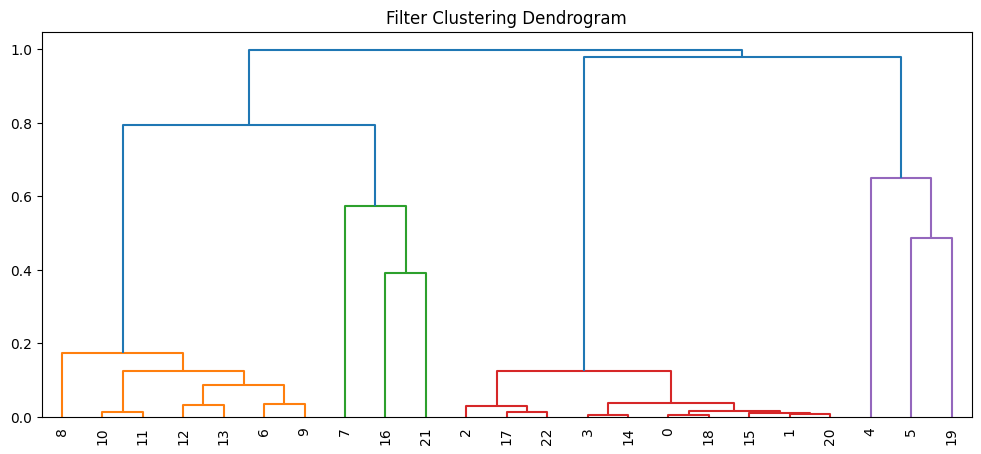

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 10.25%
F1-score: 10.25%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.91%
F1-score: 8.91%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 1.91%
F1-score: 1.91%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.70%
F1-score: 1.70%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.96%
F1-score: 2.96%
=========== Clustering Filters ==============


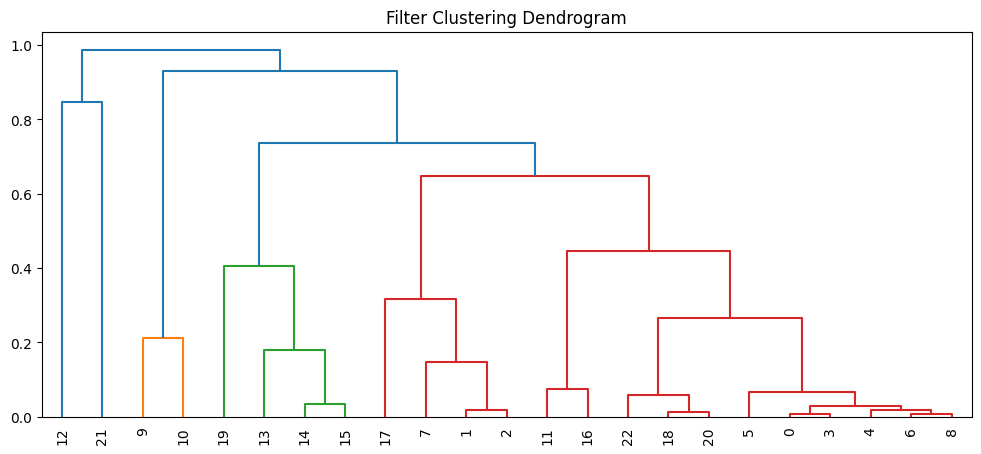

=========== Analysing Fold 2 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 45.20%
F1-score: 45.20%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 55.34%
F1-score: 55.34%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 71.52%
F1-score: 71.52%
Analyzing filter: 19
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 7.60%
F1-score: 7.60%
Analyzing filter: 20
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 14.45%
F1-score: 14.45%
=========== Clustering Filters ==============


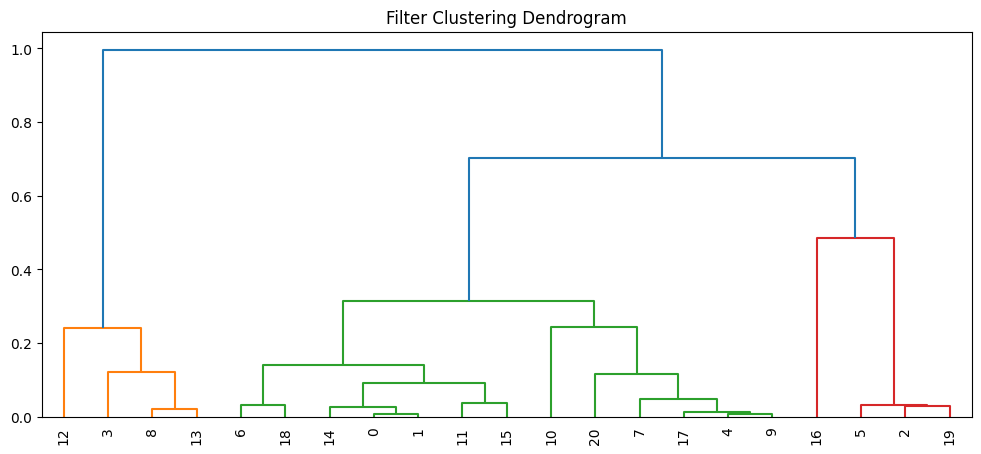

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 7.14%
F1-score: 7.14%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.27%
F1-score: 0.27%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.29%
F1-score: 0.29%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.18%
F1-score: 0.18%
=========== Clustering Filters ==============


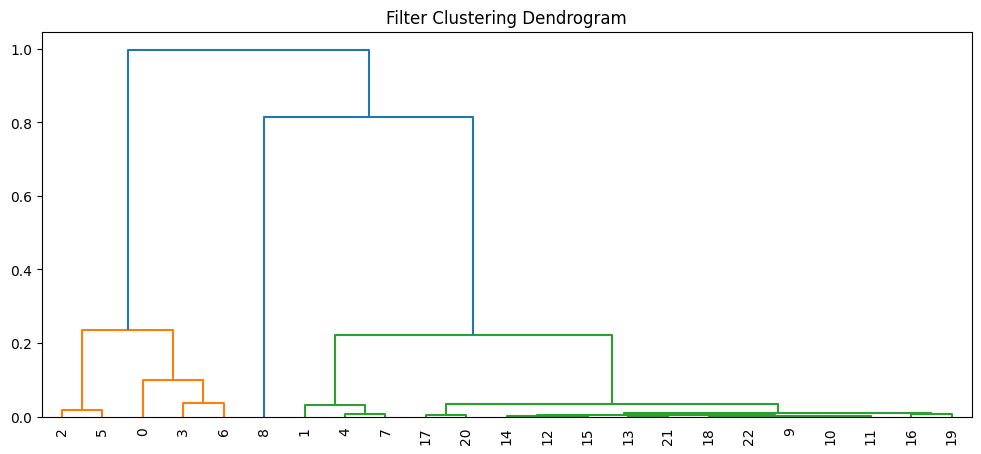

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 31.89%
F1-score: 31.89%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 32.35%
F1-score: 32.35%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 29.19%
F1-score: 29.19%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 29.82%
F1-score: 29.82%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 37.57%
F1-score: 37.57%
=========== Clustering Filters ==============


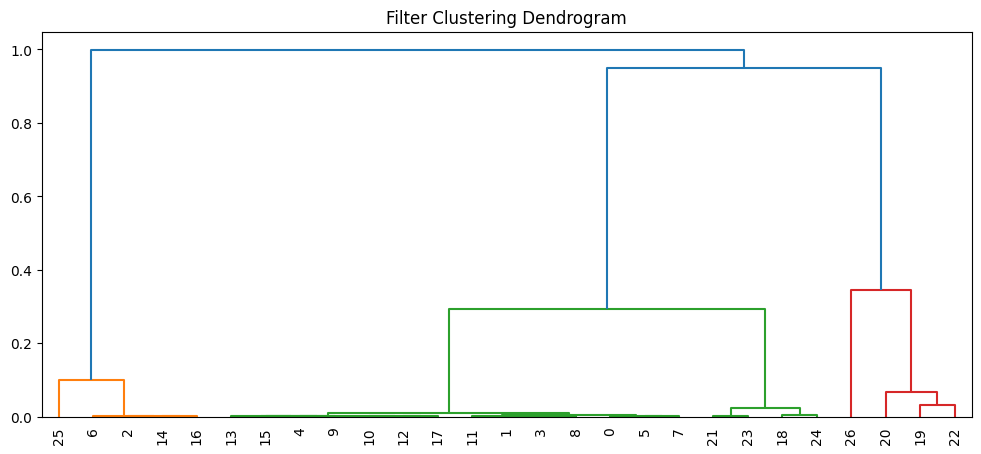

   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   

                                      filter_weights              scaler  \
0                                                 []                  []   
1                                                 []                  []   
2  [[0.38183725, -0.44608337, -0.5699345, -0.1111...  [StandardScaler()]   
3                                                 []                  []   
4                                                 []                  []   

                                              backup  
0  [0.34168336673297567, [0.019518021, -0.0008676...  
1  [0.1411558048087303, [-0.08586581, -0.11001619...  
2  [0.7472965281725314, [0.38183725, -0.44608337,...  
3  [0.07137939780410121, [0.098782726, -0.0555588...  
4  [0.40898407371082823, [0.04120071, -0.09232208...  
Nu

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============


ValueError: Found input variables with inconsistent numbers of samples: [1191356, 1]

In [ ]:

DIST_THRESHOLD = 0.2
FILTER_SEL_THRESHOLD = 0.4

entire_pipeline_results = []
best_thr_LOPOCV = []
max_f1_LOPOCV = []
selected_backups_across_LOPOCV_folds = []
LOPO_df = pd.DataFrame()
for LOPOCV_fold_idx in range(folds_to_test):

    model_cvfolds_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/'

    cross_val_models_list = load_training_models(model_cvfolds_dir)
    train_kfolds, test_pat = LOPOCV_patients_folds[LOPOCV_fold_idx] # for each LOPO fold

    # ======= Phase 1: Find Best Filters ======= #

    filter_metadata_df = filters_selection_phase(cross_val_models_list, train_kfolds, multiple_donations, ALL_DATASETS, LOPOCV_fold_idx, DIST_THRESHOLD, FILTER_SEL_THRESHOLD)

    LOPO_df = pd.concat([LOPO_df, filter_metadata_df], ignore_index=True)
    print(LOPO_df)

    # ======= Phase 2: Find Best Thr ======= #
    best_avg_thr, max_f1 = best_cells_threshold_phase(
                            filter_metadata_df, train_kfolds,
                            multiple_donations, ALL_DATASETS)

    best_thr_LOPOCV.append(best_avg_thr)
    max_f1_LOPOCV.append(max_f1)

    # ======= Phase 3: Test ======= #
    LOPOCV_results = test_phase(filter_metadata_df, test_pat, multiple_donations, ALL_DATASETS, max_f1, best_avg_thr, LOPOCV_fold_idx)
    entire_pipeline_results.append(LOPOCV_results)


summary_df = pd.DataFrame(flatten(entire_pipeline_results))


In [ ]:
summary_df


,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,True_%,Predicted_Blasts,TP_%,Predicted_%,Recall,Precision,F1_Score,Accuracy,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1
0,Pat_1_1,1,864000,757,0.0876,10381,7.061,1.2015,0.9683,0.0706,0.1316,0.9888,733,24,9648,853595,0.747297
1,Pat_1_2,1,1947518,0,0.0000,109,0.000,0.0056,0.0000,0.0000,0.0000,0.9999,0,0,109,1947409,0.747297


In [ ]:
summary_df

,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,True_%,Predicted_Blasts,TP_%,Predicted_%,Recall,Precision,F1_Score,Accuracy,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1
0,Pat_1_1,1,864000,757,0.087600,10381,7.0610,1.2015,0.9683,0.0706,0.1316,0.9888,733,24,9648,853595,0.747297
1,Pat_1_2,1,1947518,0,0.000000,109,0.0000,0.0056,0.0000,0.0000,0.0000,0.9999,0,0,109,1947409,0.747297
2,Pat_2_1,2,778750,308059,39.558102,97720,0.0215,12.5483,0.0001,0.0002,0.0001,0.4790,21,308038,97699,372992,0.314266
3,Pat_2_2,2,5510750,830101,15.063300,822798,2.7022,14.9308,0.0268,0.0270,0.0269,0.7081,22234,807867,800564,3880085,0.314266
4,Pat_3_1,3,208000,72,0.034600,105546,0.0682,50.7433,1.0000,0.0007,0.0014,0.4929,72,0,105474,102454,0.362014
5,Pat_3_2,3,2912500,0,0.000000,675797,0.0000,23.2033,0.0000,0.0000,0.0000,0.7680,0,0,675797,2236703,0.362014
6,Pat_4_1,4,160500,3096,1.929000,43593,7.1021,27.1607,1.0000,0.0710,0.1326,0.7477,3096,0,40497,116907,0.604967
7,Pat_4_2,4,3591480,1449,0.040300,260399,0.5565,7.2505,1.0000,0.0056,0.0111,0.9279,1449,0,258950,3331081,0.604967
8,Pat_4_3,4,3107000,0,0.000000,8873,0.0000,0.2856,0.0000,0.0000,0.0000,0.9971,0,0,8873,3098127,0.604967
9,Pat_5_1,5,637409,9147,1.435000,1741,45.7783,0.2731,0.0871,0.4578,0.1464,0.9854,797,8350,944,627318,0.635592


In [ ]:

summary_df['Blast_Perc'] = round(100*summary_df['Real_Blasts']/summary_df['Total_Cells'], 4)
summary_df['Num'] = [1]*len(summary_df)

# Mostra le prime righe del risultato
print("=== RIASSUNTO METRICHE PER SAMPLE ===")
print(summary_df.to_string())

=== RIASSUNTO METRICHE PER SAMPLE ===
   Sample_ID  LOPO_Fold  Total_Cells  Real_Blasts     True_%  Predicted_Blasts     TP_%  Predicted_%  Recall  Precision  F1_Score  Accuracy  TP (Detected_Blasts)  FN (Not_Detected_Blasts)  FP (False_Positives)  TN (Detected_Healthy)  Filter_F1  Blast_Perc  Num  True Label
0    Pat_1_1          1       864000          757   0.087600             10381   7.0610       1.2015  0.9683     0.0706    0.1316    0.9888                   733                        24                  9648                 853595   0.747297      0.0876    1           1
1    Pat_1_2          1      1947518            0   0.000000               109   0.0000       0.0056  0.0000     0.0000    0.0000    0.9999                     0                         0                   109                1947409   0.747297      0.0000    1           0
2    Pat_2_1          2       778750       308059  39.558102             97720   0.0215      12.5483  0.0001     0.0002    0.0001    0.4790    

In [ ]:
Sample_ID  LOPO_Fold  Total_Cells  Real_Blasts
Pat_1_1          1       864000          757
Pat_1_2          1      1947518            0
Pat_2_1          2       778750       308059
Pat_2_2          2      5510750       830101
Pat_3_1          3       208000           72
Pat_3_2          3      2912500            0
Pat_4_1          4       160500         3096
Pat_4_2          4      3591480         1449
Pat_4_3          4      3107000            0
Pat_5_1          5       637409         9147
Pat_5_2          5      2928000          227
Pat_6_1          6       164553          518
Pat_6_2          6       191975          398
Pat_6_3          6       169000            0
Pat_7_1          7       479000         2390
Pat_7_2          7       455000           77
Pat_8_1          8       160828        44697
Pat_8_2          8       505000         1413
Pat_9_1          9       843500         1348
Pat_9_2          9      1404000          170
Pat_9_3          9      3265250            0
Pat_10_1         10       430869          639
Pat_10_2         10       722000           15

In [ ]:
summary_df.to_csv(f'{config_save_dir}summary_df.csv')

In [ ]:
config_save_dir

'/content/drive/MyDrive/0.Master_Thesis/CellCNN//experiments/experiment_filter_resp_plots/'

In [ ]:
s = pd.read_csv(f'{config_save_dir}/summary_df.csv')
print(s)

    Unnamed: 0 Sample_ID  LOPO_Fold  Total_Cells  Real_Blasts   True_%  \
0            0   Pat_1_1          1       864000          757   0.0876   
1            1   Pat_1_2          1      1947518            0   0.0000   
2            2   Pat_2_1          2       778750       308059  39.5581   
3            3   Pat_2_2          2      5510750       830101  15.0633   
4            4   Pat_3_1          3       208000           72   0.0346   
5            5   Pat_3_2          3      2912500            0   0.0000   
6            6   Pat_4_1          4       160500         3096   1.9290   
7            7   Pat_4_2          4      3591480         1449   0.0403   
8            8   Pat_4_3          4      3107000            0   0.0000   
9            9   Pat_5_1          5       637409         9147   1.4350   
10          10   Pat_5_2          5      2928000          227   0.0078   
11          11   Pat_6_1          6       164553          518   0.3148   
12          12   Pat_6_2          6   

In [ ]:
config_save_dir

'/content/drive/MyDrive/0.Master_Thesis/CellCNN//experiments/experiment_filter_resp_plots/'

In [ ]:
summary_df = s

In [ ]:


condition = summary_df['True Label'] == 1

mean_filter_F1_Score = summary_df[condition]['Filter_F1'].to_numpy()
true_pos_perc = summary_df[condition]['TP_%'].to_numpy()
samples_ID = summary_df[condition]['Sample_ID'].to_numpy()
pred_perc = summary_df[condition]['Predicted_%'].to_numpy()
true_perc = summary_df[condition]['True_%'].to_numpy()
pos_perc_dist = 1-abs(pred_perc - true_pos_perc)
true_perc_dist = 1-abs(pred_perc - true_perc)

to_analyse = [true_pos_perc, pos_perc_dist, true_perc_dist]
y_labels = ['TP_%',
            'Distance between Predicted % and True Positive %',
            'Distance between Predicted % and True Cancer Cells %']
fig, ax = plt.subplots(1,len(to_analyse), figsize = (20,7))

for e, element in enumerate(to_analyse):
  ax[e].scatter(mean_filter_F1_Score, element)

  for i, txt in enumerate(samples_ID):
    ax[e].annotate(txt, (mean_filter_F1_Score[i], element[i]))

  ax[e].set_ylabel(y_labels[e])
  ax[e].set_xlabel('F1')

display(fig)
plt.close(fig)

NameError: name 'summary_df' is not defined

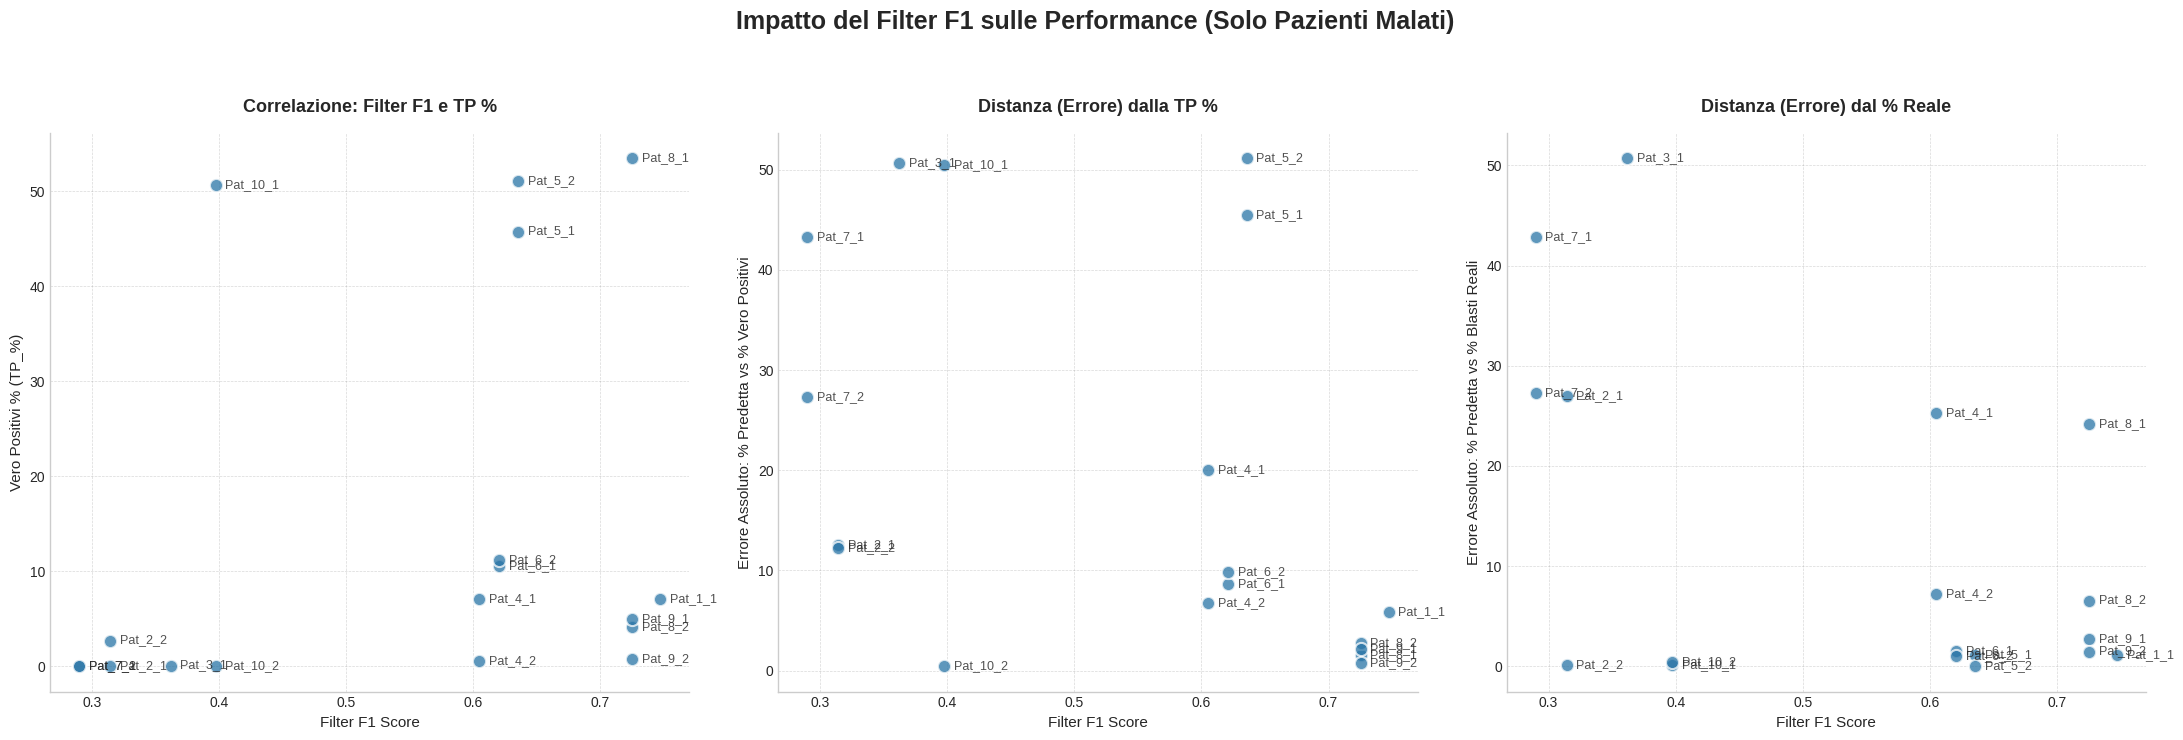

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparazione dei dati (con correzione matematica)
condition = summary_df['True Label'] == 1

mean_filter_F1_Score = summary_df[condition]['Filter_F1'].to_numpy()
true_pos_perc = summary_df[condition]['TP_%'].to_numpy()
samples_ID = summary_df[condition]['Sample_ID'].to_numpy()
pred_perc = summary_df[condition]['Predicted_%'].to_numpy()
true_perc = summary_df[condition]['True_%'].to_numpy()

# CORREZIONE: Usiamo la distanza assoluta per avere 0 = Errore Nullo
pos_perc_dist = abs(pred_perc - true_pos_perc)
true_perc_dist = abs(pred_perc - true_perc)

to_analyse = [true_pos_perc, pos_perc_dist, true_perc_dist]

# 2. Configurazione delle stringhe di testo
y_labels = ['Vero Positivi % (TP_%)',
            'Errore Assoluto: % Predetta vs % Vero Positivi',
            'Errore Assoluto: % Predetta vs % Blasti Reali']

titles = ['Correlazione: Filter F1 e TP %',
          'Distanza (Errore) dalla TP %',
          'Distanza (Errore) dal % Reale']

# 3. Creazione della figura
# Impostiamo uno stile pulito di default (opzionale ma consigliato)
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, len(to_analyse), figsize=(22, 7))
fig.suptitle("Impatto del Filter F1 sulle Performance (Solo Pazienti Malati)",
             fontsize=18, fontweight='bold', y=1.05)

# Colore principale per i punti (puoi usare hex code o nomi, es: 'darkblue')
point_color = '#2874A6'

for e, element in enumerate(to_analyse):
    # --- SCATTER PLOT ---
    # Aumentiamo la dimensione (s), aggiungiamo un bordo bianco e trasparenza (alpha)
    ax[e].scatter(mean_filter_F1_Score, element,
                  s=90, c=point_color, alpha=0.75,
                  edgecolors='white', linewidth=1.5, zorder=3)

    # --- ANNOTAZIONI ---
    for i, txt in enumerate(samples_ID):
        ax[e].annotate(txt,
                       (mean_filter_F1_Score[i], element[i]),
                       fontsize=9,
                       xytext=(7, 0), # Sposta il testo di 7 pixel a destra
                       textcoords='offset points',
                       ha='left', va='center',
                       alpha=0.8,
                       zorder=4)

    # --- FORMATTAZIONE ASSI E TITOLI ---
    ax[e].set_title(titles[e], fontsize=13, fontweight='bold', pad=15)
    ax[e].set_ylabel(y_labels[e], fontsize=11, fontweight='500')
    ax[e].set_xlabel('Filter F1 Score', fontsize=11, fontweight='500')

    # Rimuoviamo i bordi neri in alto e a destra per un look più moderno (decluttering)
    ax[e].spines['top'].set_visible(False)
    ax[e].spines['right'].set_visible(False)

    # Griglia leggera in sottofondo
    ax[e].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3, zorder=0)

# Ottimizza gli spazi tra i subplot
plt.tight_layout()
plt.show() # o display(fig) a seconda dell'ambiente
display(fig)
plt.close(fig)

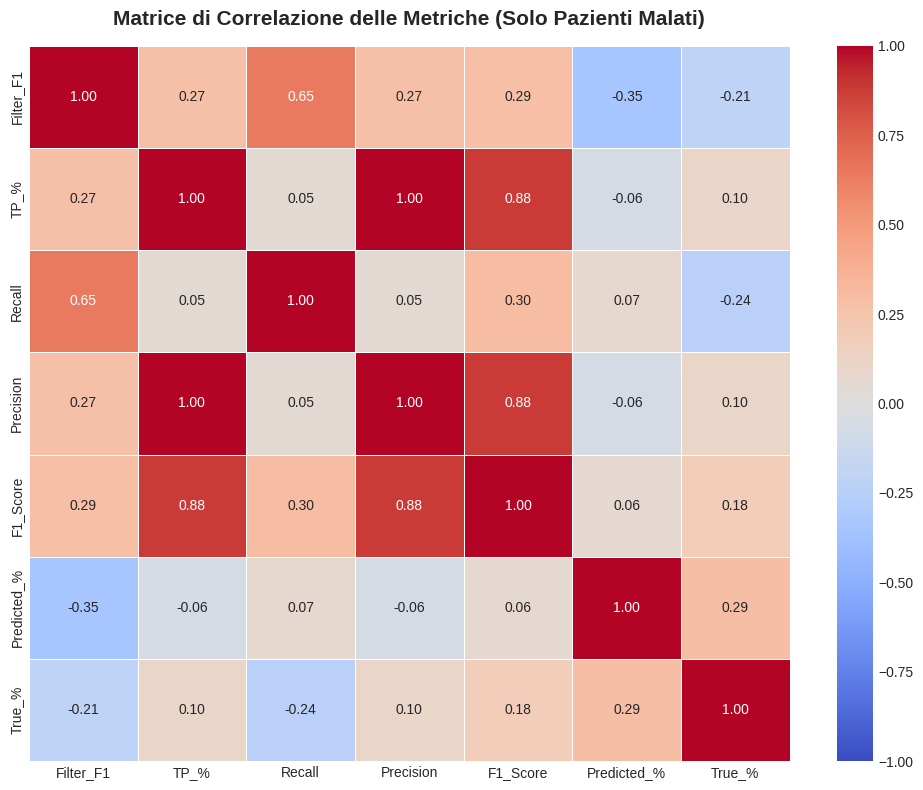

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selezioniamo solo i pazienti malati (come hai fatto tu)
condition = summary_df['True Label'] == 1
df_malati = summary_df[condition]

# 2. Scegliamo le colonne numeriche di cui vogliamo capire la correlazione
# Ho inserito le metriche principali del tuo dataframe
cols_to_correlate = ['Filter_F1', 'TP_%', 'Recall', 'Precision', 'F1_Score', 'Predicted_%', 'True_%']
dati_correlazione = df_malati[cols_to_correlate]

# 3. Calcoliamo la matrice di correlazione (metodo Pearson)
# Nota: puoi usare method='spearman' se pensi che la relazione non sia strettamente lineare
corr_matrix = dati_correlazione.corr(method='pearson')

# 4. Creiamo il grafico (Heatmap)
fig = plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,       # Mostra i numeri dentro i quadrati
            cmap='coolwarm',  # Colori: rosso (positivo), blu (negativo)
            fmt=".2f",        # Arrotonda a 2 decimali
            vmin=-1, vmax=1,  # Fissa la scala da -1 a 1
            linewidths=0.5)

plt.title("Matrice di Correlazione delle Metriche (Solo Pazienti Malati)", fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
display(fig)
plt.close(fig)

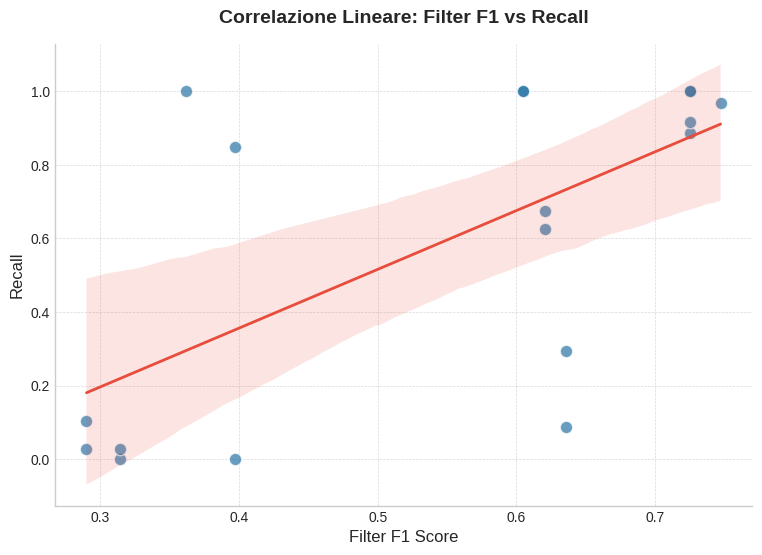

In [ ]:
import seaborn as sns

fig = plt.figure(figsize=(9, 6))

# Creiamo lo scatter plot con la linea di tendenza
sns.regplot(data=df_malati,
            x='Filter_F1',
            y='Recall',           # Cambia 'Recall' con qualsiasi altra metrica tu voglia analizzare
            scatter_kws={'s': 80, 'alpha': 0.7, 'edgecolor': 'white', 'color': '#2874A6'},
            line_kws={'color': '#E74C3C', 'linewidth': 2}) # Linea di tendenza in rosso

plt.title('Correlazione Lineare: Filter F1 vs Recall', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Filter F1 Score', fontsize=12)
plt.ylabel('Recall', fontsize=12)

# Abbellimenti
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
sns.despine() # Rimuove i bordi superiore e destro

display(fig)
plt.close(fig)

In [ ]:
from scipy.stats import pearsonr

# Estraiamo i vettori puliti
x = df_malati['Filter_F1']
y = df_malati['Recall'] # O la metrica che preferisci

# Calcoliamo correlazione e p-value
corr, p_value = pearsonr(x, y)

print(f"Coefficiente di Correlazione (r): {corr:.3f}")
print(f"P-value: {p_value:.4f}")

Coefficiente di Correlazione (r): 0.648
P-value: 0.0036


# Logistic Regression

=========== Analysing Fold 0 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.54%
F1-score: 2.54%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.58%
F1-score: 2.58%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 2.57%
F1-score: 2.57%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.10%
F1-score: 0.10%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.57%
F1-score: 2.57%
=========== Clustering Filters ==============


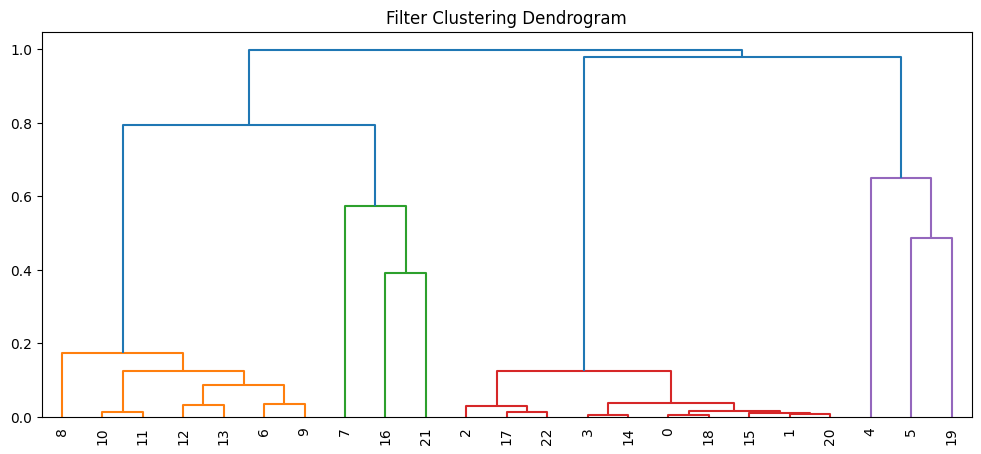

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 10.25%
F1-score: 10.25%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.91%
F1-score: 8.91%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 1.91%
F1-score: 1.91%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.70%
F1-score: 1.70%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.96%
F1-score: 2.96%
=========== Clustering Filters ==============


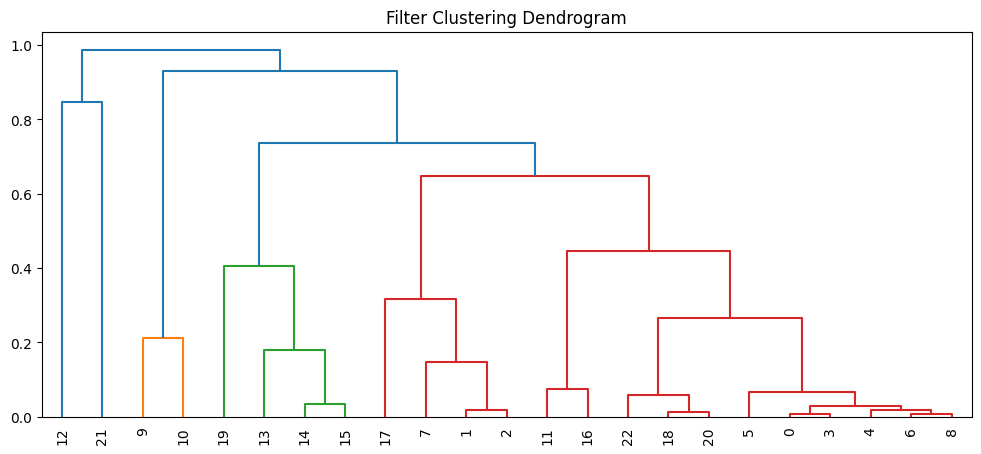

=========== Analysing Fold 2 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 45.20%
F1-score: 45.20%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 55.34%
F1-score: 55.34%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 71.52%
F1-score: 71.52%
Analyzing filter: 19
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 7.60%
F1-score: 7.60%
Analyzing filter: 20
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 14.45%
F1-score: 14.45%
=========== Clustering Filters ==============


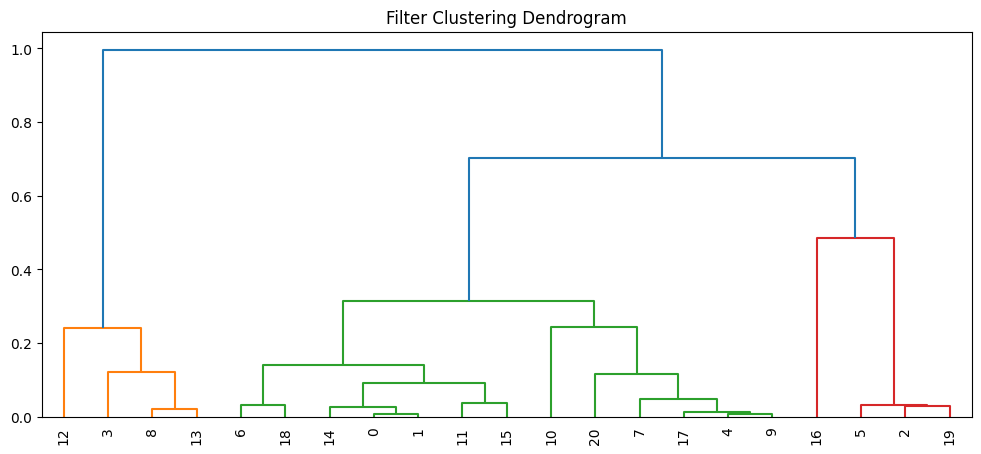

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 7.14%
F1-score: 7.14%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.27%
F1-score: 0.27%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.29%
F1-score: 0.29%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.18%
F1-score: 0.18%
=========== Clustering Filters ==============


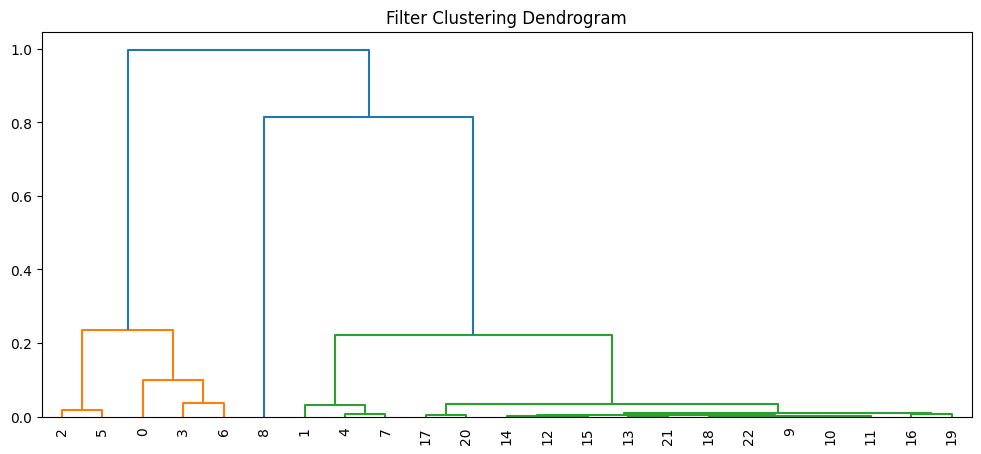

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 31.89%
F1-score: 31.89%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 32.35%
F1-score: 32.35%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 29.19%
F1-score: 29.19%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 29.82%
F1-score: 29.82%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 37.57%
F1-score: 37.57%
=========== Clustering Filters ==============


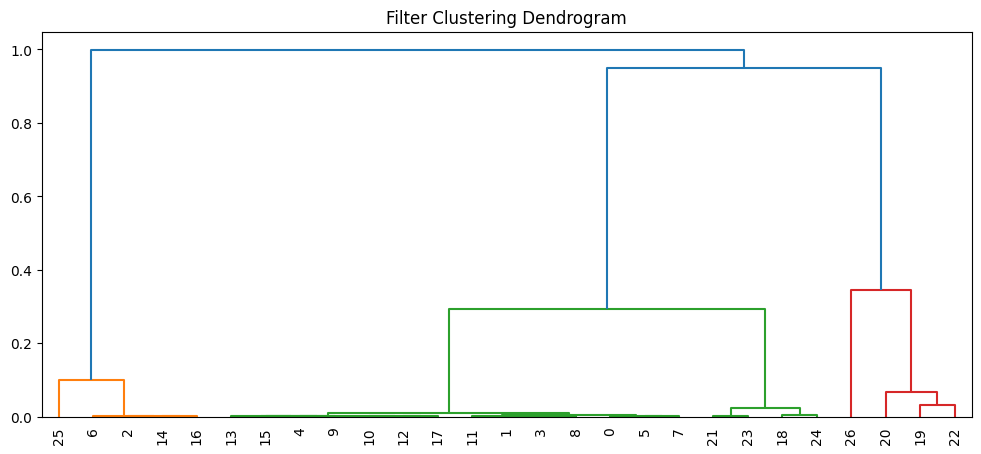

   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   

                                      filter_weights  \
0                                                 []   
1                                                 []   
2  [[0.38183725, -0.44608337, -0.5699345, -0.1111...   
3                                                 []   
4  [[0.04120071, -0.09232208, -0.0075462423, 0.15...   

                                 scaler  \
0                                    []   
1                                    []   
2  [StandardScaler(), StandardScaler()]   
3                                    []   
4                    [StandardScaler()]   

                                              backup  
0  [0.34168336673297567, [0.019518021, -0.0008676...  
1  [0.1411558048087303, [-0.08586581, -0.11001619...  
2  [0.7472965281725314, [0.3

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 37.69%


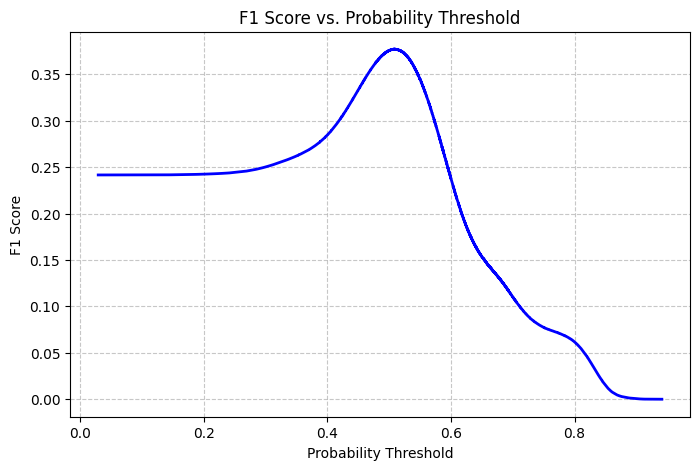

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
27434008


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
21182995
Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 24.45%


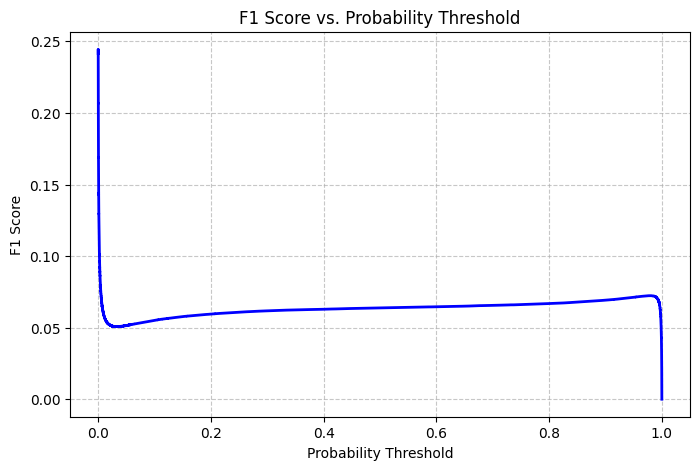

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
filter_metadata_df

,lopo_fold,cv_fold,model_ID,filter_weights,scaler,backup
0,0,0,0,[],[],"[0.34168336673297567, [0.019518021, -0.0008676..."
1,0,1,0,[],[],"[0.1411558048087303, [-0.08586581, -0.11001619..."
2,0,2,0,"[[0.38183725, -0.44608337, -0.5699345, -0.1111...","[StandardScaler(), StandardScaler()]","[0.7472965281725314, [0.38183725, -0.44608337,..."
3,0,3,0,[],[],"[0.07137939780410121, [0.098782726, -0.0555588..."
4,0,4,0,"[[0.04120071, -0.09232208, -0.0075462423, 0.15...",[StandardScaler()],"[0.40898407371082823, [0.04120071, -0.09232208..."


In [ ]:
summary_df

,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,True_%,Predicted_Blasts,TP_%,Predicted_%,Recall,Precision,F1_Score,Accuracy,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1
0,Pat_1_1,1,864000,757,0.0876,700750,0.108,81.1053,1.0,0.0011,0.0022,0.1898,757,0,699993,163250,0.376932
1,Pat_1_2,1,1947518,0,0.0000,454455,0.000,23.3351,0.0,0.0000,0.0000,0.7666,0,0,454455,1493063,0.376932


In [ ]:
logistic_summary_df

,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,True_%,Predicted_Blasts,TP_%,Predicted_%,Recall,Precision,F1_Score,Accuracy,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1
0,Pat_1_1,1,864000,757,0.0876,863999,0.0876,99.9999,1.0,0.0009,0.0018,0.0009,757,0,863242,1,0.244525
1,Pat_1_2,1,1947518,0,0.0000,1947510,0.0000,99.9996,0.0,0.0000,0.0000,0.0000,0,0,1947510,8,0.244525


In [ ]:

filters_plot_exp = 'filter_resp_plots'
config_save_dir = f'{cellcnn_path}/experiments/experiment_{filters_plot_exp}/'
os.makedirs(config_save_dir, exist_ok = True)

plotdir = os.path.join(config_save_dir, 'plots')
os.makedirs(plotdir, exist_ok = True)

exp = 'Trial_4_NO_AS_Ensemble'
folds_to_test = 1

=========== Analysing Fold 0 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.54%
F1-score: 2.54%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.58%
F1-score: 2.58%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 2.57%
F1-score: 2.57%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.10%
F1-score: 0.10%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.57%
F1-score: 2.57%
=========== Clustering Filters ==============


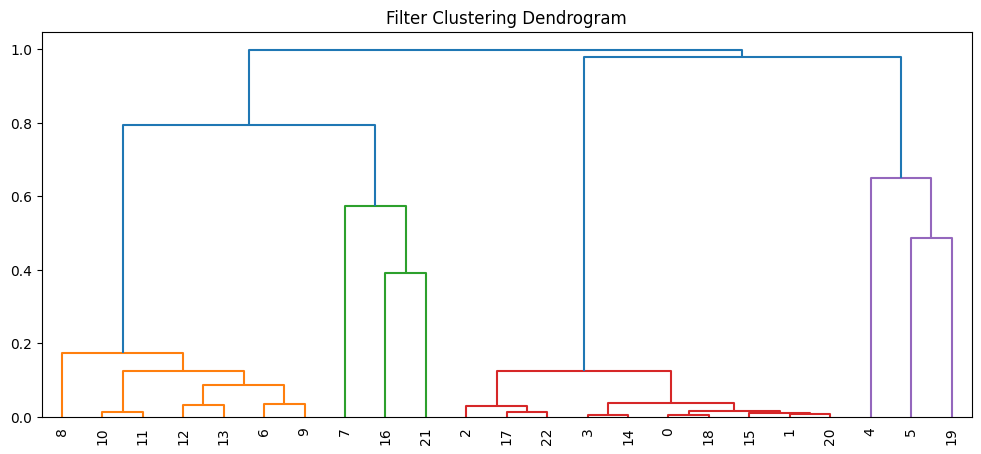

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 10.25%
F1-score: 10.25%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.91%
F1-score: 8.91%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 1.91%
F1-score: 1.91%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.70%
F1-score: 1.70%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.96%
F1-score: 2.96%
=========== Clustering Filters ==============


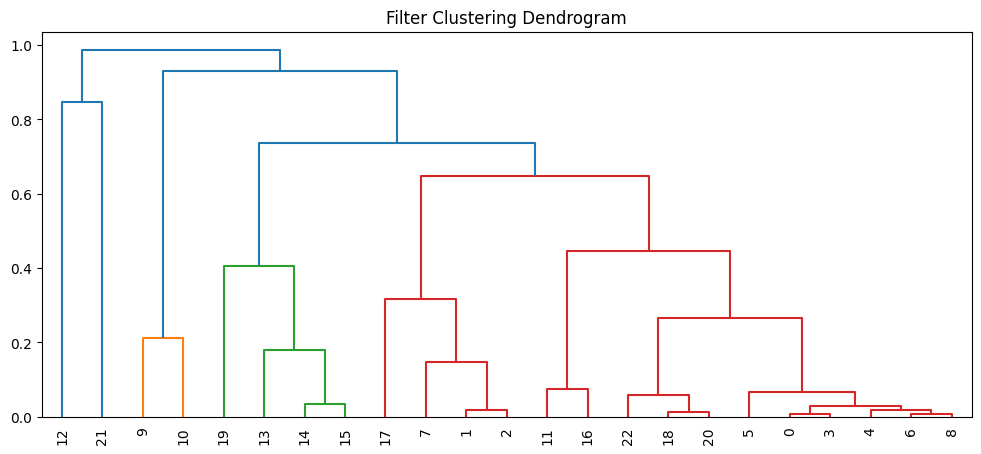

=========== Analysing Fold 2 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 45.20%
F1-score: 45.20%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 55.34%
F1-score: 55.34%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 71.52%
F1-score: 71.52%
Analyzing filter: 19
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 7.60%
F1-score: 7.60%
Analyzing filter: 20
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 14.45%
F1-score: 14.45%
=========== Clustering Filters ==============


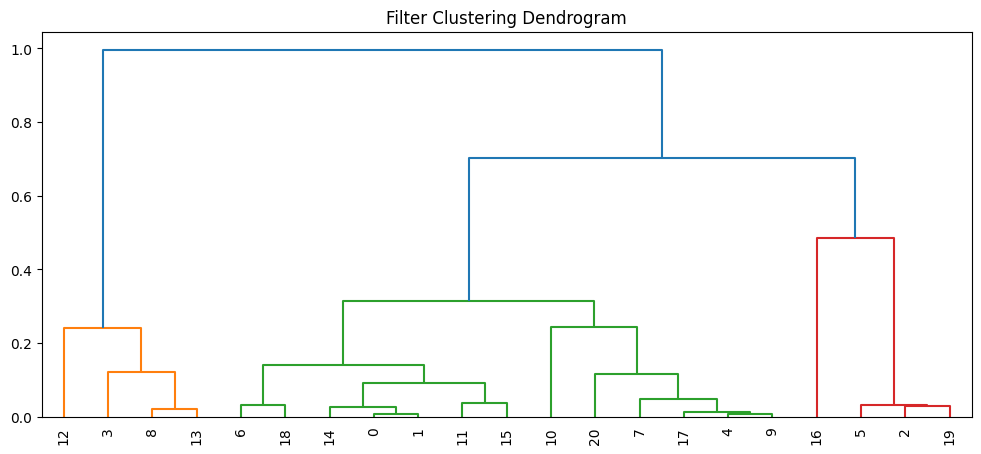

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 7.14%
F1-score: 7.14%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.27%
F1-score: 0.27%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.29%
F1-score: 0.29%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.18%
F1-score: 0.18%
=========== Clustering Filters ==============


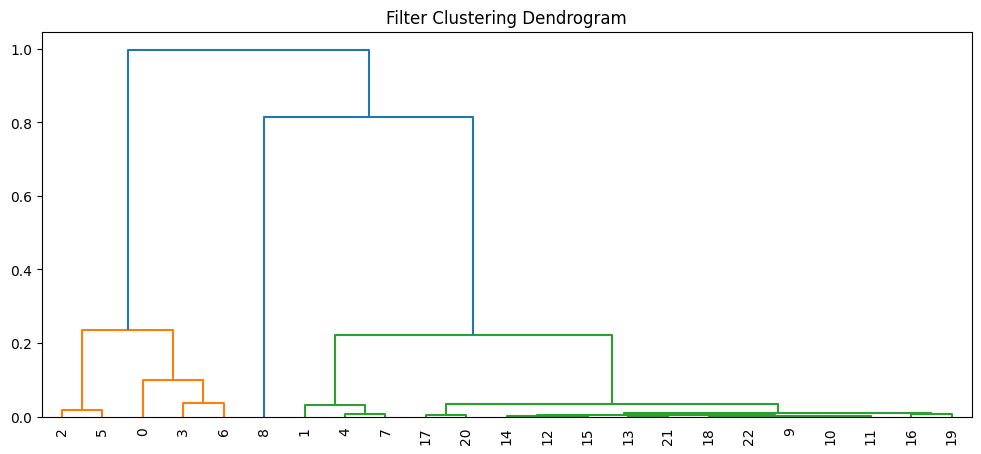

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 31.89%
F1-score: 31.89%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 32.35%
F1-score: 32.35%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 29.19%
F1-score: 29.19%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 29.82%
F1-score: 29.82%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 37.57%
F1-score: 37.57%
=========== Clustering Filters ==============


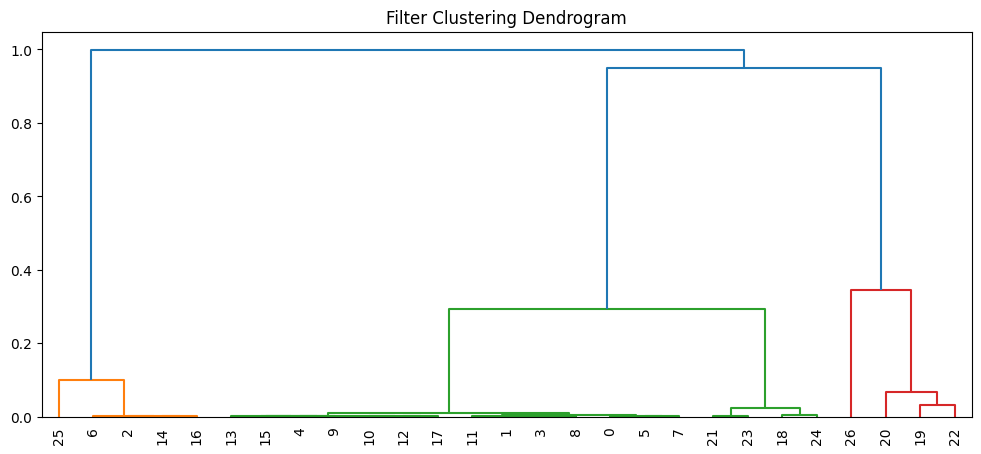

TypeError: best_cells_threshold_phase() got an unexpected keyword argument 'method'

In [ ]:
folds_to_test = 1
DIST_THRESHOLD = 0.2
FILTER_SEL_THRESHOLD = 0.6

entire_logistic_pipeline_results = []
best_logistic_thr_LOPOCV = []
max_logistic_f1_LOPOCV = []
for LOPOCV_fold_idx in range(folds_to_test):

    model_cvfolds_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/'

    cross_val_models_list = load_training_models(model_cvfolds_dir)
    train_kfolds, test_pat = LOPOCV_patients_folds[LOPOCV_fold_idx] # for each LOPO fold

    # ======= Phase 1: Find Best Filters ======= #

    filter_metadata_df = filters_selection_phase(cross_val_models_list, train_kfolds, multiple_donations, ALL_DATASETS, LOPOCV_fold_idx, DIST_THRESHOLD, FILTER_SEL_THRESHOLD)

    # ======= Phase 2: Find Best Thr ======= #
    best_logistic_thr, max_logistic_f1, clf_list = best_cells_threshold_phase(filter_metadata_df, train_kfolds, multiple_donations, ALL_DATASETS, method='logistic')


    best_logistic_thr_LOPOCV.append(best_logistic_thr)
    max_logistic_f1_LOPOCV.append(max_logistic_f1)

    # ======= Phase 3: Test ======= #
    LOPOCV_logistic_results = test_phase(filter_metadata_df, test_pat, multiple_donations, ALL_DATASETS,
               max_logistic_f1, best_logistic_thr, LOPOCV_fold_idx, clf_list = clf_list)

    entire_logistic_pipeline_results.append(LOPOCV_logistic_results)

logistic_summary_df = pd.DataFrame(flatten(entire_logistic_pipeline_results))

# Averaging across trained filters used in the final sample evaluation

In [ ]:
filters_plot_exp = 'filter_resp_plots'
config_save_dir = f'{cellcnn_path}/experiments/experiment_{filters_plot_exp}/'
os.makedirs(config_save_dir, exist_ok = True)

plotdir = os.path.join(config_save_dir, 'plots')
os.makedirs(plotdir, exist_ok = True)

In [ ]:
def retrieve_flags(x, fold_loaded_models_lists):

    all_probs_list =  []
    for m, model in enumerate(fold_loaded_models_lists): # several seeds (our case 1 seed only)

        for net in model.results['best_3_nets']:

            all_probs = get_full_network_prob(net, x,  model.results['scaler'])
            all_probs_list.append(all_probs)

    all_probs_mean = np.mean(all_probs_list, axis = 0).ravel()

    return all_probs_mean

def best_3_filt_threshold_phase(cross_val_models_list, train_kfolds,  multiple_donations, ALL_DATASETS, show_plot = True):
    all_preds = []
    all_labels = []

    for cv, fold_loaded_models_lists in enumerate(cross_val_models_list): # cross validation fold
        print(f'=========== Analysing Fold {cv} ==============')

        _, val_pat = train_kfolds[cv]
        val_datasets_extracted = donation_extraction(val_pat, multiple_donations, ALL_DATASETS)
        val_datasets_extracted_flat, val_y = retrieve_labels(val_datasets_extracted, remove = False, flat = True)
        del val_datasets_extracted
        gc.collect()

        for s, x_df in enumerate(val_datasets_extracted_flat):
            y_true = x_df['IsBlast'].to_numpy()
            x_features = x_df.drop(columns=['IsBlast'])


            preds = retrieve_flags(x_features, fold_loaded_models_lists) # adding x_name we save the dataset

            all_preds.append(preds)
            all_labels.append(y_true)

    del val_datasets_extracted_flat
    gc.collect()

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    print('=========== Finding Best Threshold ==============')

    best_thr, max_f1 = get_best_thr(all_labels, all_preds, show = show_plot)

    return best_thr, max_f1

def test_3_filt_phase(test_pat, multiple_donations, ALL_DATASETS, cross_val_models_list, max_3_filt_f1, best_3_filt_thr, LOPOCV_fold_idx):
    test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)
    test_datasets_extracted_flat, test_y = retrieve_labels(test_datasets_extracted, remove = False, flat = True)

    LOPOCV_3_filt_results = []
    for idx_x, x_df in enumerate(test_datasets_extracted_flat):
        y_true = x_df['IsBlast'].to_numpy()
        x_features = x_df.drop(columns=['IsBlast'])

        sample_preds_across_folds = []
        for cv, fold_loaded_models_lists in enumerate(cross_val_models_list):

            print(f'=========== Analysing Sample {idx_x} ==============')
            preds = retrieve_flags(x_features, fold_loaded_models_lists)
            sample_preds_across_folds.append(preds)

        final_preds = np.mean(sample_preds_across_folds, axis=0)

        y_pred = (final_preds >= best_3_filt_thr).astype(int)

        results_dict = get_metrics_df(y_true, y_pred, max_3_filt_f1, LOPOCV_fold_idx, idx_x)
        LOPOCV_3_filt_results.append(results_dict)

    return LOPOCV_3_filt_results


=========== find threshold phase ==============
=========== Analysing Fold 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


number of cells in comprehensive_df: 843500
number of cells in comprehensive_df: 843500
number of cells in comprehensive_df: 1
number of cells in comprehensive_df: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


number of cells in comprehensive_df: 1404000
number of cells in comprehensive_df: 1404000
number of cells in comprehensive_df: 2
number of cells in comprehensive_df: 2


...

number of cells in comprehensive_df: 722000
number of cells in comprehensive_df: 722000
number of cells in comprehensive_df: 19
number of cells in comprehensive_df: 19


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


number of cells in comprehensive_df: 778750
number of cells in comprehensive_df: 778750
number of cells in comprehensive_df: 20
number of cells in comprehensive_df: 20


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


number of cells in comprehensive_df: 5510750
number of cells in comprehensive_df: 5510750
number of cells in comprehensive_df: 21
number of cells in comprehensive_df: 21
number of cells in comprehensive_df: 28625364
number of cells in comprehensive_df: 28625364
=========== Finding Best Threshold ==============
=========== Finding Best Threshold ==============
F1-score: 8.62%


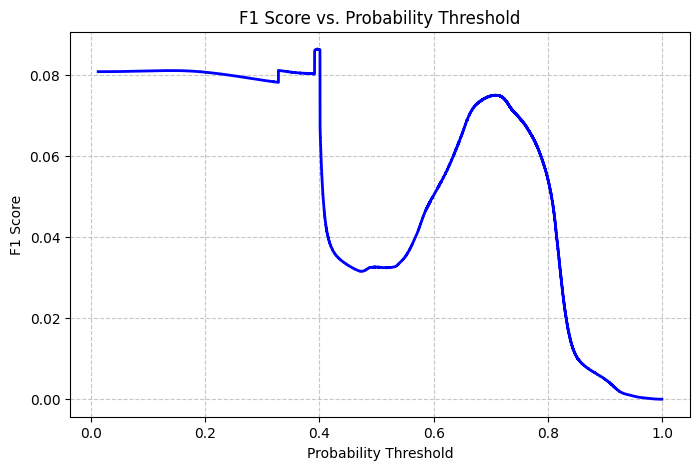

=========== Evaluating the Test set ==============
=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


...

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 1 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 1 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
exp = 'Trial_4_NO_AS_Ensemble'


entire_pipeline_3_filt_results = []
max_f1_3_filt_LOPOCV = []
for LOPOCV_fold_idx in range(1):
    model_cvfolds_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/'


    cross_val_models_list = load_training_models(model_cvfolds_dir)

    train_kfolds, test_pat = LOPOCV_patients_folds[LOPOCV_fold_idx] # for each LOPO fold
    print('=========== find threshold phase ==============')


    best_3_filt_thr, max_3_filt_f1 = best_3_filt_threshold_phase(cross_val_models_list, train_kfolds,  multiple_donations, ALL_DATASETS)

    max_f1_3_filt_LOPOCV.append(max_3_filt_f1)


    print('=========== Evaluating the Test set ==============')


    LOPOCV_3_filt_results = test_3_filt_phase(test_pat, multiple_donations, ALL_DATASETS, cross_val_models_list, max_3_filt_f1, best_3_filt_thr, LOPOCV_fold_idx)

    entire_pipeline_3_filt_results.append(LOPOCV_3_filt_results)

best_3_filt_summary_df = pd.DataFrame(flatten(entire_pipeline_3_filt_results))

In [ ]:
best_3_filt_summary_df

,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,True_%,Predicted_Blasts,TP_%,Predicted_%,Recall,Precision,F1_Score,Accuracy,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1
0,Pat_1_1,1,864000,757,0.0876,862044,0.0878,99.7736,1.0,0.0009,0.0018,0.0031,757,0,861287,1956,0.086244
1,Pat_1_2,1,1947518,0,0.0000,1667723,0.0000,85.6333,0.0,0.0000,0.0000,0.1437,0,0,1667723,279795,0.086244


In [ ]:
exp = 'Trial_4_NO_AS_Ensemble'


entire_pipeline_results = []
max_f1_LOPOCV = []
for LOPOCV_fold_idx in range(10):
    model_cvfolds_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/'


    cross_val_models_list = load_training_models(model_cvfolds_dir)

    train_kfolds, test_pat = LOPOCV_patients_folds[LOPOCV_fold_idx] # for each LOPO fold

    comprehensive_df = []
    all_labels = []

    for cv, fold_loaded_models_lists in enumerate(cross_val_models_list): # cross validation fold
        print(f'=========== Analysing Fold {cv} ==============')

        csv_dir = os.path.join(plotdir, f'5_fold_CV_{cv}')
        os.makedirs(csv_dir, exist_ok = True)


        _, val_pat = train_kfolds[cv]
        val_datasets_extracted = donation_extraction(val_pat, multiple_donations, ALL_DATASETS)

        val_datasets_extracted_flat, val_y = retrieve_labels(val_datasets_extracted, remove = False, flat = True)
        del val_datasets_extracted
        gc.collect()

        # for each sample in the validation fold of this CV iteration, we use the m model. each trained on a different seed,
        # and we elaborate the data using each pf the bestfilter found for each model across the s seeds
        # ==> Sample 1 --> model seed 1 -> filter 1, filter 2 ...
        #              --> model seed 2 -> filter 1, filter 2 ...
        # stored in the same csv.

        cv_df = []

        for s, x in enumerate(val_datasets_extracted_flat):
            label_df = x.pop('IsBlast').to_list()
            all_labels += label_df

            print(f'=========== Analysing Sample {s} ==============')
            df = retrieve_flags(x, fold_loaded_models_lists) # adding x_name we save the dataset

            cv_df.append(df)
        cv_df = pd.concat(cv_df, axis=0, ignore_index=True)


        comprehensive_df.append(cv_df)

    comprehensive_df = pd.concat(comprehensive_df, axis=0, ignore_index=True)
    comprehensive_df['IsBlast'] = all_labels
    del val_datasets_extracted_flat
    gc.collect()

    print('number of cells in comprehensive_df:', len(comprehensive_df))
    print('=========== Finding Best Threshold ==============')

    true_cells_labels = comprehensive_df.pop('IsBlast')

    max_f1, best_thr = get_best_thr(true_cells_labels, comprehensive_df, show = False)

    max_f1_LOPOCV.append(max_f1)

    #check_detected_cells(comprehensive_df, best_thr)



    print('=========== Evaluating the Test set ==============')

    test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)
    test_datasets_extracted_flat, test_y = retrieve_labels(test_datasets_extracted, remove = False, flat = True)

    LOPOCV_results = []
    all_samples_test = []
    for idx_x, x in enumerate(test_datasets_extracted_flat):
        test_df = []
        y_true = x.pop('IsBlast').to_list()


        for cv, fold_loaded_models_lists in enumerate(cross_val_models_list):

            print(f'=========== Analysing Sample {idx_x} ==============')
            df = retrieve_flags(x, fold_loaded_models_lists)
            test_df.append(df)

        test_df = pd.DataFrame(np.mean(test_df, axis = 0))

        y_pred = (test_df >= best_thr).astype(int)

        results_dict = get_metrics_df(y_true, y_pred, max_f1, LOPOCV_fold_idx, idx_x)
        test_df['IsBlast'] = y_true
        LOPOCV_results.append(results_dict)

    entire_pipeline_results.append(LOPOCV_results)

best_3_summary_df = pd.DataFrame(flatten(entire_pipeline_results))

=========== Analysing Fold 0 ==============
=========== Analysing Sample 0 ==============
=========== Computing Probabilities ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


[[0.5938043 ]
 [0.6870873 ]
 [0.57406336]
 ...
 [0.6544812 ]
 [0.6973069 ]
 [0.7119808 ]]
=========== Analysing Sample 1 ==============
=========== Computing Probabilities ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


[[0.5902831 ]
 [0.54430157]
 [0.5694507 ]
 ...
 [0.5706056 ]
 [0.64038116]
 [0.5709502 ]]
=========== Analysing Sample 2 ==============
=========== Computing Probabilities ==============


...

[[0.47778282]
 [0.78253794]
 [0.7856385 ]
 ...
 [0.5848716 ]
 [0.46521053]
 [0.66180474]]
=========== Analysing Sample 1 ==============
=========== Computing Probabilities ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_1199/173991726.py:52: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_1199/173991726.py:52: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


[[0.23629618]
 [0.64546853]
 [0.82644385]
 ...
 [0.30625558]
 [0.19780177]
 [0.81953925]]
=========== Analysing Sample 1 ==============
=========== Computing Probabilities ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


[[0.2833062 ]
 [0.7777913 ]
 [0.8010981 ]
 ...
 [0.43238154]
 [0.33783975]
 [0.6882718 ]]


In [ ]:
best_3_summary_df

,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,True_%,Predicted_Blasts,TP_%,Predicted_%,Recall,Precision,F1_Score,Accuracy,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1
0,Pat_1_1,1,864000,757,0.0876,862044,0.0878,99.7736,1.0000,0.0009,0.0018,0.0031,757,0,861287,1956,0.086244
1,Pat_1_2,1,1947518,0,0.0000,1667723,0.0000,85.6333,0.0000,0.0000,0.0000,0.1437,0,0,1667723,279795,0.086244
2,Pat_2_1,2,778750,308059,39.5581,0,NaN,0.0000,0.0000,0.0000,0.0000,0.6044,0,308059,0,470691,0.020526
3,Pat_2_2,2,5510750,830101,15.0633,0,NaN,0.0000,0.0000,0.0000,0.0000,0.8494,0,830101,0,4680649,0.020526
4,Pat_3_1,3,208000,72,0.0346,113471,0.0635,54.5534,1.0000,0.0006,0.0013,0.4548,72,0,113399,94529,0.136211
5,Pat_3_2,3,2912500,0,0.0000,767416,0.0000,26.3490,0.0000,0.0000,0.0000,0.7365,0,0,767416,2145084,0.136211
6,Pat_4_1,4,160500,3096,1.9290,142785,2.1683,88.9626,1.0000,0.0217,0.0424,0.1297,3096,0,139689,17715,0.124001
7,Pat_4_2,4,3591480,1449,0.0403,1590445,0.0911,44.2838,1.0000,0.0009,0.0018,0.5576,1449,0,1588996,2001035,0.124001
8,Pat_4_3,4,3107000,0,0.0000,508125,0.0000,16.3542,0.0000,0.0000,0.0000,0.8365,0,0,508125,2598875,0.124001
9,Pat_5_1,5,637409,9147,1.4350,279189,3.2741,43.8006,0.9993,0.0327,0.0634,0.5763,9141,6,270048,358214,0.113873


=========== Evaluating the Test set ==============
=========== Analysing Sample 0 ==============
=========== Computing Probabilities ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


[[0.90379524]
 [0.5940824 ]
 [0.62689924]
 ...
 [0.9241848 ]
 [0.57988554]
 [0.73615956]]
=========== Defining DataFrame ==============
=========== Analysing Sample 0 ==============
=========== Computing Probabilities ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


[[0.8453869 ]
 [0.57141525]
 [0.48393574]
 ...
 [0.89256996]
 [0.4872595 ]
 [0.63625306]]
=========== Defining DataFrame ==============
=========== Analysing Sample 0 ==============
=========== Computing Probabilities ==============


...

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


[[0.80563086]
 [0.39135632]
 [0.39135632]
 ...
 [0.39135632]
 [0.768907  ]
 [0.30455706]]
=========== Defining DataFrame ==============
=========== Analysing Sample 1 ==============
=========== Computing Probabilities ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


[[0.5829367 ]
 [0.4009037 ]
 [0.4009037 ]
 ...
 [0.4009037 ]
 [0.7678757 ]
 [0.12892446]]
=========== Defining DataFrame ==============
         filter_model_0  filter_model_0  filter_model_0  filter_model_0  \
0              0.633377        0.590066        0.328167        0.805631   
1              0.592856        0.485766        0.328167        0.391356   
2              0.561486        0.483253        0.328167        0.391356   
3              0.525558        0.472006        0.328167        0.343434   
4              0.590712        0.487258        0.328167        0.391356   
...                 ...             ...             ...             ...   
1947513        0.604012        0.491211        0.328167        0.391356   
1947514        0.579845        0.479660        0.328167        0.391356   
1947515        0.580047        0.485157        0.328167        0.391356   
1947516        0.625646        0.613313        0.328167        0.768907   
1947517        0.514217        0.465894

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
csv_dir

In [ ]:
n_samples = os.listdir(csv_dir)
all_folds = os.listdir(plotdir)
for s in range(len(n_samples)):
    all_preds_sample = pd.DataFrame()
    for fold in all_folds:
        with open(f'{plotdir}/{fold}/sample_{s}.pkl', 'rb') as f:
            df = pickle.load(f)

        all_preds_sample = pd.concat([all_preds_sample, df], axis = 0)

    print(all_preds_sample)
    break


In [ ]:
exp = 'Trial_4_NO_AS_Ensemble'


entire_pipeline_3_filt_results = []
max_f1_3_filt_LOPOCV = []
for LOPOCV_fold_idx in range(10):
    model_cvfolds_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/'


    cross_val_models_list = load_training_models(model_cvfolds_dir)

    train_kfolds, test_pat = LOPOCV_patients_folds[LOPOCV_fold_idx] # for each LOPO fold
    print('=========== find threshold phase ==============')


    best_3_filt_thr, max_3_filt_f1 = best_3_filt_threshold_phase(cross_val_models_list, train_kfolds,  multiple_donations, ALL_DATASETS)

    max_f1_3_filt_LOPOCV.append(max_3_filt_f1)


    print('=========== Evaluating the Test set ==============')


    LOPOCV_3_filt_results = test_3_filt_phase(test_pat, multiple_donations, ALL_DATASETS, max_3_filt_f1, best_3_filt_thr, LOPOCV_fold_idx)

    entire_pipeline_3_filt_results.append(LOPOCV_3_filt_results)

best_3_filt_summary_df = pd.DataFrame(flatten(entire_pipeline_3_filt_results))

# Run entire pipeline with all cases



======= Analysing LOPO fold 0 =======


======= BEST FILTERS: MEAN =======

=========== Analysing Fold 0 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.54%
F1-score: 2.54%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.58%
F1-score: 2.58%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 2.57%
F1-score: 2.57%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.10%
F1-score: 0.10%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.57%
F1-score: 2.57%
=========== Clustering Filters ==============


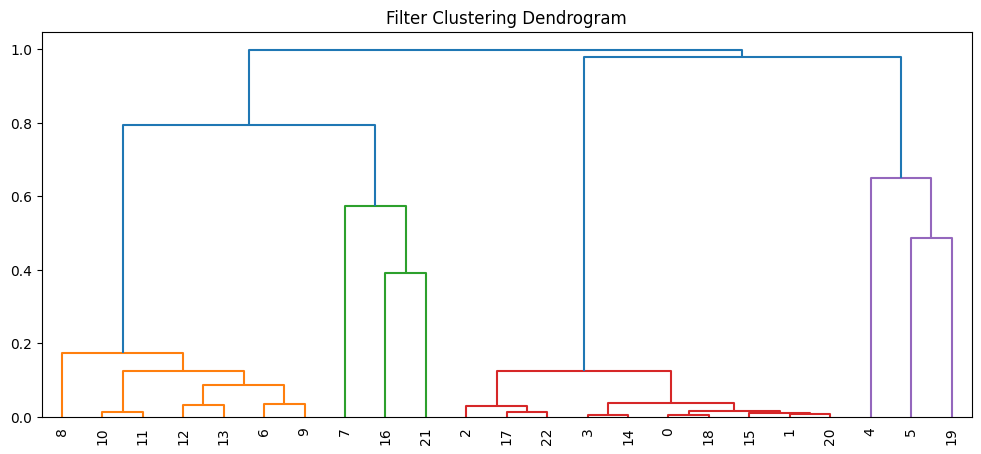

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 10.25%
F1-score: 10.25%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.91%
F1-score: 8.91%
Analyzing filter: 2


...

F1-score: 1.91%
F1-score: 1.91%
Analyzing filter: 21
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 1.70%
F1-score: 1.70%
Analyzing filter: 22
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 2.96%
F1-score: 2.96%
=========== Clustering Filters ==============


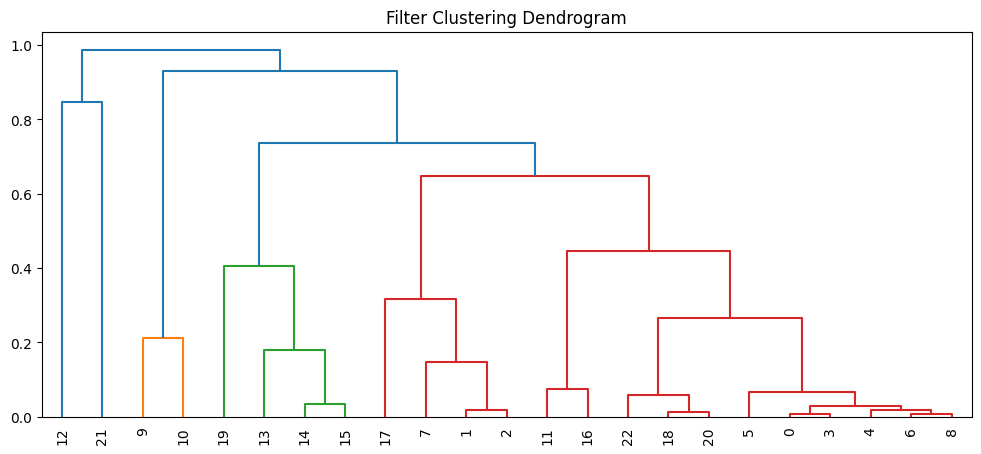

=========== Analysing Fold 2 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 45.20%
F1-score: 45.20%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 55.34%
F1-score: 55.34%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 71.52%
F1-score: 71.52%
Analyzing filter: 19
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 7.60%
F1-score: 7.60%
Analyzing filter: 20
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 14.45%
F1-score: 14.45%
=========== Clustering Filters ==============


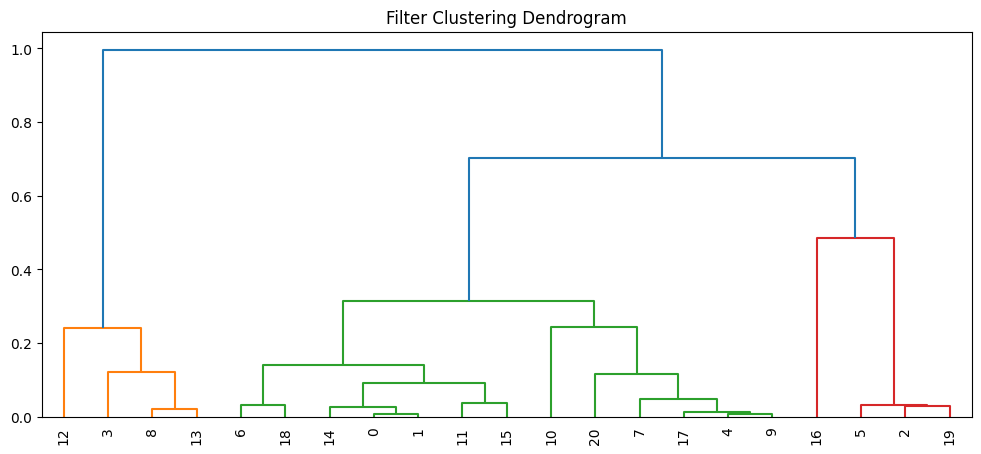

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 7.14%
F1-score: 7.14%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.27%
F1-score: 0.27%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.29%
F1-score: 0.29%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.18%
F1-score: 0.18%
=========== Clustering Filters ==============


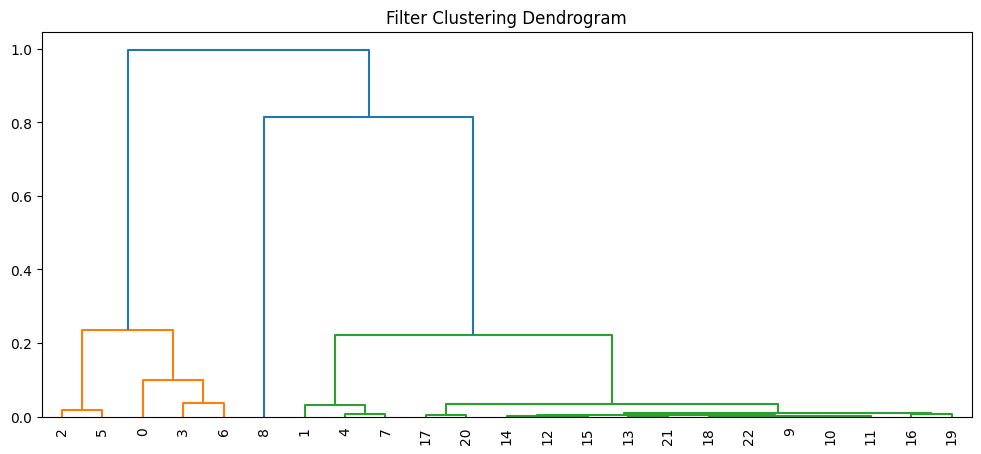

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 31.89%
F1-score: 31.89%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 32.35%
F1-score: 32.35%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 29.19%
F1-score: 29.19%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 29.82%
F1-score: 29.82%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 37.57%
F1-score: 37.57%
=========== Clustering Filters ==============


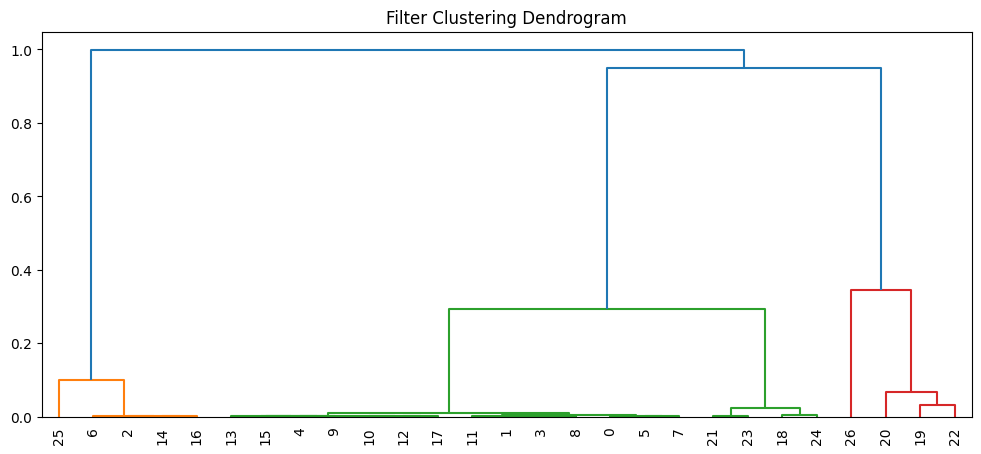

   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   

                                      filter_weights              scaler  \
0                                                 []                  []   
1                                                 []                  []   
2  [[0.38183725, -0.44608337, -0.5699345, -0.1111...  [StandardScaler()]   
3                                                 []                  []   
4                                                 []                  []   

                                              backup  
0  [0.34168336673297567, [0.019518021, -0.0008676...  
1  [0.1411558048087303, [-0.08586581, -0.11001619...  
2  [0.7472965281725314, [0.38183725, -0.44608337,...  
3  [0.07137939780410121, [0.098782726, -0.0555588...  
4  [0.40898407371082823, [0.04120071, -0.09232208...  
Nu

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 74.73%


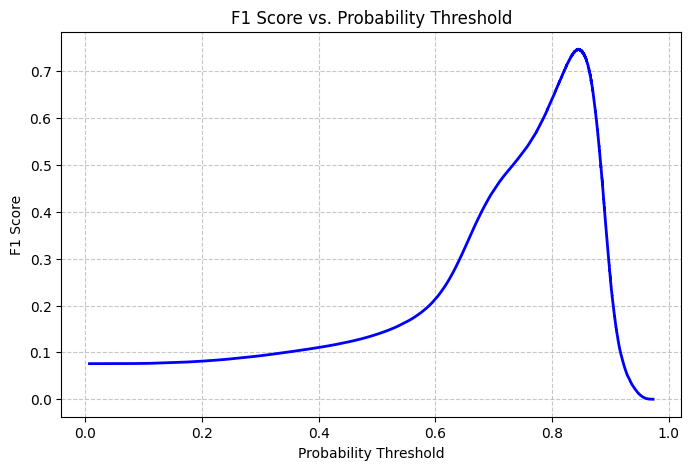

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



======= BEST FILTERS: LOGISTIC REGRESSION =======

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
27434008


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 74.73%


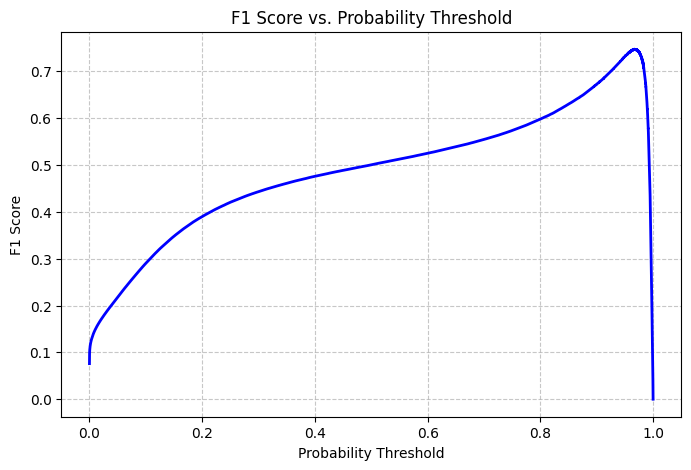

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold

======= BEST 3 MODELS =======

=========== Analysing Fold 0 ==============


...

=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Finding Best Threshold ==============
=========== Finding Best Threshold ==============
F1-score: 8.62%


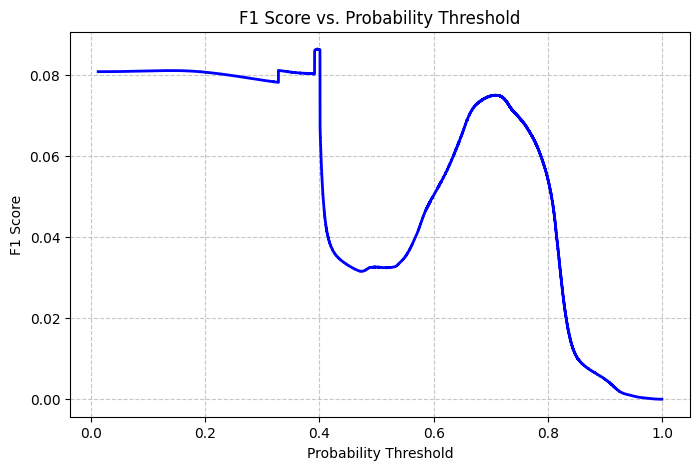

=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


...

F1-score: 2.59%
F1-score: 2.59%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 31.43%
F1-score: 31.43%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.59%
F1-score: 2.59%
=========== Clustering Filters ==============


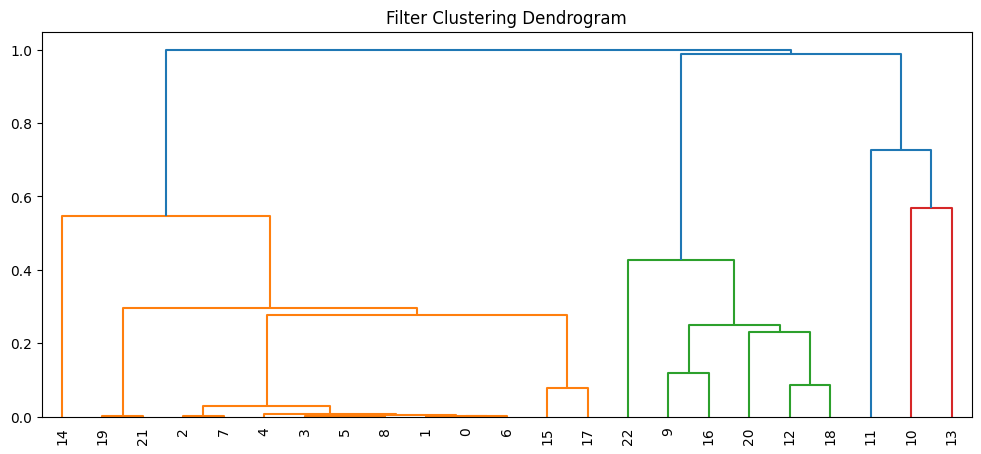

=========== Analysing Fold 1 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.05%
F1-score: 0.05%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.08%
F1-score: 0.08%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 0.06%
F1-score: 0.06%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.06%
F1-score: 0.06%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.05%
F1-score: 0.05%
=========== Clustering Filters ==============


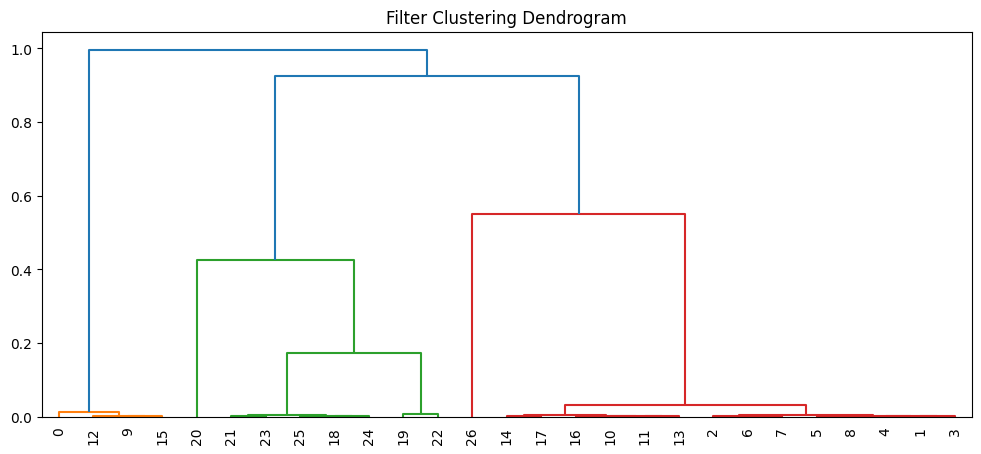

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 3.62%
F1-score: 3.62%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 3.61%
F1-score: 3.61%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 3.42%
F1-score: 3.42%
Analyzing filter: 19


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 4.67%
F1-score: 4.67%
Analyzing filter: 20


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 3.41%
F1-score: 3.41%
=========== Clustering Filters ==============


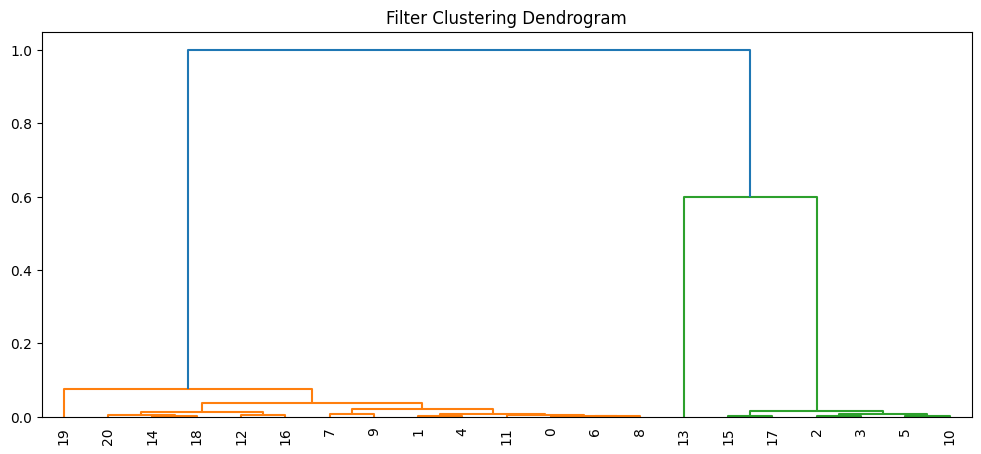

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.48%
F1-score: 0.48%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.63%
F1-score: 0.63%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.69%
F1-score: 0.69%
Analyzing filter: 23


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.52%
F1-score: 0.52%
Analyzing filter: 24


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.63%
F1-score: 0.63%
=========== Clustering Filters ==============


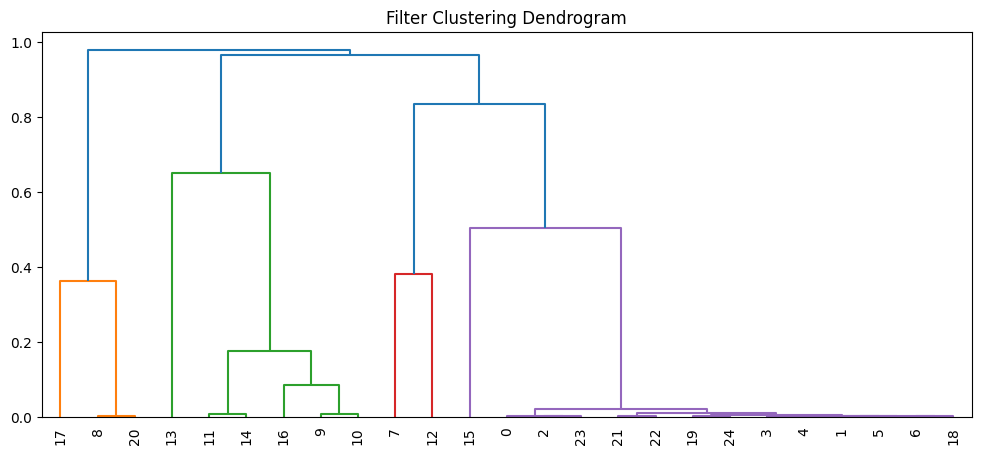

=========== Analysing Fold 4 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.41%
F1-score: 0.41%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.35%
F1-score: 0.35%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 0.30%
F1-score: 0.30%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 1.82%
F1-score: 1.82%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.34%
F1-score: 0.34%
=========== Clustering Filters ==============


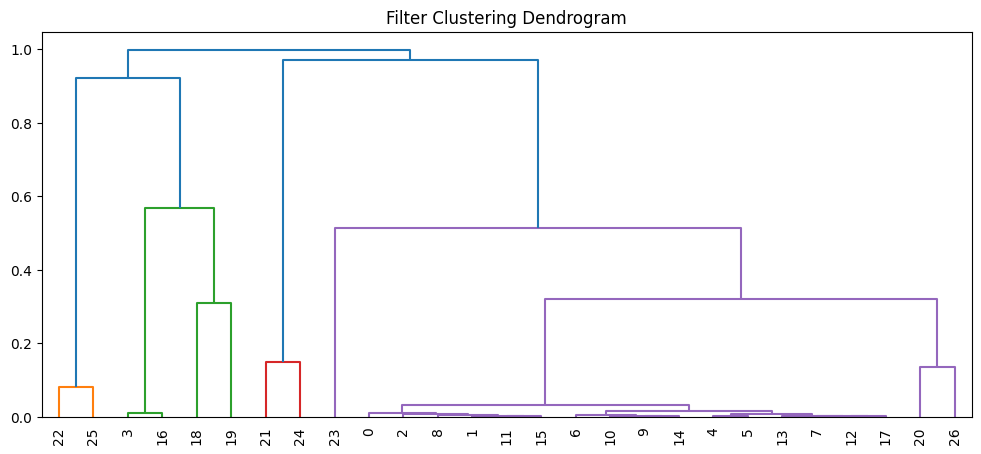

no filters selected. Extract the best one in the backup
   lopo_fold  cv_fold  model_ID  \
0          0        0         0   
1          0        1         0   
2          0        2         0   
3          0        3         0   
4          0        4         0   
5          1        0         0   
6          1        1         0   
7          1        2         0   
8          1        3         0   
9          1        4         0   

                                      filter_weights              scaler  \
0                                                 []                  []   
1                                                 []                  []   
2  [[0.38183725, -0.44608337, -0.5699345, -0.1111...  [StandardScaler()]   
3                                                 []                  []   
4                                                 []                  []   
5  [[0.036002584, -0.06103007, -0.009303674, -0.0...  [StandardScaler()]   
6                         

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 31.43%


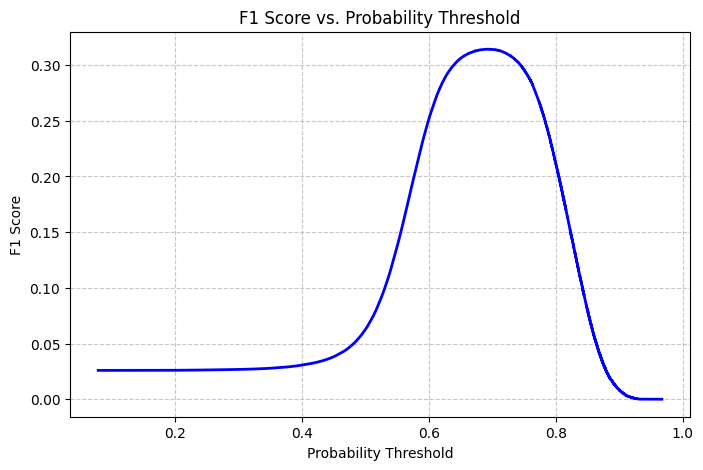

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



======= BEST FILTERS: LOGISTIC REGRESSION =======

Number of CV folds: 5
=========== Analysing Fold 0 ==============
20916145


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 31.43%


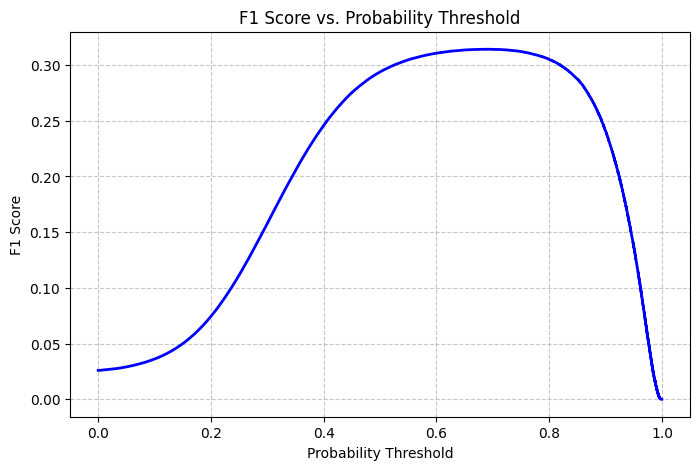

Number of CV folds: 5
=========== Analysing Fold 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
Number of CV folds: 5
=========== Analysing Fold 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold

======= BEST 3 MODELS =======

=========== Analysing Fold 0 ==============


...

=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Finding Best Threshold ==============
=========== Finding Best Threshold ==============
F1-score: 2.05%


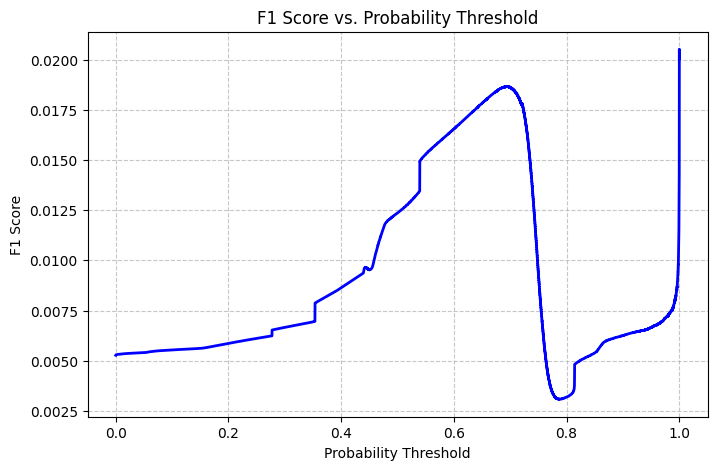

=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


...

=========== Finding Best Threshold ==============
F1-score: 0.72%
F1-score: 0.72%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.05%
F1-score: 0.05%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.09%
F1-score: 0.09%
=========== Clustering Filters ==============


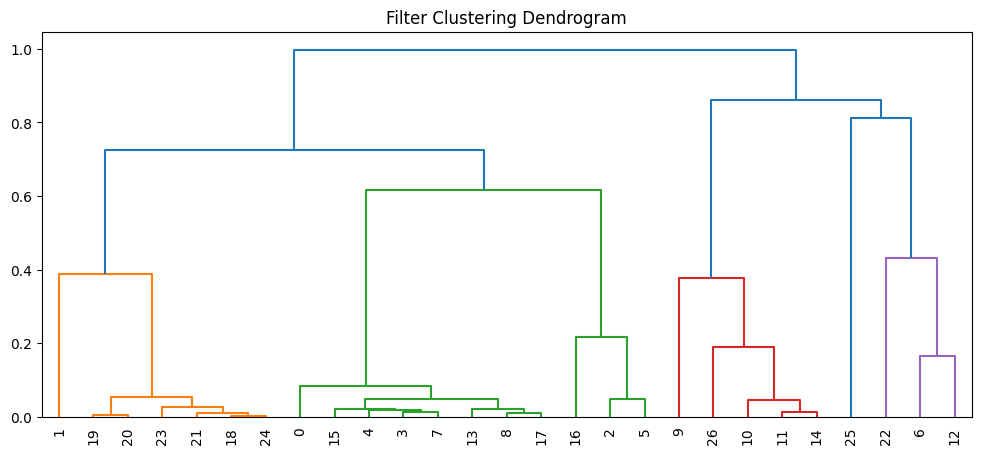

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 7.24%
F1-score: 7.24%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 7.57%
F1-score: 7.57%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

=========== Finding Best Threshold ==============
F1-score: 1.41%
F1-score: 1.41%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 1.97%
F1-score: 1.97%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 2.37%
F1-score: 2.37%
=========== Clustering Filters ==============


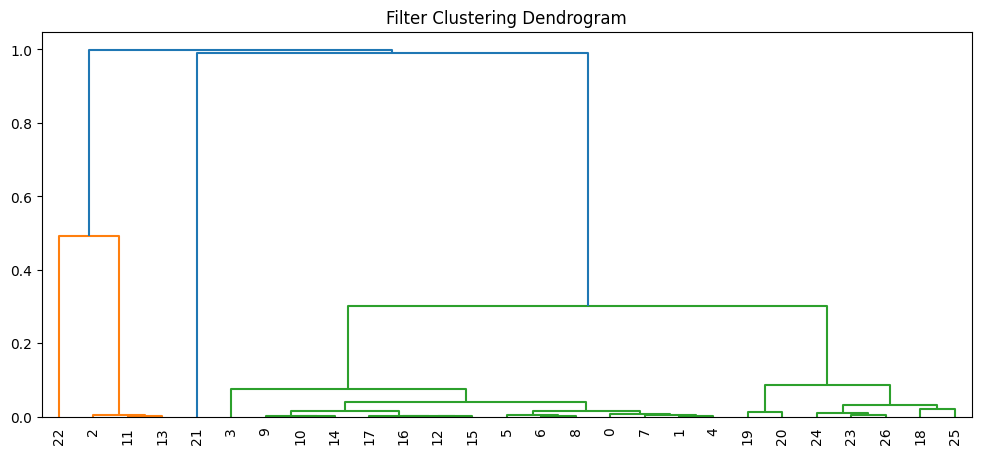

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.05%
F1-score: 1.05%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 1.31%
F1-score: 1.31%
Analyzing filter: 23


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 24


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.26%
F1-score: 1.26%
=========== Clustering Filters ==============


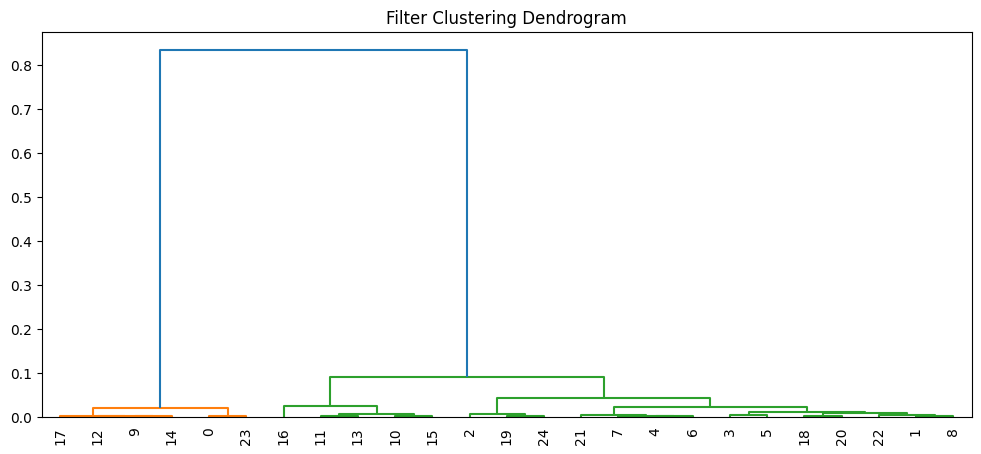

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 34.33%
F1-score: 34.33%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 27.76%
F1-score: 27.76%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 36.29%
F1-score: 36.29%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 32.20%
F1-score: 32.20%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 27.86%
F1-score: 27.86%
=========== Clustering Filters ==============


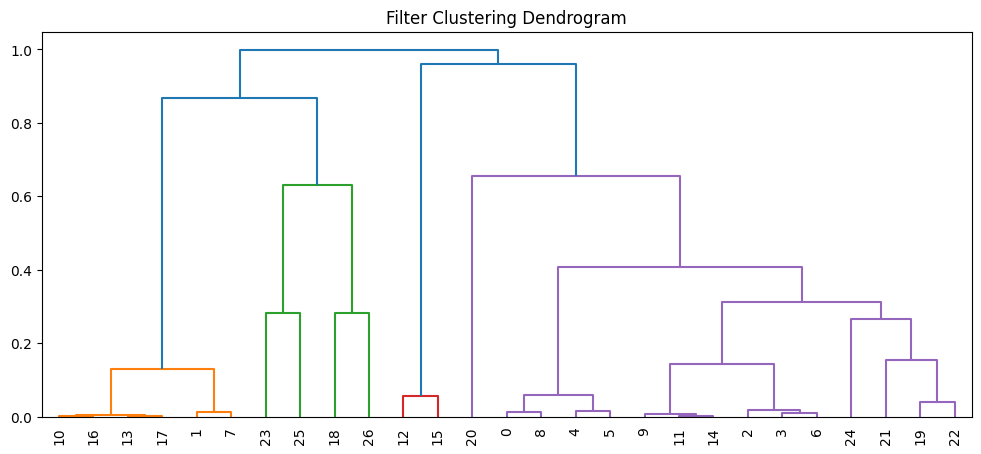

=========== Analysing Fold 4 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 29.77%
F1-score: 29.77%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 37.02%
F1-score: 37.02%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 48.74%
F1-score: 48.74%
Analyzing filter: 15
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 49.99%
F1-score: 49.99%
Analyzing filter: 16
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 45.12%
F1-score: 45.12%
=========== Clustering Filters ==============


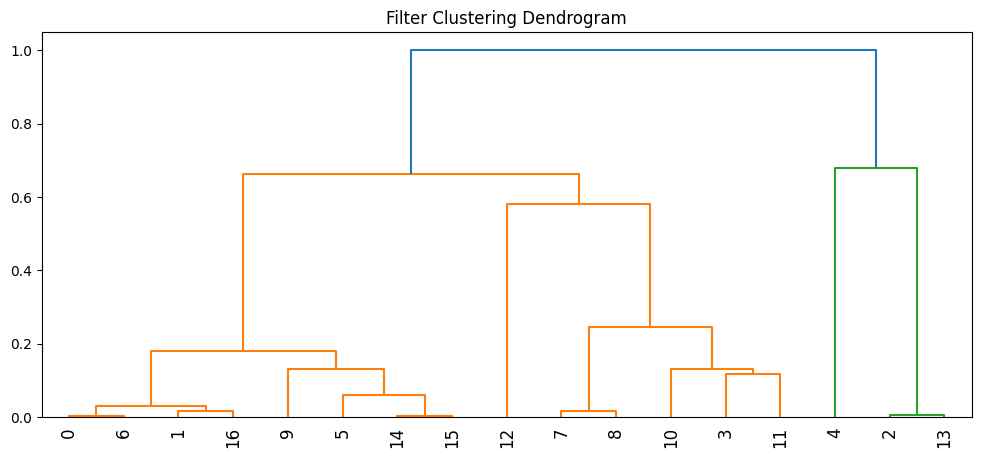

    lopo_fold  cv_fold  model_ID  \
0           0        0         0   
1           0        1         0   
2           0        2         0   
3           0        3         0   
4           0        4         0   
5           1        0         0   
6           1        1         0   
7           1        2         0   
8           1        3         0   
9           1        4         0   
10          2        0         0   
11          2        1         0   
12          2        2         0   
13          2        3         0   
14          2        4         0   

                                       filter_weights              scaler  \
0                                                  []                  []   
1                                                  []                  []   
2   [[0.38183725, -0.44608337, -0.5699345, -0.1111...  [StandardScaler()]   
3                                                  []                  []   
4                                     

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 36.20%


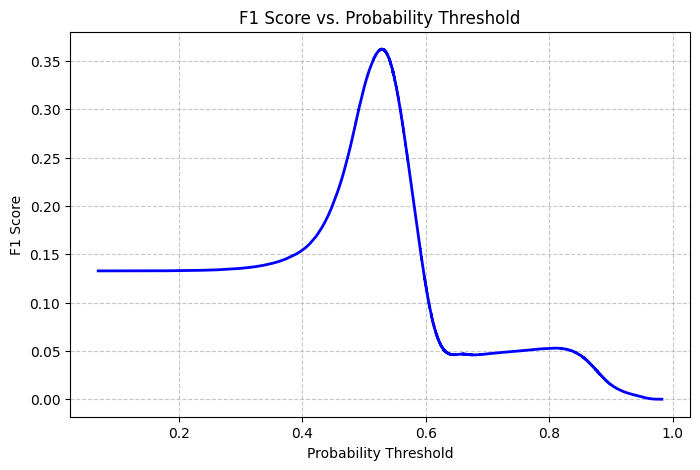

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta


======= BEST FILTERS: LOGISTIC REGRESSION =======

Number of CV folds: 5
=========== Analysing Fold 0 ==============
19992114


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


...

=========== Analysing Fold 4 ==============
27125026


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 19.77%


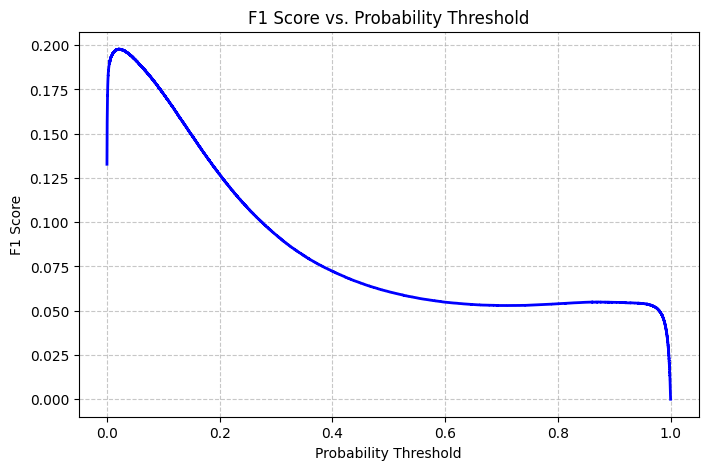

Number of CV folds: 5
=========== Analysing Fold 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 4 ==============


...

=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Finding Best Threshold ==============
=========== Finding Best Threshold ==============
F1-score: 13.62%


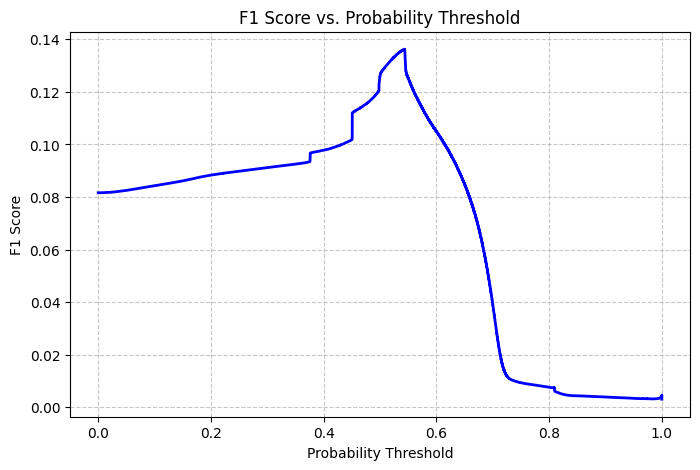

=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


...

=========== Finding Best Threshold ==============
F1-score: 0.05%
F1-score: 0.05%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.78%
F1-score: 0.78%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.06%
F1-score: 0.06%
=========== Clustering Filters ==============


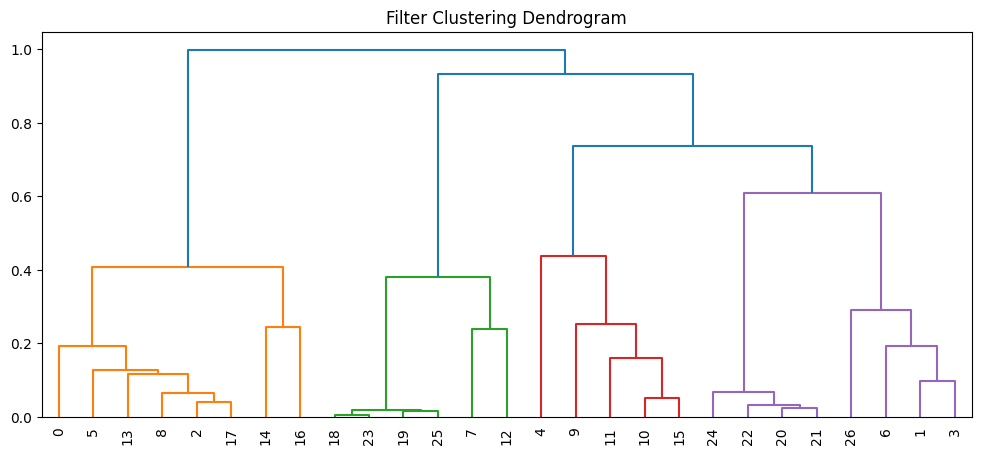

=========== Analysing Fold 1 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.00%
F1-score: 0.00%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.01%
F1-score: 0.01%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

=========== Finding Best Threshold ==============
F1-score: 0.01%
F1-score: 0.01%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.00%
F1-score: 0.00%
Analyzing filter: 22
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.03%
F1-score: 0.03%
=========== Clustering Filters ==============


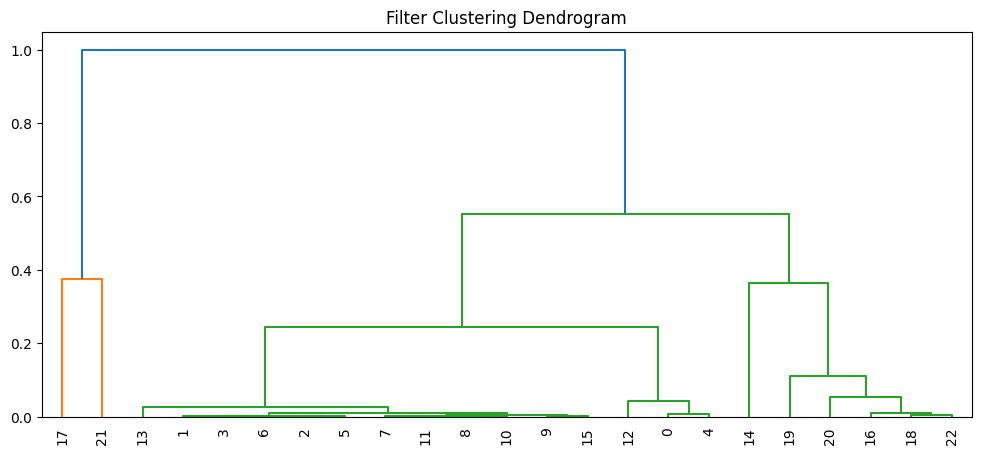

=========== Analysing Fold 2 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.50%
F1-score: 0.50%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.50%
F1-score: 0.50%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.50%
F1-score: 0.50%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.51%
F1-score: 0.51%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.50%
F1-score: 0.50%
=========== Clustering Filters ==============


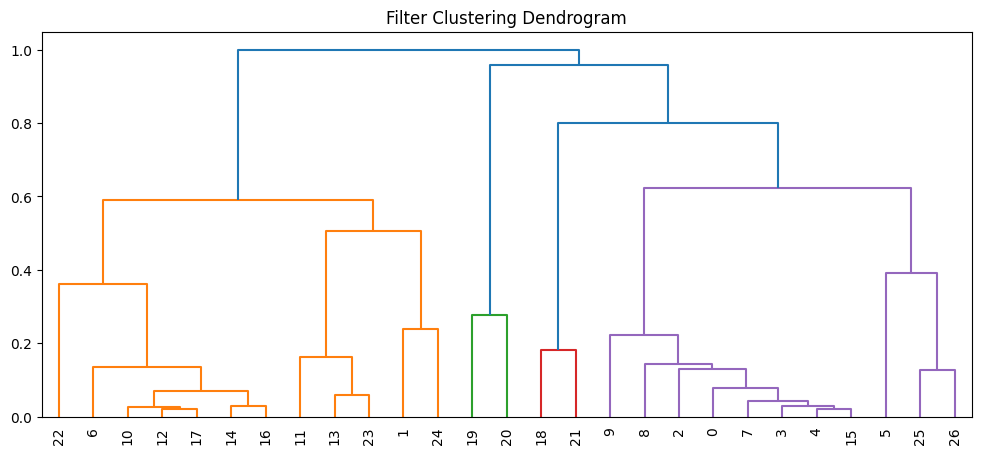

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 27.34%
F1-score: 27.34%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 32.41%
F1-score: 32.41%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 28.26%
F1-score: 28.26%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 27.76%
F1-score: 27.76%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 31.94%
F1-score: 31.94%
=========== Clustering Filters ==============


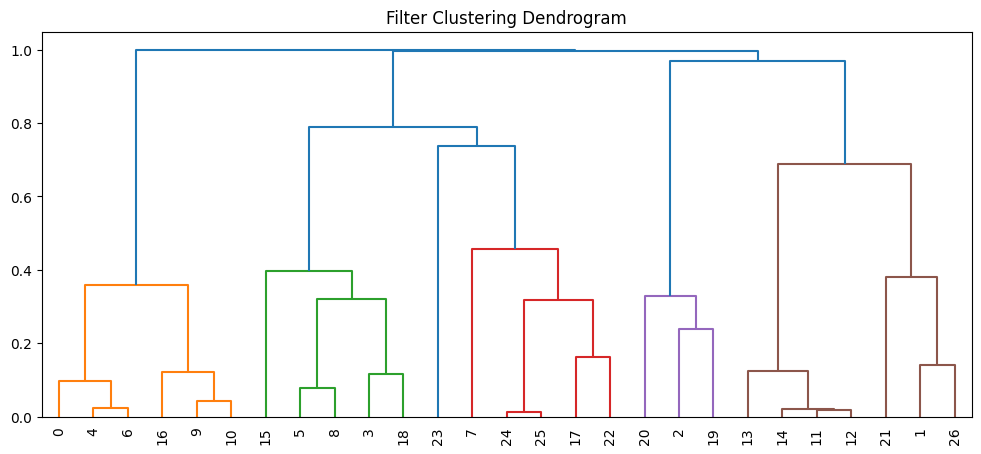

=========== Analysing Fold 4 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 10.02%
F1-score: 10.02%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 7.55%
F1-score: 7.55%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 8.36%
F1-score: 8.36%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 5.01%
F1-score: 5.01%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 22.79%
F1-score: 22.79%
=========== Clustering Filters ==============


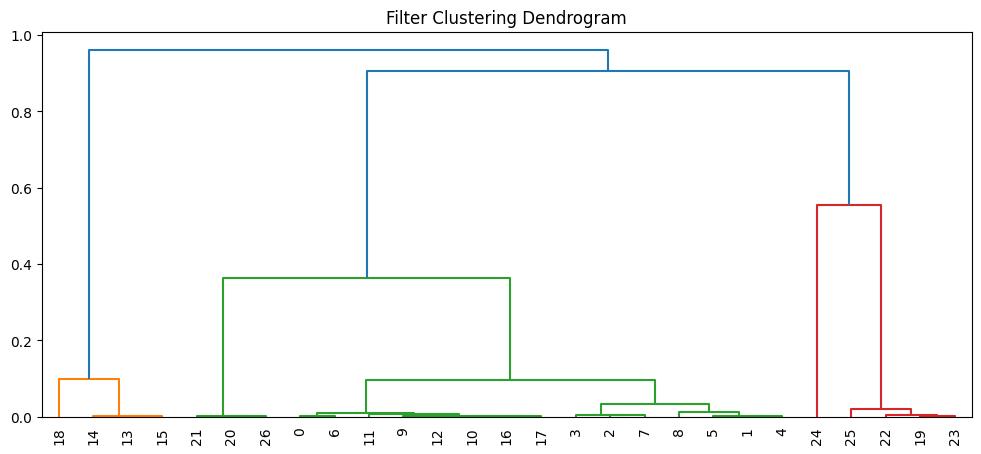

    lopo_fold  cv_fold  model_ID  \
0           0        0         0   
1           0        1         0   
2           0        2         0   
3           0        3         0   
4           0        4         0   
5           1        0         0   
6           1        1         0   
7           1        2         0   
8           1        3         0   
9           1        4         0   
10          2        0         0   
11          2        1         0   
12          2        2         0   
13          2        3         0   
14          2        4         0   
15          3        0         0   
16          3        1         0   
17          3        2         0   
18          3        3         0   
19          3        4         0   

                                       filter_weights  \
0                                                  []   
1                                                  []   
2   [[0.38183725, -0.44608337, -0.5699345, -0.1111...   
3              

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 60.50%


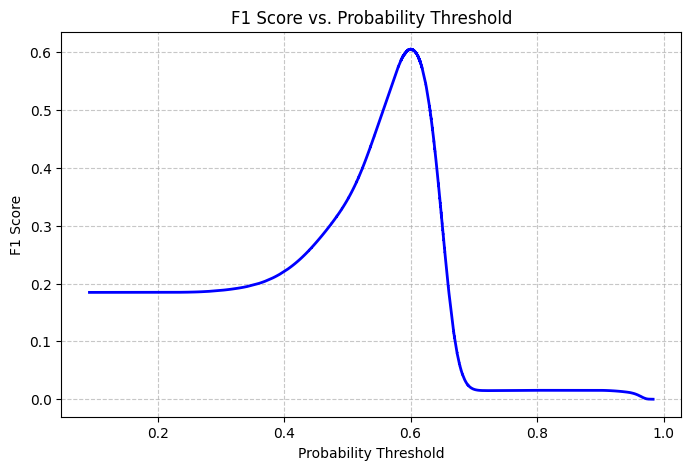

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta


======= BEST FILTERS: LOGISTIC REGRESSION =======

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
20486965


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
17354402


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 34.81%


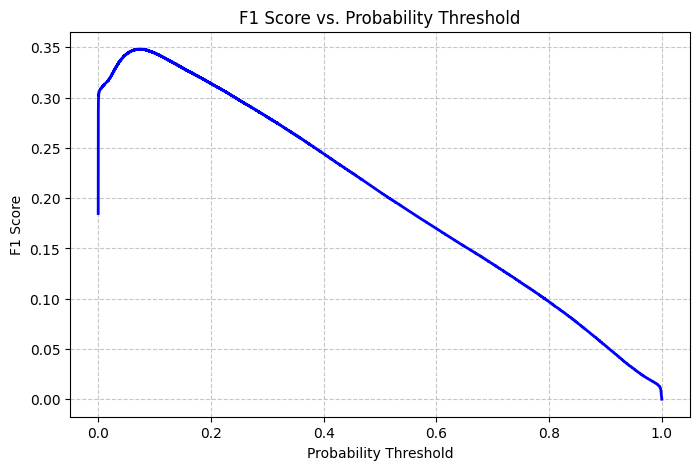

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 4 ==============
No filter for 4-th fold
Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============


...

=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Finding Best Threshold ==============
=========== Finding Best Threshold ==============
F1-score: 12.40%


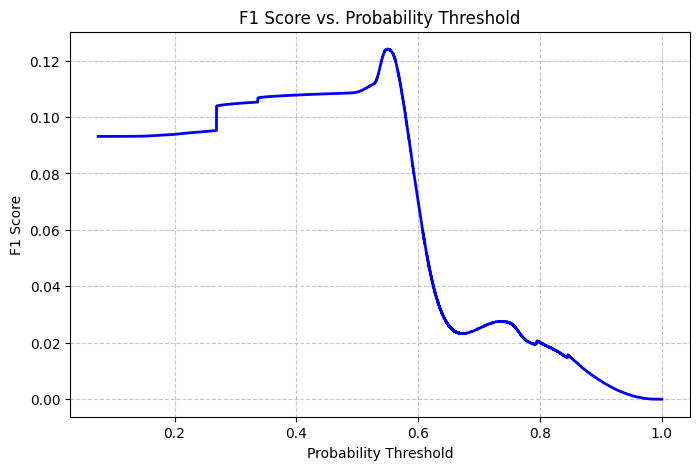

=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_12229/2957815505.py:52: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_12229/2957815505.py:52: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


...

=========== Finding Best Threshold ==============
F1-score: 37.45%
F1-score: 37.45%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 30.56%
F1-score: 30.56%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 29.22%
F1-score: 29.22%
=========== Clustering Filters ==============


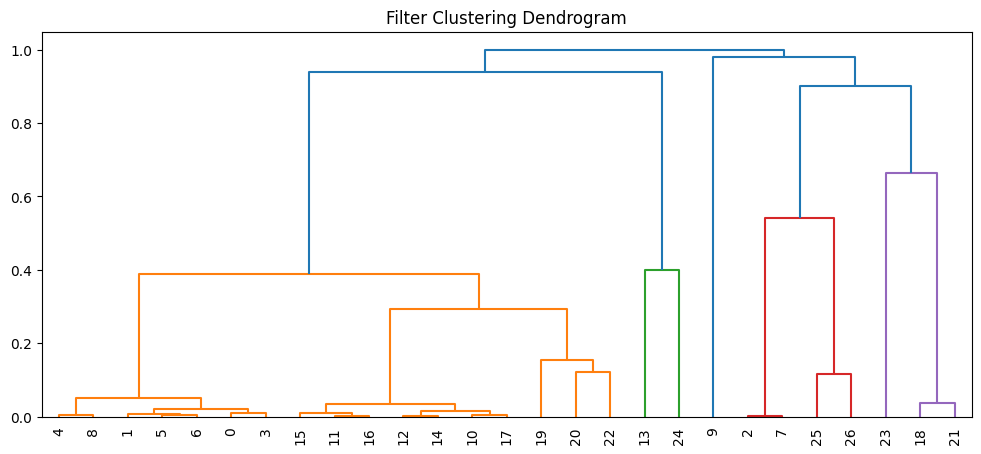

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.00%
F1-score: 0.00%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.01%
F1-score: 0.01%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 0.00%
F1-score: 0.00%
Analyzing filter: 21
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.07%
F1-score: 0.07%
Analyzing filter: 22
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.04%
F1-score: 0.04%
=========== Clustering Filters ==============


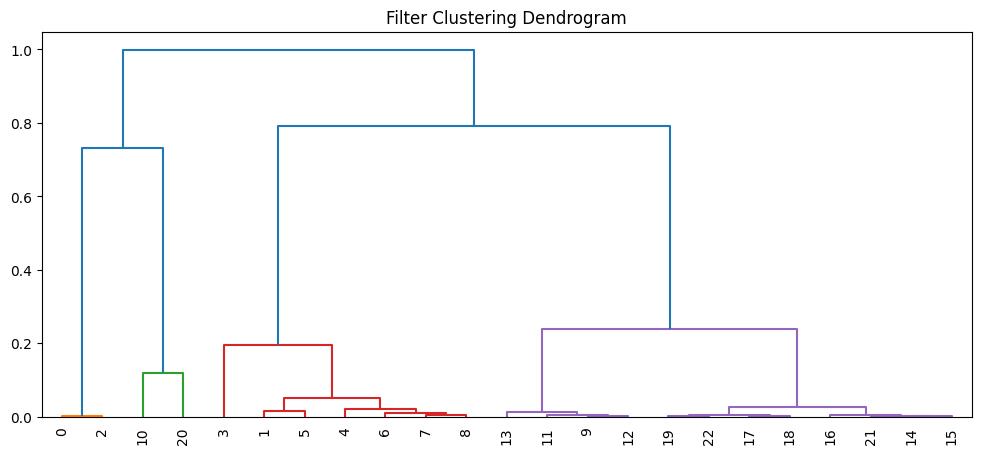

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.14%
F1-score: 2.14%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 38.77%
F1-score: 38.77%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 2.09%
F1-score: 2.09%
Analyzing filter: 19


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.42%
F1-score: 0.42%
Analyzing filter: 20


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.12%
F1-score: 0.12%
=========== Clustering Filters ==============


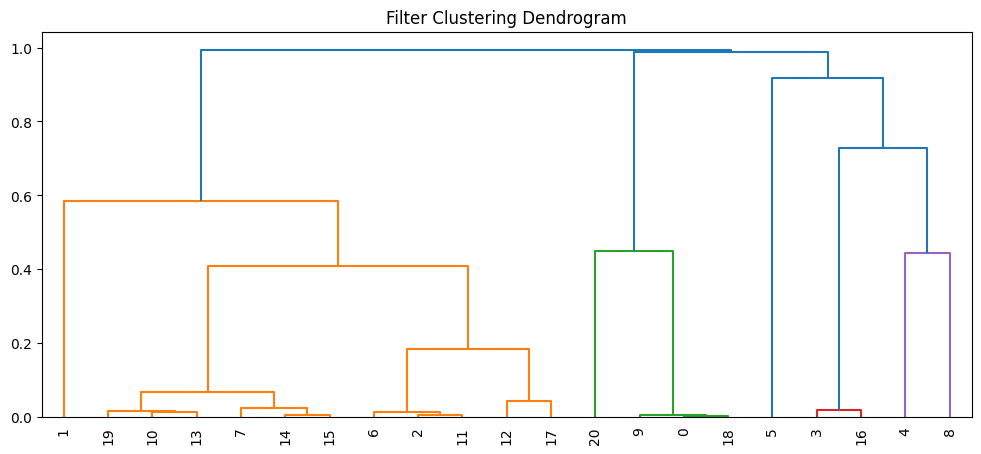

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.07%
F1-score: 0.07%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.23%
F1-score: 0.23%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 0.11%
F1-score: 0.11%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.10%
F1-score: 0.10%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 1.07%
F1-score: 1.07%
=========== Clustering Filters ==============


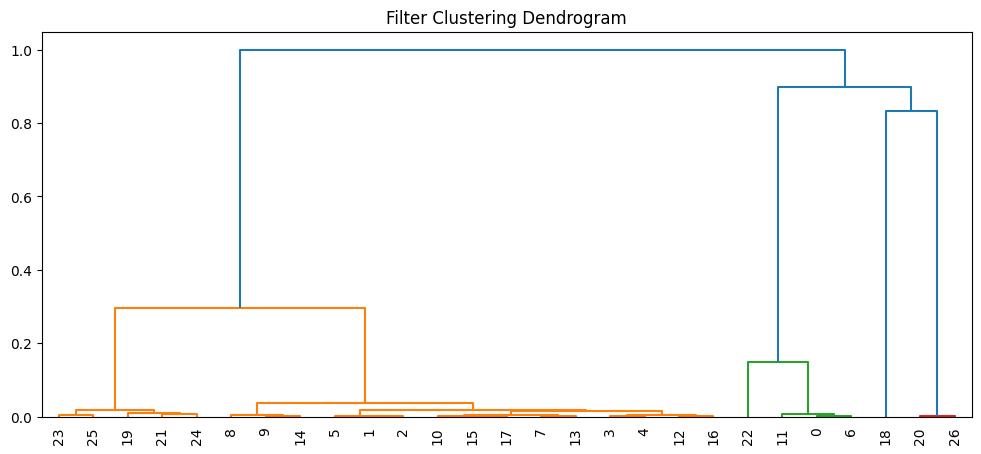

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.22%
F1-score: 0.22%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.15%
F1-score: 0.15%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 4.09%
F1-score: 4.09%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 13.57%
F1-score: 13.57%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.14%
F1-score: 2.14%
=========== Clustering Filters ==============


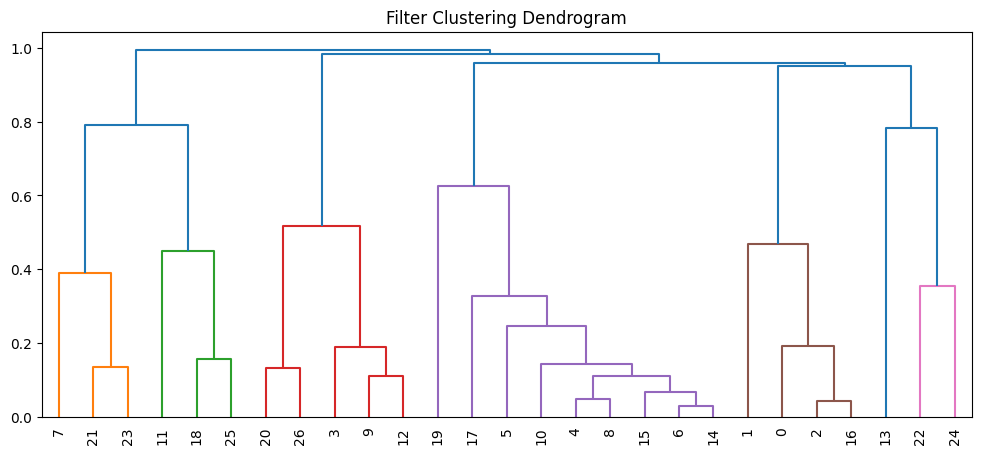

    lopo_fold  cv_fold  model_ID  \
0           0        0         0   
1           0        1         0   
2           0        2         0   
3           0        3         0   
4           0        4         0   
5           1        0         0   
6           1        1         0   
7           1        2         0   
8           1        3         0   
9           1        4         0   
10          2        0         0   
11          2        1         0   
12          2        2         0   
13          2        3         0   
14          2        4         0   
15          3        0         0   
16          3        1         0   
17          3        2         0   
18          3        3         0   
19          3        4         0   
20          4        0         0   
21          4        1         0   
22          4        2         0   
23          4        3         0   
24          4        4         0   

                                       filter_weights  \
0     

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 63.56%


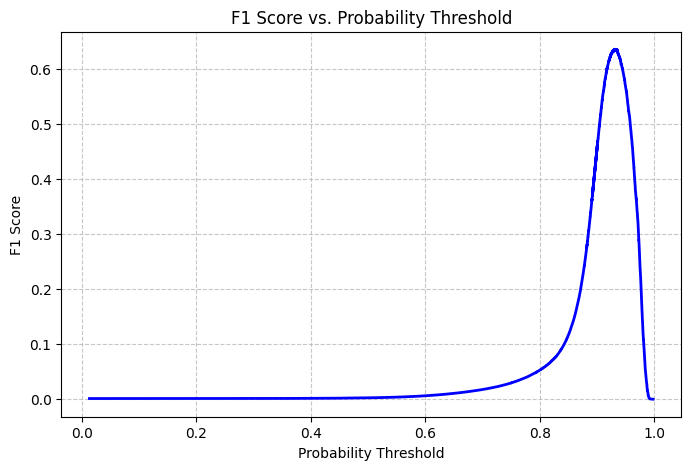

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



======= BEST FILTERS: LOGISTIC REGRESSION =======

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
21424723


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 63.56%


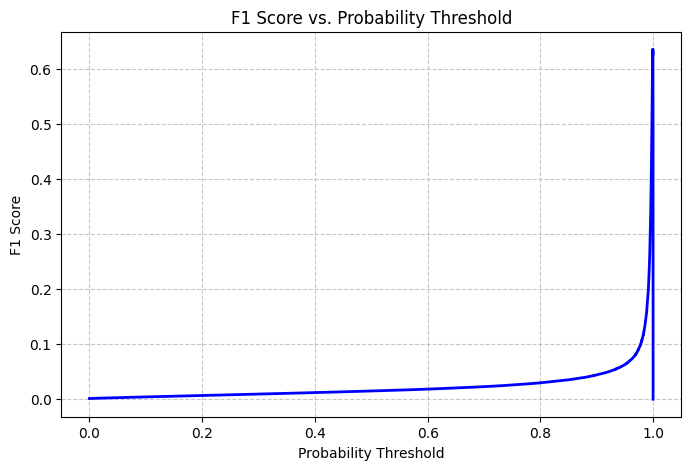

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold

======= BEST 3 MODELS =======

=========== Analysing Fold 0 ==============


...

=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Finding Best Threshold ==============
=========== Finding Best Threshold ==============
F1-score: 11.39%


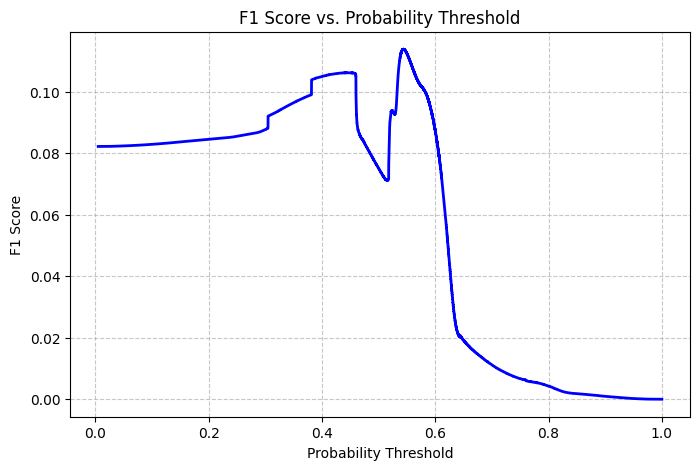

=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_12229/2957815505.py:52: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


...

=========== Finding Best Threshold ==============
F1-score: 22.21%
F1-score: 22.21%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.90%
F1-score: 8.90%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.53%
F1-score: 0.53%
=========== Clustering Filters ==============


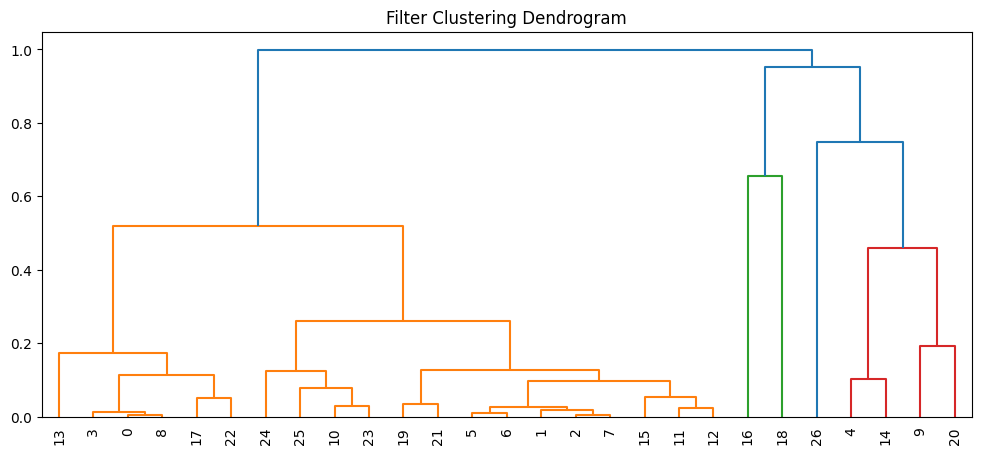

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.14%
F1-score: 0.14%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.62%
F1-score: 2.62%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 1.96%
F1-score: 1.96%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.04%
F1-score: 2.04%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.99%
F1-score: 1.99%
=========== Clustering Filters ==============


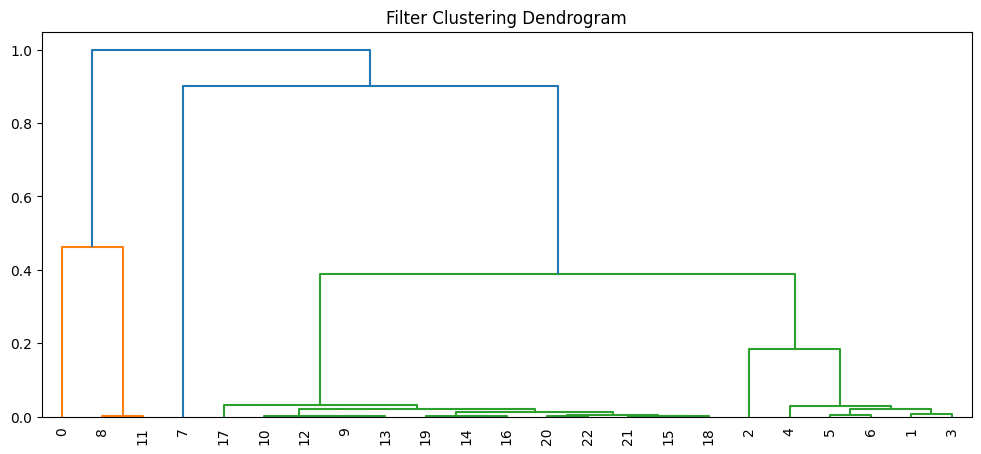

=========== Analysing Fold 2 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 40.39%
F1-score: 40.39%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 62.07%
F1-score: 62.07%
Analyzing filter: 2


...

F1-score: 16.57%
F1-score: 16.57%
Analyzing filter: 21
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 2.46%
F1-score: 2.46%
Analyzing filter: 22
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 49.60%
F1-score: 49.60%
=========== Clustering Filters ==============


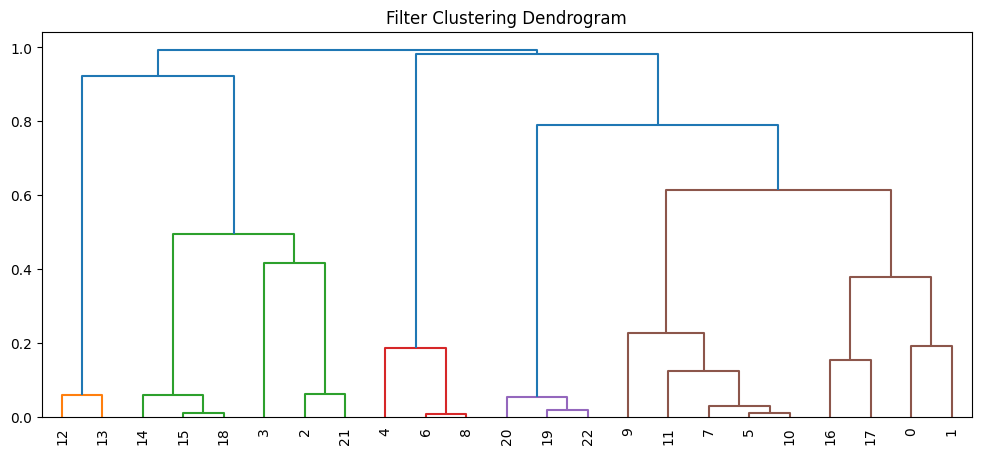

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 41.69%
F1-score: 41.69%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 40.91%
F1-score: 40.91%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 29.34%
F1-score: 29.34%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 57.44%
F1-score: 57.44%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 52.41%
F1-score: 52.41%
=========== Clustering Filters ==============


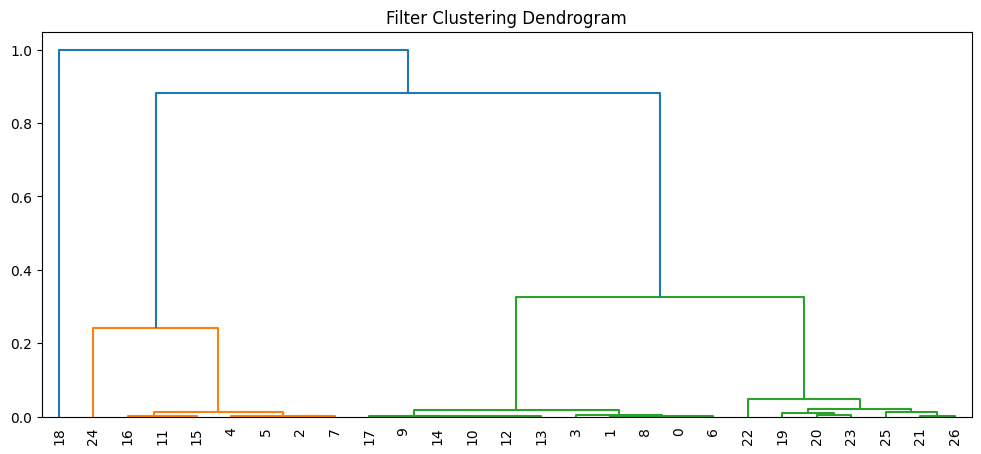

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.74%
F1-score: 0.74%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.83%
F1-score: 0.83%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.06%
F1-score: 0.06%
Analyzing filter: 23


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.05%
F1-score: 0.05%
Analyzing filter: 24


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 48.88%
F1-score: 48.88%
=========== Clustering Filters ==============


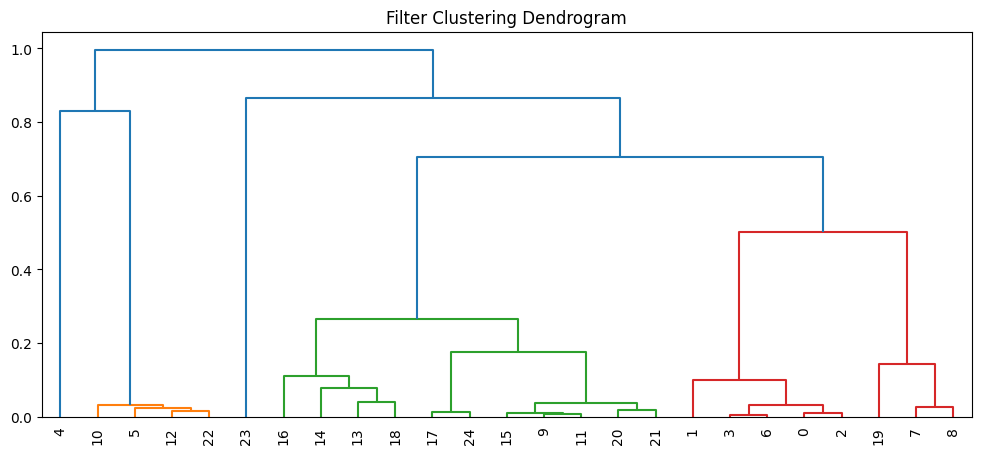

    lopo_fold  cv_fold  model_ID  \
0           0        0         0   
1           0        1         0   
2           0        2         0   
3           0        3         0   
4           0        4         0   
5           1        0         0   
6           1        1         0   
7           1        2         0   
8           1        3         0   
9           1        4         0   
10          2        0         0   
11          2        1         0   
12          2        2         0   
13          2        3         0   
14          2        4         0   
15          3        0         0   
16          3        1         0   
17          3        2         0   
18          3        3         0   
19          3        4         0   
20          4        0         0   
21          4        1         0   
22          4        2         0   
23          4        3         0   
24          4        4         0   
25          5        0         0   
26          5        1      

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 62.07%


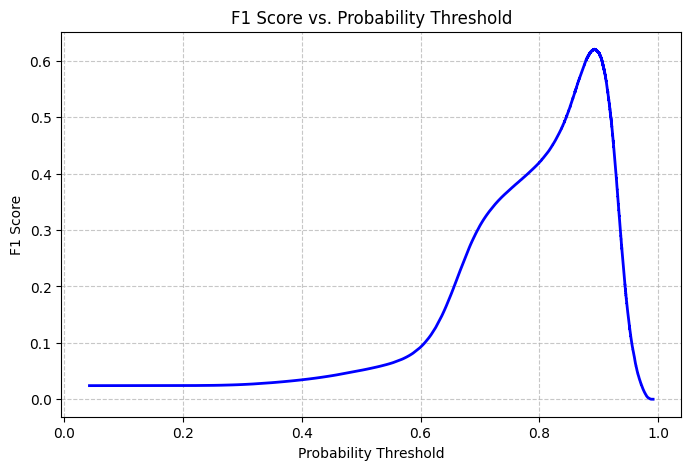

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



======= BEST FILTERS: LOGISTIC REGRESSION =======

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
27125026


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 62.07%


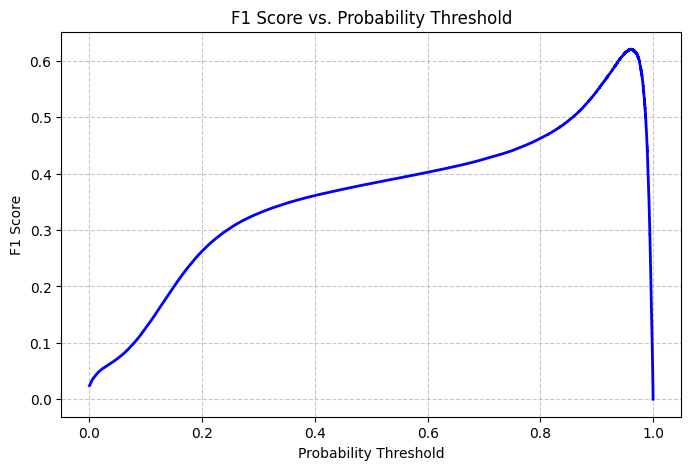

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============


...

=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Finding Best Threshold ==============
=========== Finding Best Threshold ==============
F1-score: 26.22%


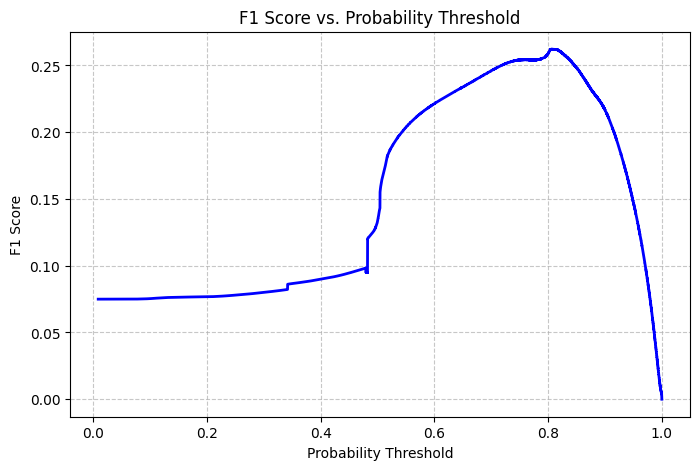

=========== Analysing Sample 0 ==============
=========== Analysing Sample 0 ==============
=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Sample 0 ==============
=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 1 ==============
=========== Analysing Sample 1 ==============


...

F1-score: 18.30%
F1-score: 18.30%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 5.01%
F1-score: 5.01%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 5.01%
F1-score: 5.01%
=========== Clustering Filters ==============


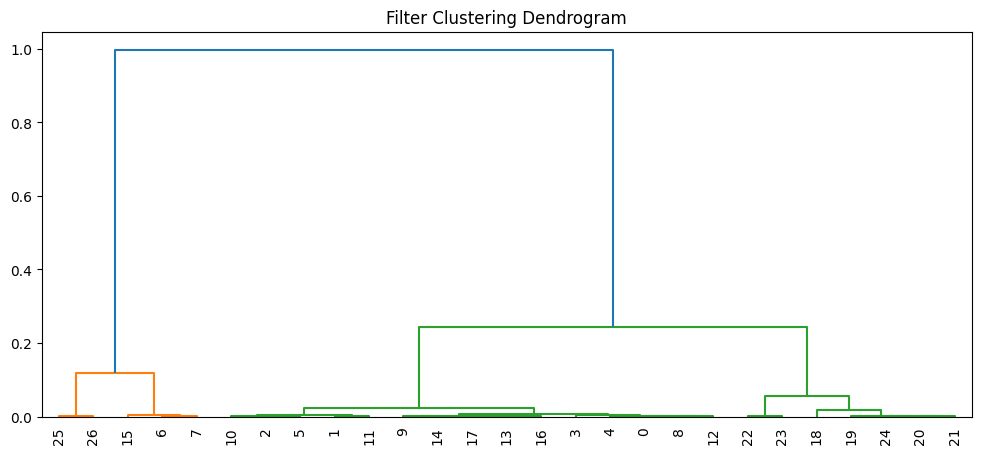

=========== Analysing Fold 1 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.08%
F1-score: 0.08%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.08%
F1-score: 0.08%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 0.05%
F1-score: 0.05%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.12%
F1-score: 0.12%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.12%
F1-score: 0.12%
=========== Clustering Filters ==============


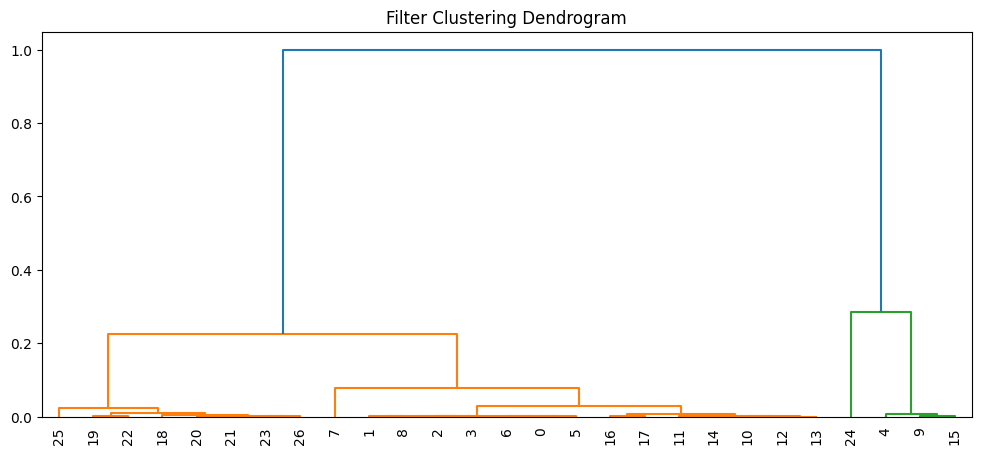

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.24%
F1-score: 0.24%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.64%
F1-score: 2.64%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 8.40%
F1-score: 8.40%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.44%
F1-score: 8.44%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.24%
F1-score: 0.24%
=========== Clustering Filters ==============


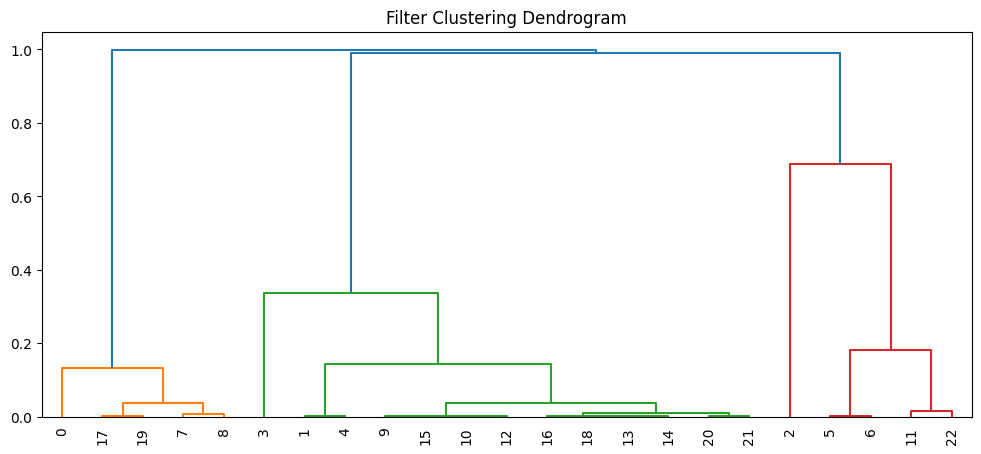

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 23.39%
F1-score: 23.39%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 23.55%
F1-score: 23.55%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 22.65%
F1-score: 22.65%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 23.43%
F1-score: 23.43%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 28.99%
F1-score: 28.99%
=========== Clustering Filters ==============


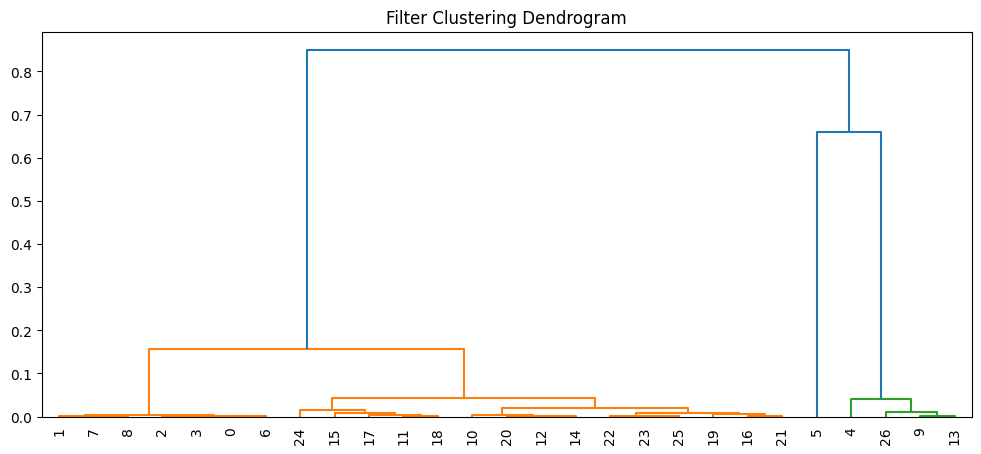

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.61%
F1-score: 2.61%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.65%
F1-score: 2.65%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.15%
F1-score: 0.15%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.31%
F1-score: 2.31%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.35%
F1-score: 2.35%
=========== Clustering Filters ==============


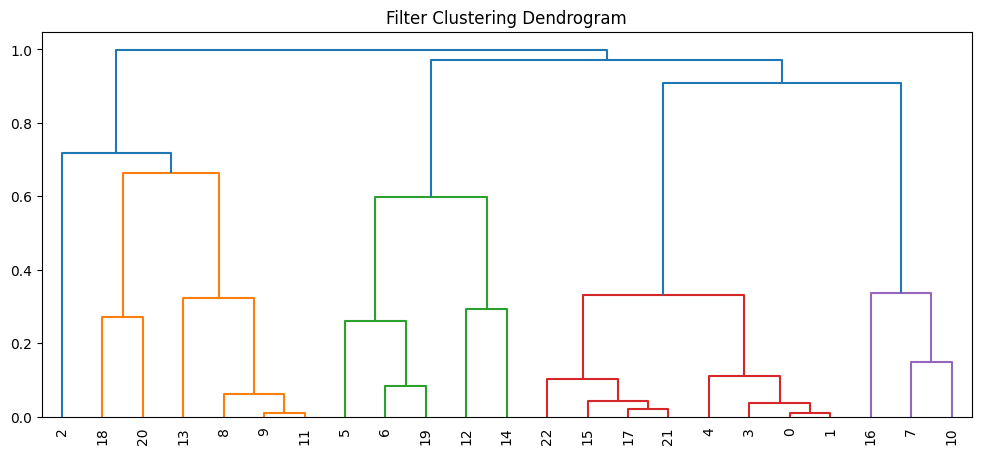

no filters selected. Extract the best one in the backup
    lopo_fold  cv_fold  model_ID  \
0           0        0         0   
1           0        1         0   
2           0        2         0   
3           0        3         0   
4           0        4         0   
5           1        0         0   
6           1        1         0   
7           1        2         0   
8           1        3         0   
9           1        4         0   
10          2        0         0   
11          2        1         0   
12          2        2         0   
13          2        3         0   
14          2        4         0   
15          3        0         0   
16          3        1         0   
17          3        2         0   
18          3        3         0   
19          3        4         0   
20          4        0         0   
21          4        1         0   
22          4        2         0   
23          4        3         0   
24          4        4         0   
25      

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 28.99%


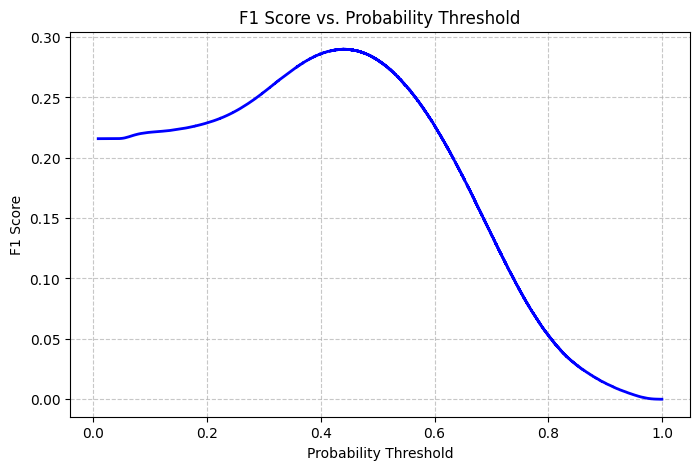

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



======= BEST FILTERS: LOGISTIC REGRESSION =======

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============
21092882


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 22.17%


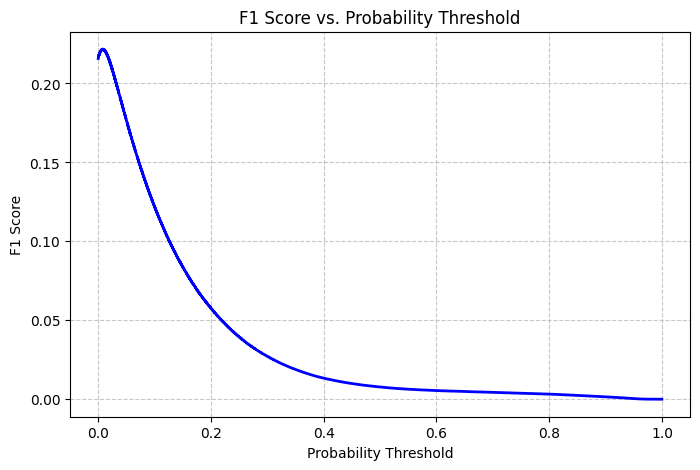

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 4 ==============
No filter for 4-th fold
Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 4 ==============
No filter for 4-th fold

======= BEST 3 MODELS =======

=========== Analysing Fold 0 ==============


...

=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_12229/2957815505.py:52: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_12229/2957815505.py:52: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))
/usr/local/lib/python3.13/dist-packages/sklearn/utils/

=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Finding Best Threshold ==============
=========== Finding Best Threshold ==============
F1-score: 8.30%


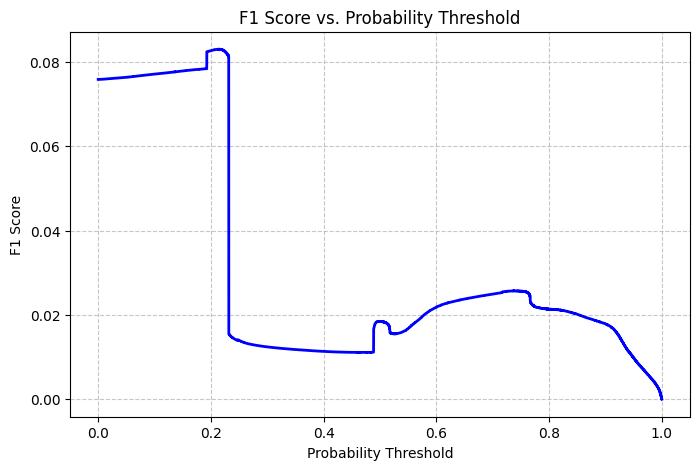

=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_12229/2957815505.py:52: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_12229/2957815505.py:52: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


...

=========== Finding Best Threshold ==============
F1-score: 0.34%
F1-score: 0.34%
Analyzing filter: 21


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.04%
F1-score: 1.04%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.11%
F1-score: 0.11%
=========== Clustering Filters ==============


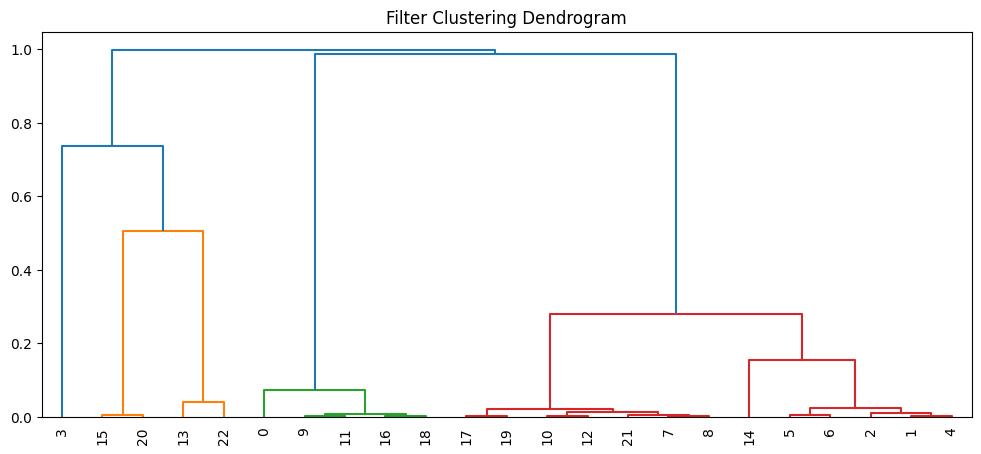

=========== Analysing Fold 1 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.20%
F1-score: 0.20%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.11%
F1-score: 0.11%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.13%
F1-score: 0.13%
=========== Clustering Filters ==============


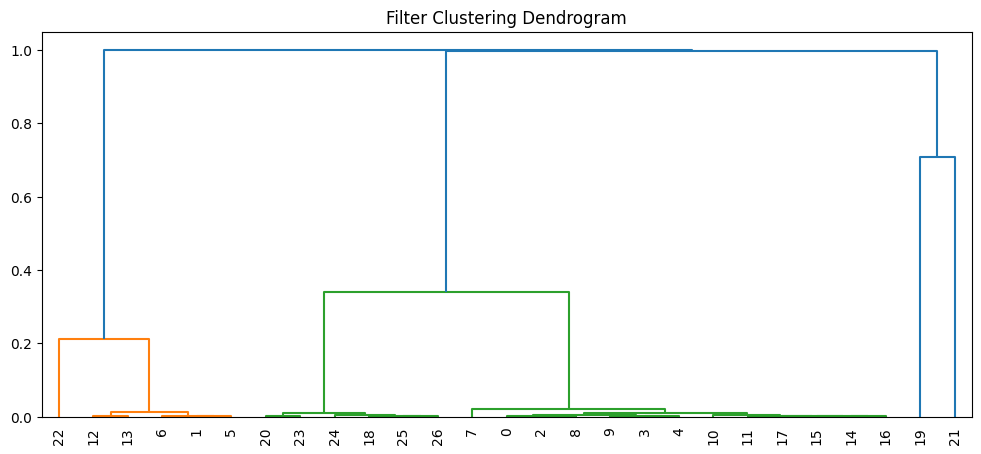

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 35.63%
F1-score: 35.63%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 36.09%
F1-score: 36.09%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 63.45%
F1-score: 63.45%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 37.93%
F1-score: 37.93%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 27.28%
F1-score: 27.28%
=========== Clustering Filters ==============


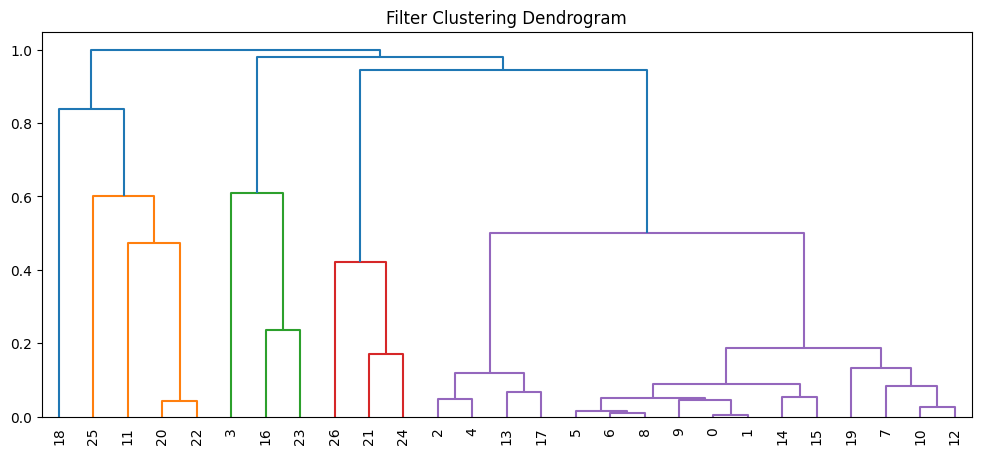

=========== Analysing Fold 3 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.50%
F1-score: 0.50%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.50%
F1-score: 0.50%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 11.62%
F1-score: 11.62%
Analyzing filter: 21
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.50%
F1-score: 0.50%
Analyzing filter: 22


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.35%
F1-score: 1.35%
=========== Clustering Filters ==============


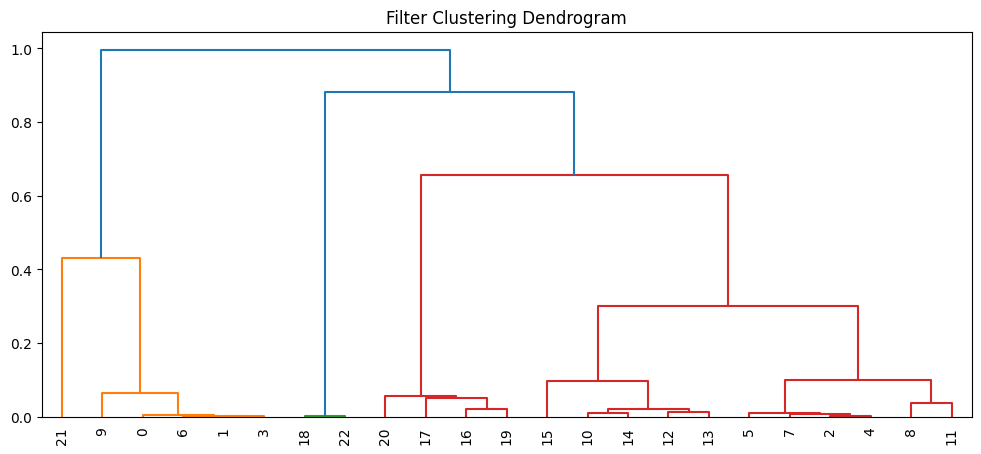

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.04%
F1-score: 0.04%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.47%
F1-score: 0.47%
Analyzing filter: 23


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.05%
F1-score: 0.05%
Analyzing filter: 24


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.04%
F1-score: 0.04%
=========== Clustering Filters ==============


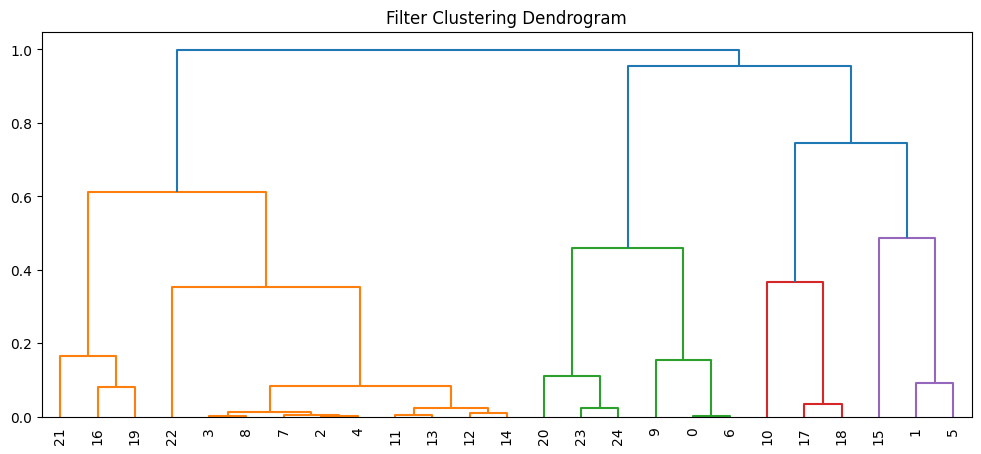

    lopo_fold  cv_fold  model_ID  \
0           0        0         0   
1           0        1         0   
2           0        2         0   
3           0        3         0   
4           0        4         0   
5           1        0         0   
6           1        1         0   
7           1        2         0   
8           1        3         0   
9           1        4         0   
10          2        0         0   
11          2        1         0   
12          2        2         0   
13          2        3         0   
14          2        4         0   
15          3        0         0   
16          3        1         0   
17          3        2         0   
18          3        3         0   
19          3        4         0   
20          4        0         0   
21          4        1         0   
22          4        2         0   
23          4        3         0   
24          4        4         0   
25          5        0         0   
26          5        1      

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 72.53%


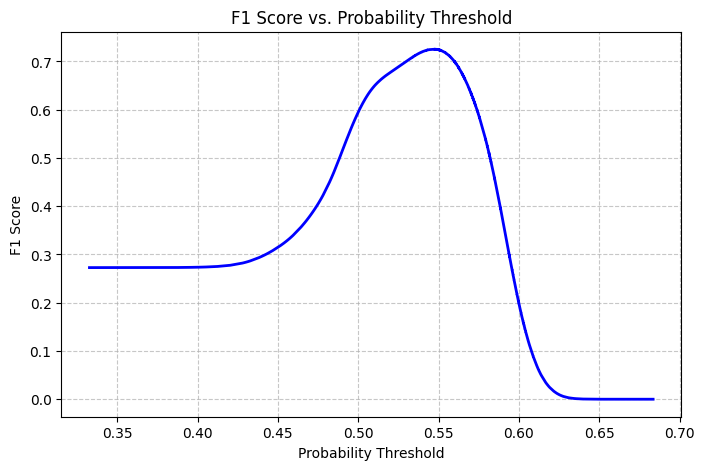

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



======= BEST FILTERS: LOGISTIC REGRESSION =======

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
23547554


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 72.53%


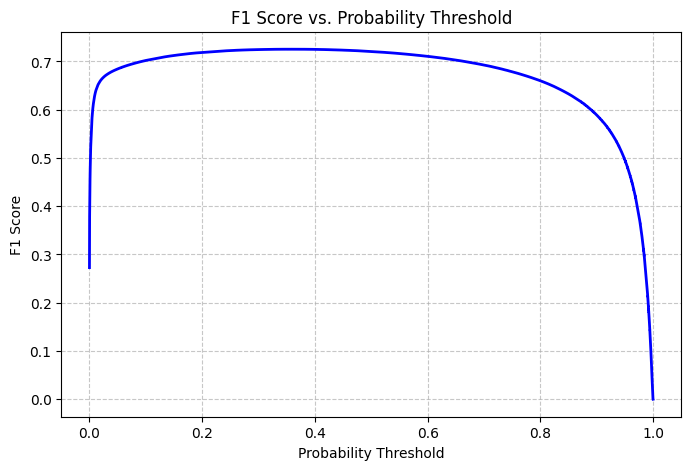

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold
Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
No filter for 4-th fold

======= BEST 3 MODELS =======

=========== Analysing Fold 0 ==============


...

=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Finding Best Threshold ==============
=========== Finding Best Threshold ==============
F1-score: 10.57%


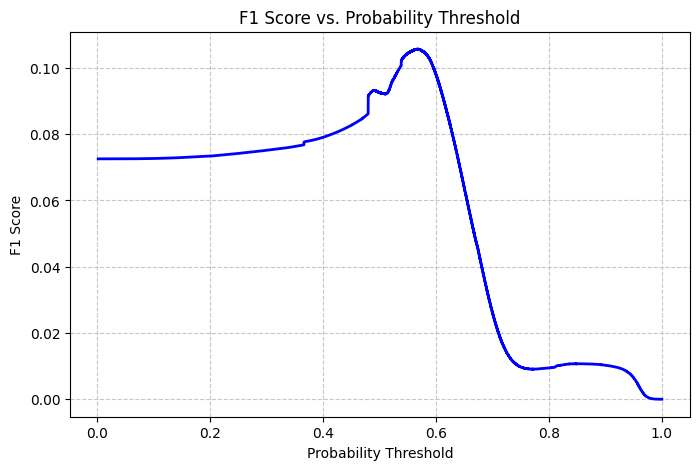

=========== Analysing Sample 0 ==============
=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Sample 0 ==============
=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Sample 0 ==============
=========== Analysing Sample 1 ==============


...

=========== Finding Best Threshold ==============
F1-score: 0.27%
F1-score: 0.27%
Analyzing filter: 19


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.27%
F1-score: 0.27%
Analyzing filter: 20


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 5.04%
F1-score: 5.04%
=========== Clustering Filters ==============


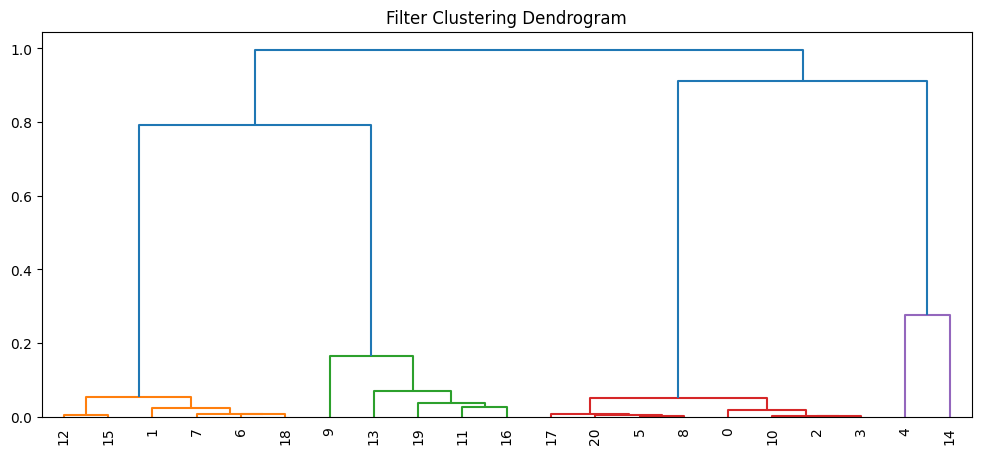

=========== Analysing Fold 1 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.27%
F1-score: 0.27%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.25%
F1-score: 0.25%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 0.13%
F1-score: 0.13%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.11%
F1-score: 0.11%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 2.68%
F1-score: 2.68%
=========== Clustering Filters ==============


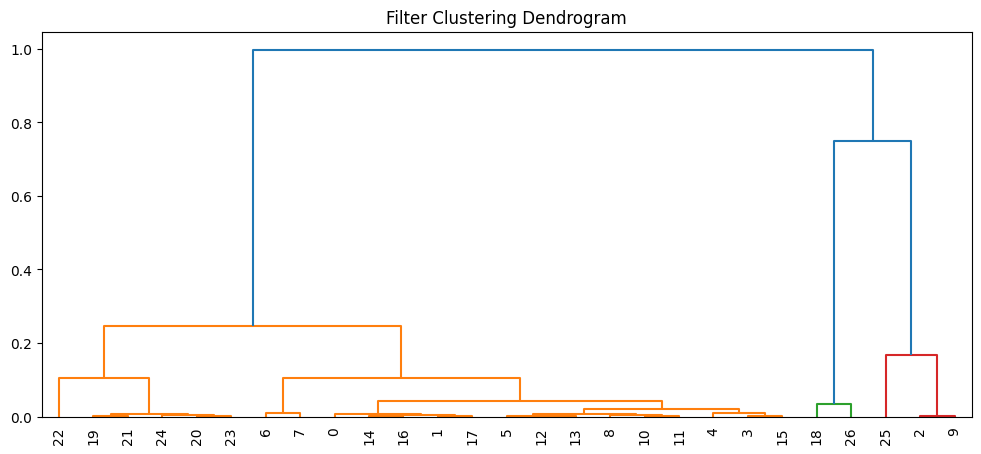

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.03%
F1-score: 0.03%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.03%
F1-score: 0.03%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 0.03%
F1-score: 0.03%
Analyzing filter: 23


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.33%
F1-score: 0.33%
Analyzing filter: 24


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.17%
F1-score: 0.17%
=========== Clustering Filters ==============


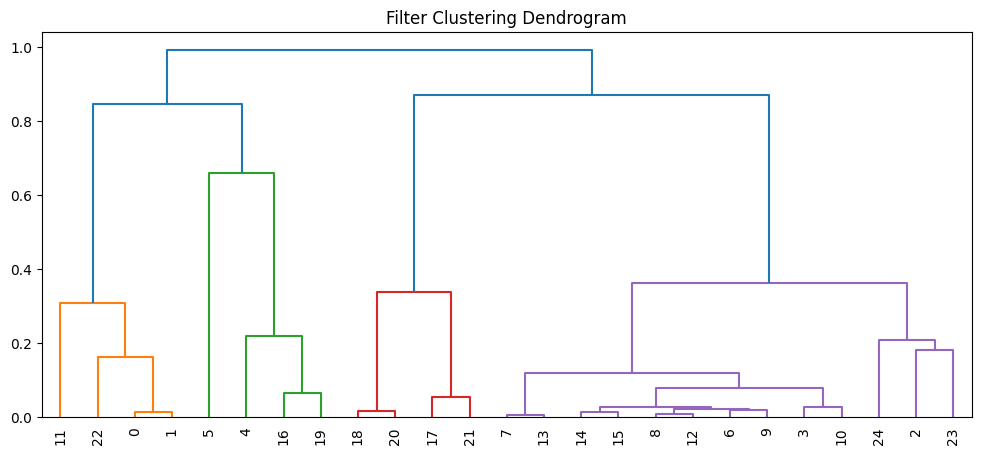

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 29.16%
F1-score: 29.16%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 29.16%
F1-score: 29.16%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 33.30%
F1-score: 33.30%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 29.12%
F1-score: 29.12%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 37.75%
F1-score: 37.75%
=========== Clustering Filters ==============


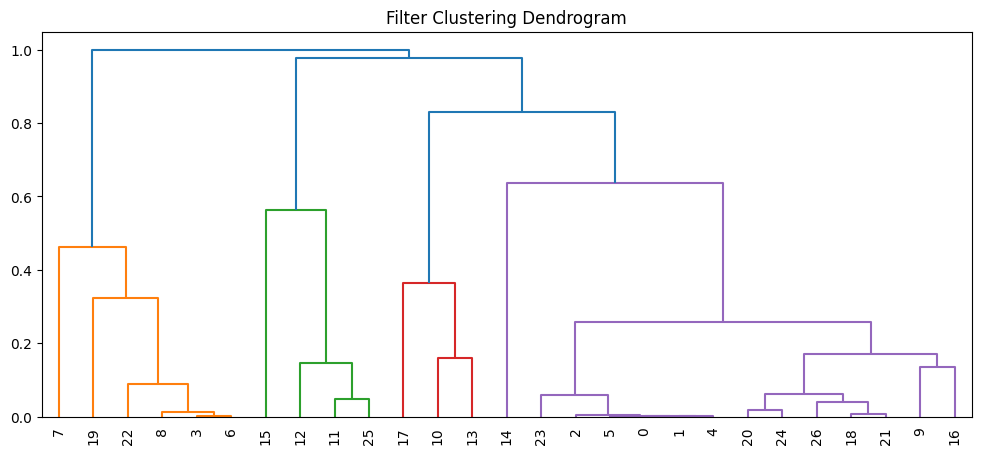

=========== Analysing Fold 4 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.51%
F1-score: 0.51%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.46%
F1-score: 0.46%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 3.66%
F1-score: 3.66%
Analyzing filter: 19
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 1.41%
F1-score: 1.41%
Analyzing filter: 20
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 3.55%
F1-score: 3.55%
=========== Clustering Filters ==============


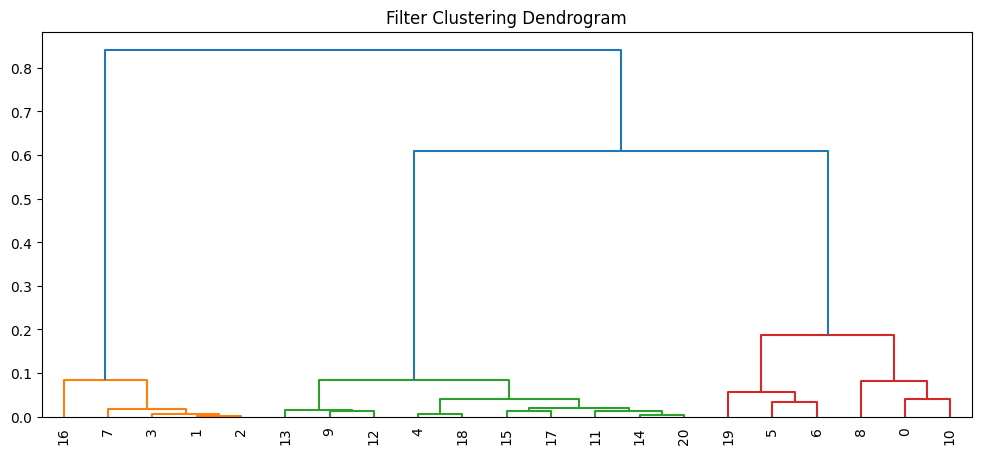

    lopo_fold  cv_fold  model_ID  \
0           0        0         0   
1           0        1         0   
2           0        2         0   
3           0        3         0   
4           0        4         0   
5           1        0         0   
6           1        1         0   
7           1        2         0   
8           1        3         0   
9           1        4         0   
10          2        0         0   
11          2        1         0   
12          2        2         0   
13          2        3         0   
14          2        4         0   
15          3        0         0   
16          3        1         0   
17          3        2         0   
18          3        3         0   
19          3        4         0   
20          4        0         0   
21          4        1         0   
22          4        2         0   
23          4        3         0   
24          4        4         0   
25          5        0         0   
26          5        1      

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 72.53%


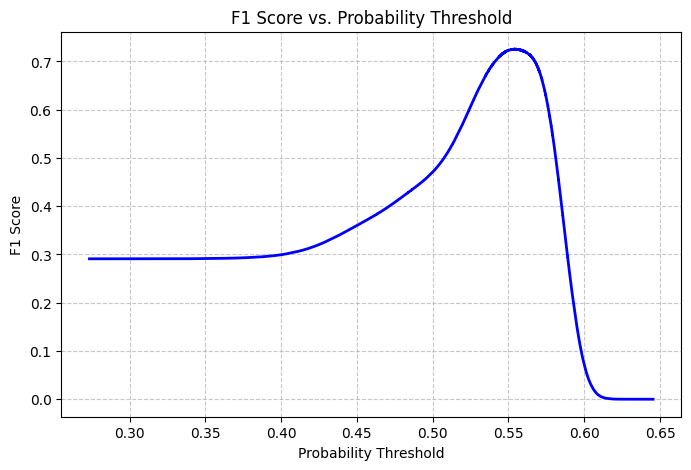

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta


======= BEST FILTERS: LOGISTIC REGRESSION =======

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============
18968804


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 4 ==============
No filter for 4-th fold
=========== Finding Best Threshold ==============
F1-score: 71.13%


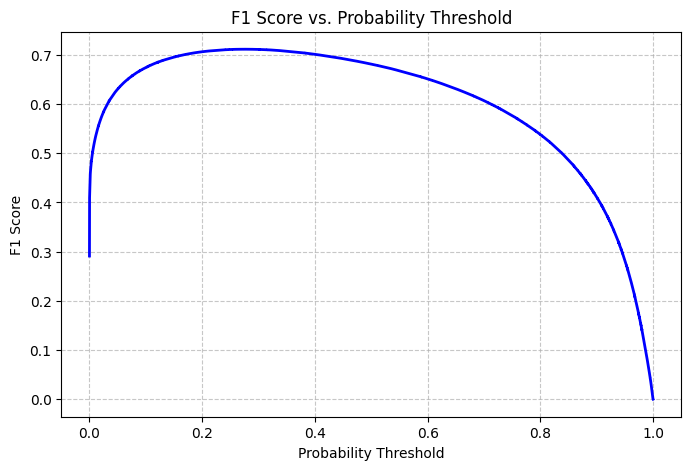

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 4 ==============
No filter for 4-th fold
Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Fold 4 ==============
No filter for 4-th fold
Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============


...

=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Finding Best Threshold ==============
=========== Finding Best Threshold ==============
F1-score: 10.69%


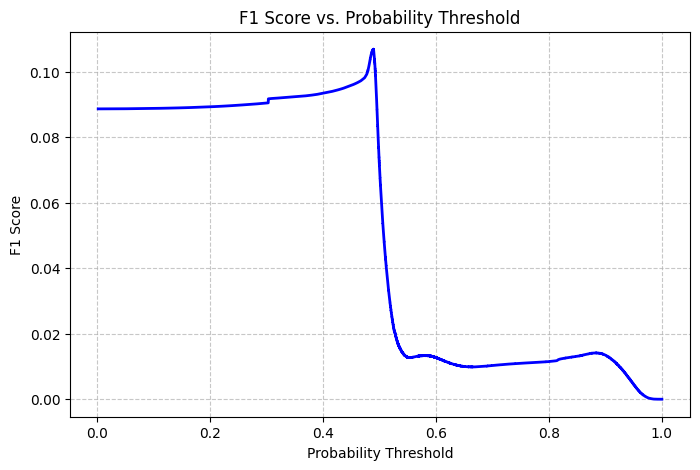

=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


...

F1-score: 34.36%
F1-score: 34.36%
Analyzing filter: 19
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 8.14%
F1-score: 8.14%
Analyzing filter: 20
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 2.50%
F1-score: 2.50%
=========== Clustering Filters ==============


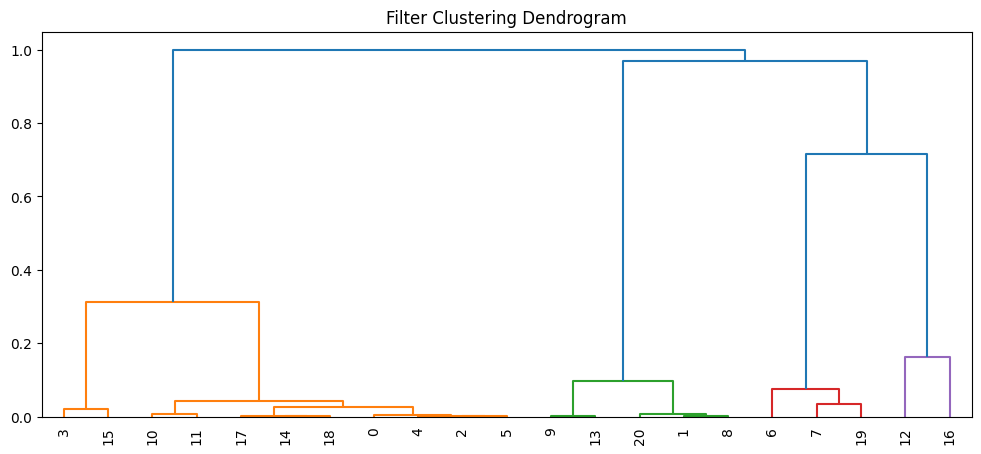

=========== Analysing Fold 1 ==============
Analyzing filter: 0
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.07%
F1-score: 0.07%
Analyzing filter: 1
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.12%
F1-score: 0.12%
Analyzing filter: 2
=========== Finding Best Threshold ==============


...

F1-score: 0.15%
F1-score: 0.15%
Analyzing filter: 25
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.44%
F1-score: 0.44%
Analyzing filter: 26
=========== Finding Best Threshold ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


F1-score: 0.13%
F1-score: 0.13%
=========== Clustering Filters ==============


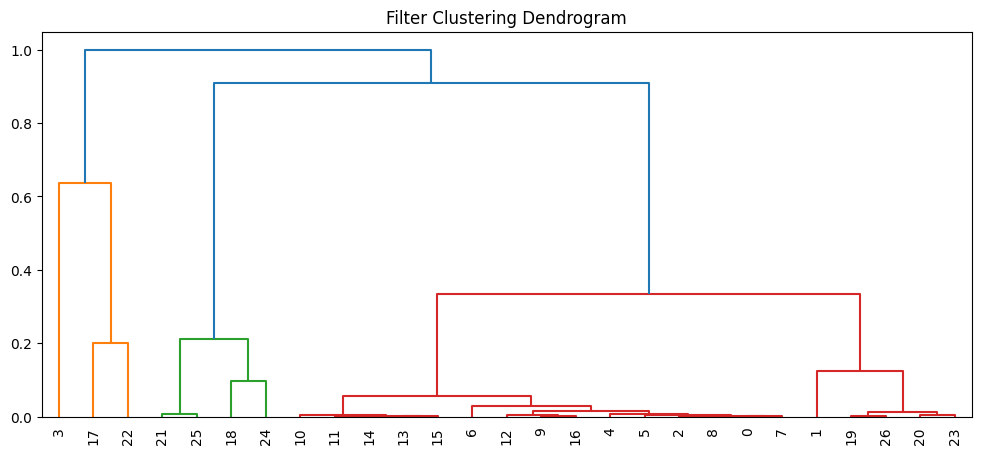

=========== Analysing Fold 2 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 1.32%
F1-score: 1.32%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 3.22%
F1-score: 3.22%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 14.74%
F1-score: 14.74%
Analyzing filter: 23


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 2.33%
F1-score: 2.33%
Analyzing filter: 24


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 0.15%
F1-score: 0.15%
=========== Clustering Filters ==============


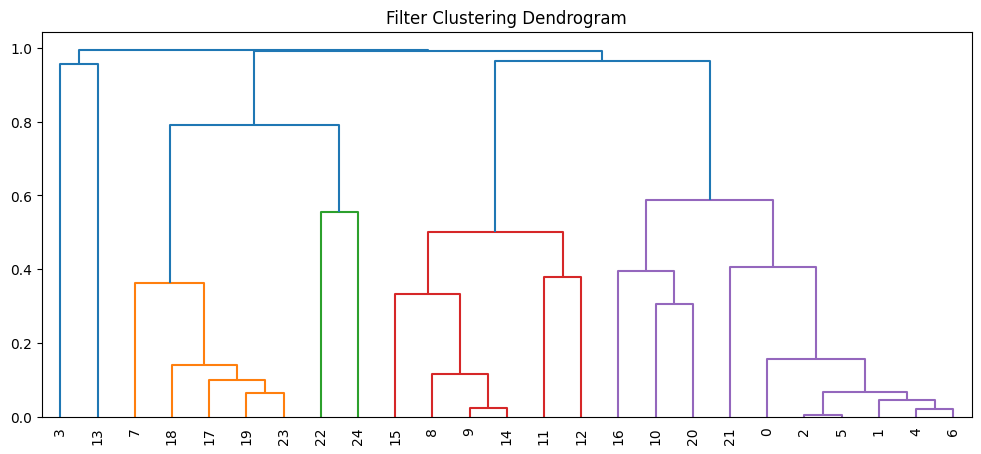

=========== Analysing Fold 3 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 22.52%
F1-score: 22.52%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 21.95%
F1-score: 21.95%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 19.61%
F1-score: 19.61%
Analyzing filter: 19


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 19.35%
F1-score: 19.35%
Analyzing filter: 20


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 20.06%
F1-score: 20.06%
=========== Clustering Filters ==============


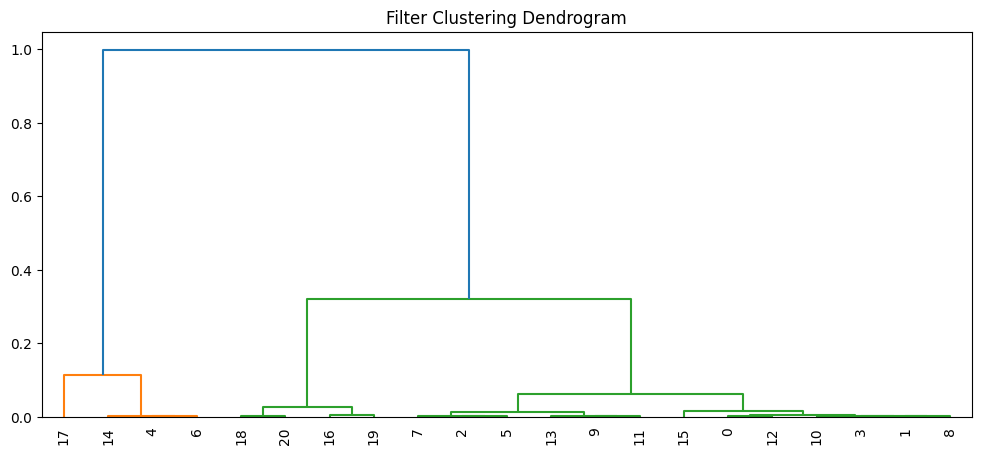

=========== Analysing Fold 4 ==============
Analyzing filter: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.41%
F1-score: 8.41%
Analyzing filter: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 8.12%
F1-score: 8.12%
Analyzing filter: 2


...

=========== Finding Best Threshold ==============
F1-score: 1.05%
F1-score: 1.05%
Analyzing filter: 25


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 6.76%
F1-score: 6.76%
Analyzing filter: 26


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 7.25%
F1-score: 7.25%
=========== Clustering Filters ==============


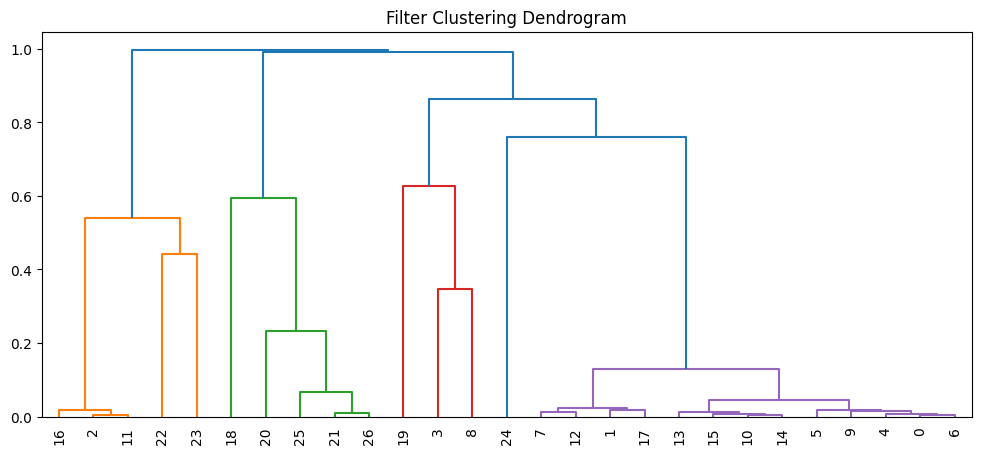

no filters selected. Extract the best one in the backup
    lopo_fold  cv_fold  model_ID  \
0           0        0         0   
1           0        1         0   
2           0        2         0   
3           0        3         0   
4           0        4         0   
5           1        0         0   
6           1        1         0   
7           1        2         0   
8           1        3         0   
9           1        4         0   
10          2        0         0   
11          2        1         0   
12          2        2         0   
13          2        3         0   
14          2        4         0   
15          3        0         0   
16          3        1         0   
17          3        2         0   
18          3        3         0   
19          3        4         0   
20          4        0         0   
21          4        1         0   
22          4        2         0   
23          4        3         0   
24          4        4         0   
25      

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 39.74%


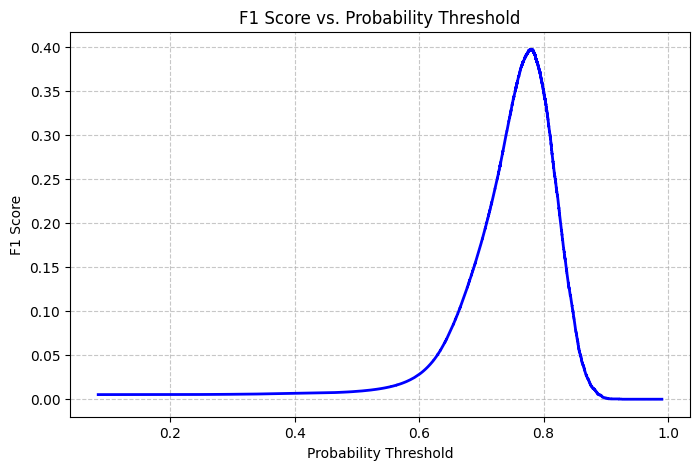

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



======= BEST FILTERS: LOGISTIC REGRESSION =======

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============
25784604


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Finding Best Threshold ==============
F1-score: 39.74%


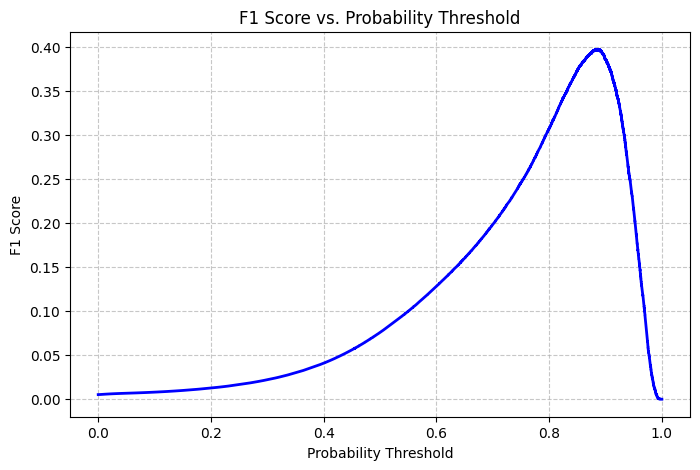

Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Number of CV folds: 5
=========== Analysing Fold 0 ==============
No filter for 0-th fold
=========== Analysing Fold 1 ==============
No filter for 1-th fold
=========== Analysing Fold 2 ==============
No filter for 2-th fold
=========== Analysing Fold 3 ==============
No filter for 3-th fold
=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



======= BEST 3 MODELS =======

=========== Analysing Fold 0 ==============


...

=========== Analysing Fold 3 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_12229/2957815505.py:52: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.wa

=========== Analysing Fold 4 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

=========== Finding Best Threshold ==============
=========== Finding Best Threshold ==============
F1-score: 12.79%


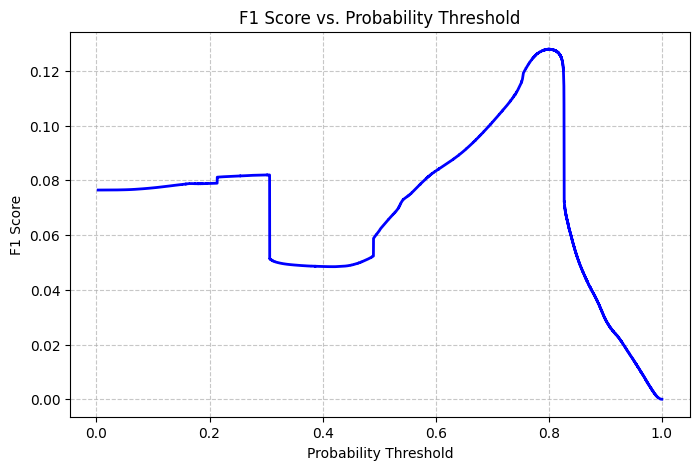

=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 0 ==============


...

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 1 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_12229/2957815505.py:52: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_12229/2957815505.py:52: RuntimeWarning: overflow encountered in exp
  probs = 1 / (1 + np.exp(-logits))
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


=========== Analysing Sample 1 ==============


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
folds_to_test = 10

DIST_THRESHOLD = 0.2
FILTER_SEL_THRESHOLD = 0.6


selected_backups_across_LOPOCV_folds = []
LOPO_df = pd.DataFrame()

entire_pipeline_results = []
best_thr_LOPOCV = []
max_f1_LOPOCV = []

entire_logistic_pipeline_results = []
best_logistic_thr_LOPOCV = []
max_logistic_f1_LOPOCV = []

entire_pipeline_3_filt_results = []
best_3_filt_thr_LOPOCV = []
max_f1_3_filt_LOPOCV = []

LOPOCV_time_computations = []
for LOPOCV_fold_idx in range(folds_to_test):

    start_time = time.time()

    print(f'\n======= Analysing LOPO fold {LOPOCV_fold_idx} =======\n')

    model_cvfolds_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/'

    cross_val_models_list = load_training_models(model_cvfolds_dir)
    train_kfolds, test_pat = LOPOCV_patients_folds[LOPOCV_fold_idx] # for each LOPO fold

    start_filter_time = time.time()

    print(f'\n======= BEST FILTERS: MEAN =======\n')
    # ======= Phase 1: Find Best Filters ======= #

    filter_metadata_df = filters_selection_phase(cross_val_models_list, train_kfolds,
                                                 multiple_donations, ALL_DATASETS,
                                                 LOPOCV_fold_idx, DIST_THRESHOLD, FILTER_SEL_THRESHOLD)

    LOPO_df = pd.concat([LOPO_df, filter_metadata_df], ignore_index=True)
    print(LOPO_df)

    end_filter_time = time.time()

    # ======= Phase 2: Find Best Thr ======= #
    best_avg_thr, max_f1 = best_cells_threshold_phase(
                            filter_metadata_df, train_kfolds,
                            multiple_donations, ALL_DATASETS)

    best_thr_LOPOCV.append(best_avg_thr)
    max_f1_LOPOCV.append(max_f1)

    end_thr_time = time.time()

    # ======= Phase 3: Test ======= #
    LOPOCV_results = test_phase(filter_metadata_df, test_pat, multiple_donations, ALL_DATASETS,
                                max_f1, best_avg_thr, LOPOCV_fold_idx)
    entire_pipeline_results.append(LOPOCV_results)

    end_test_time = time.time()

    print(f'\n======= BEST FILTERS: LOGISTIC REGRESSION =======\n')
    # ======= Phase 2.1: Find Best Logistic Thr ======= #
    best_logistic_thr, max_logistic_f1, clf_list = best_cells_threshold_phase(filter_metadata_df, train_kfolds,
                                                                              multiple_donations, ALL_DATASETS,
                                                                              method='logistic',  max_cells = 15000000,
                                                                              random_state = 0)

    best_logistic_thr_LOPOCV.append(best_logistic_thr)
    max_logistic_f1_LOPOCV.append(max_logistic_f1)

    end_logistic_thr_time = time.time()

    # ======= Phase 3.1: Logistic Test ======= #
    LOPOCV_logistic_results = test_phase(filter_metadata_df, test_pat, multiple_donations, ALL_DATASETS,
               max_logistic_f1, best_logistic_thr, LOPOCV_fold_idx, clf_list = clf_list)
    entire_logistic_pipeline_results.append(LOPOCV_logistic_results)

    end_logistic_test_time = time.time()

    print(f'\n======= BEST 3 MODELS =======\n')
    # ======= Phase 2.2: Find Best 3 models Thr ======= #
    best_3_filt_thr, max_3_filt_f1 = best_3_filt_threshold_phase(cross_val_models_list, train_kfolds,
                                                                 multiple_donations, ALL_DATASETS)

    best_3_filt_thr_LOPOCV.append(best_3_filt_thr)
    max_f1_3_filt_LOPOCV.append(max_3_filt_f1)

    end_3_filt_thr_time = time.time()

    # ======= Phase 3.2: Test ======= #
    LOPOCV_3_filt_results = test_3_filt_phase(test_pat, multiple_donations, ALL_DATASETS,
                                              cross_val_models_list, max_3_filt_f1, best_3_filt_thr, LOPOCV_fold_idx)
    entire_pipeline_3_filt_results.append(LOPOCV_3_filt_results)

    end_3_filt_test_time = time.time()

    LOPOCV_time_computations.append({
        'start_time': start_time,
        'end_filter_time': end_filter_time,
        'end_thr_time': end_thr_time,
        'end_test_time': end_test_time,
        'end_logostic_thr_time': end_logistic_thr_time,
        'end_logostic_test_time': end_logistic_test_time,
        'end_3_filt_thr_time': end_3_filt_thr_time,
        'end_3_filt_test_time': end_3_filt_test_time
    })

summary_df = pd.DataFrame(flatten(entire_pipeline_results))
logistic_summary_df = pd.DataFrame(flatten(entire_logistic_pipeline_results))
best_3_filt_summary_df = pd.DataFrame(flatten(entire_pipeline_3_filt_results))
time_summary_df = pd.DataFrame(LOPOCV_time_computations)

In [ ]:
import numpy as np
import pandas as pd

def add_classification_metrics(df):
    df = df.copy()
    tp = df['TP (Detected_Blasts)']
    fp = df['FP (False_Positives)']
    fn = df['FN (Not_Detected_Blasts)']
    tn = df['TN (Detected_Healthy)']
    total = df['Total_Cells']
    real_blasts = df['Real_Blasts']
    predicted_blasts = df['Predicted_Blasts']

    # Changed 'summary_df' to 'df' here so it works for all passed DataFrames
    df['True_Label'] =  (df['Real_Blasts'] > 0).astype(int)

    df['True_%'] = round(100 * real_blasts / total, 4)
    df['Predicted_%'] = round(100 * predicted_blasts / total, 4)
    #df['TP_%'] = np.where(predicted_blasts > 0, round(100 * tp / predicted_blasts, 4), 0.0)

    # replica la logica originale: se non ci sono blasti reali, forzo a 0
    df['Recall'] = np.where(real_blasts > 0, round(100 * tp / (tp + fn), 4), 0.0)

    # FIX: Assign np.where first, then fillna on the Pandas Series
    df['Precision'] = np.where(real_blasts > 0, round(100 * tp / (tp + fp).replace(0, np.nan), 4), 0.0)
    df['Precision'] = df['Precision'].fillna(0.0)

    denom = df['Precision'] + df['Recall']
    df['F1_Score'] = np.where(denom > 0, round(2 * df['Precision'] * df['Recall'] / denom, 4), 0.0)
    df['Accuracy'] = round(100 * (tp + tn) / total, 4)

    return df

In [ ]:
summary_df = add_classification_metrics(pd.DataFrame(flatten(entire_pipeline_results)))
logistic_summary_df = add_classification_metrics(pd.DataFrame(flatten(entire_logistic_pipeline_results)))
best_3_filt_summary_df = add_classification_metrics(pd.DataFrame(flatten(entire_pipeline_3_filt_results)))

time_summary_df = pd.DataFrame(LOPOCV_time_computations)


In [ ]:
summary_df

,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,Predicted_Blasts,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1,True_Label,True_%,Predicted_%,Recall,Precision,F1_Score,Accuracy
0,Pat_1_1,1,864000,757,10381,733,24,9648,853595,0.747297,1,0.0876,1.2015,96.8296,7.0610,13.1622,98.8806
1,Pat_1_2,1,1947518,0,109,0,0,109,1947409,0.747297,0,0.0000,0.0056,0.0000,0.0000,0.0000,99.9944
2,Pat_2_1,2,778750,308059,97720,21,308038,97699,372992,0.314266,1,39.5581,12.5483,0.0068,0.0215,0.0103,47.8989
3,Pat_2_2,2,5510750,830101,822798,22234,807867,800564,3880085,0.314266,1,15.0633,14.9308,2.6785,2.7022,2.6903,70.8128
4,Pat_3_1,3,208000,72,105546,72,0,105474,102454,0.362014,1,0.0346,50.7433,100.0000,0.0682,0.1363,49.2913
5,Pat_3_2,3,2912500,0,675797,0,0,675797,2236703,0.362014,0,0.0000,23.2033,0.0000,0.0000,0.0000,76.7967
6,Pat_4_1,4,160500,3096,43593,3096,0,40497,116907,0.604967,1,1.9290,27.1607,100.0000,7.1021,13.2623,74.7682
7,Pat_4_2,4,3591480,1449,260399,1449,0,258950,3331081,0.604967,1,0.0403,7.2505,100.0000,0.5565,1.1068,92.7899
8,Pat_4_3,4,3107000,0,8873,0,0,8873,3098127,0.604967,0,0.0000,0.2856,0.0000,0.0000,0.0000,99.7144
9,Pat_5_1,5,637409,9147,1741,797,8350,944,627318,0.635592,1,1.4350,0.2731,8.7132,45.7783,14.6399,98.5419


In [ ]:
logistic_summary_df

,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,Predicted_Blasts,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1,True_Label,True_%,Predicted_%,Recall,Precision,F1_Score,Accuracy
0,Pat_1_1,1,864000,757,10381,733,24,9648,853595,0.747297,1,0.0876,1.2015,96.8296,7.0610,13.1622,98.8806
1,Pat_1_2,1,1947518,0,109,0,0,109,1947409,0.747297,0,0.0000,0.0056,0.0000,0.0000,0.0000,99.9944
2,Pat_2_1,2,778750,308059,97720,21,308038,97699,372992,0.314266,1,39.5581,12.5483,0.0068,0.0215,0.0103,47.8989
3,Pat_2_2,2,5510750,830101,822798,22234,807867,800564,3880085,0.314266,1,15.0633,14.9308,2.6785,2.7022,2.6903,70.8128
4,Pat_3_1,3,208000,72,171750,72,0,171678,36250,0.197737,1,0.0346,82.5721,100.0000,0.0419,0.0838,17.4625
5,Pat_3_2,3,2912500,0,1981604,0,0,1981604,930896,0.197737,0,0.0000,68.0379,0.0000,0.0000,0.0000,31.9621
6,Pat_4_1,4,160500,3096,83548,3096,0,80452,76952,0.348105,1,1.9290,52.0548,100.0000,3.7057,7.1466,49.8741
7,Pat_4_2,4,3591480,1449,514800,1449,0,513351,3076680,0.348105,1,0.0403,14.3339,100.0000,0.2815,0.5614,85.7064
8,Pat_4_3,4,3107000,0,267521,0,0,267521,2839479,0.348105,0,0.0000,8.6103,0.0000,0.0000,0.0000,91.3897
9,Pat_5_1,5,637409,9147,1741,797,8350,944,627318,0.635592,1,1.4350,0.2731,8.7132,45.7783,14.6399,98.5419


In [ ]:
best_3_filt_summary_df

,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,Predicted_Blasts,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1,True_Label,True_%,Predicted_%,Recall,Precision,F1_Score,Accuracy
0,Pat_1_1,1,864000,757,862044,757,0,861287,1956,0.086244,1,0.0876,99.7736,100.0000,0.0878,0.1754,0.3140
1,Pat_1_2,1,1947518,0,1667723,0,0,1667723,279795,0.086244,0,0.0000,85.6333,0.0000,0.0000,0.0000,14.3667
2,Pat_2_1,2,778750,308059,0,0,308059,0,470691,0.020526,1,39.5581,0.0000,0.0000,0.0000,0.0000,60.4419
3,Pat_2_2,2,5510750,830101,0,0,830101,0,4680649,0.020526,1,15.0633,0.0000,0.0000,0.0000,0.0000,84.9367
4,Pat_3_1,3,208000,72,113471,72,0,113399,94529,0.136211,1,0.0346,54.5534,100.0000,0.0635,0.1269,45.4812
5,Pat_3_2,3,2912500,0,767416,0,0,767416,2145084,0.136211,0,0.0000,26.3490,0.0000,0.0000,0.0000,73.6510
6,Pat_4_1,4,160500,3096,142785,3096,0,139689,17715,0.124001,1,1.9290,88.9626,100.0000,2.1683,4.2446,12.9664
7,Pat_4_2,4,3591480,1449,1590445,1449,0,1588996,2001035,0.124001,1,0.0403,44.2838,100.0000,0.0911,0.1820,55.7565
8,Pat_4_3,4,3107000,0,508125,0,0,508125,2598875,0.124001,0,0.0000,16.3542,0.0000,0.0000,0.0000,83.6458
9,Pat_5_1,5,637409,9147,279189,9141,6,270048,358214,0.113873,1,1.4350,43.8006,99.9344,3.2741,6.3405,57.6325


In [ ]:
time_summary_df

,start_time,end_filter_time,end_thr_time,end_test_time,end_logostic_thr_time,end_logostic_test_time,end_3_filt_thr_time,end_3_filt_test_time
0,1.789910e+09,1.789910e+09,1.789910e+09,1.789910e+09,1.789910e+09,1.789910e+09,1.789910e+09,1.789910e+09
1,1.789910e+09,1.789910e+09,1.789910e+09,1.789910e+09,1.789911e+09,1.789911e+09,1.789911e+09,1.789911e+09
2,1.789911e+09,1.789911e+09,1.789911e+09,1.789911e+09,1.789912e+09,1.789912e+09,1.789912e+09,1.789912e+09
3,1.789912e+09,1.789912e+09,1.789912e+09,1.789912e+09,1.789913e+09,1.789913e+09,1.789913e+09,1.789913e+09
4,1.789913e+09,1.789914e+09,1.789914e+09,1.789914e+09,1.789914e+09,1.789914e+09,1.789914e+09,1.789914e+09
5,1.789914e+09,1.789914e+09,1.789914e+09,1.789914e+09,1.789915e+09,1.789915e+09,1.789915e+09,1.789915e+09
6,1.789915e+09,1.789915e+09,1.789915e+09,1.789915e+09,1.789915e+09,1.789915e+09,1.789915e+09,1.789915e+09
7,1.789915e+09,1.789916e+09,1.789916e+09,1.789916e+09,1.789916e+09,1.789916e+09,1.789916e+09,1.789916e+09
8,1.789916e+09,1.789916e+09,1.789916e+09,1.789916e+09,1.789917e+09,1.789917e+09,1.789917e+09,1.789917e+09
9,1.789917e+09,1.789917e+09,1.789917e+09,1.789917e+09,1.789917e+09,1.789917e+09,1.789917e+09,1.789917e+09


In [ ]:
filters_plot_exp = 'filter_resp_plots'
config_save_dir = f'{cellcnn_path}/experiments/experiment_{filters_plot_exp}/final_run/'
os.makedirs(config_save_dir, exist_ok = True)
plotdir = os.path.join(config_save_dir, 'plots')
os.makedirs(plotdir, exist_ok = True)

save = False
if save:


    print(plotdir)
    time_summary_df.to_csv(os.path.join(plotdir, 'time_summary.csv'), index = False)
    summary_df.to_csv(os.path.join(plotdir, 'summary.csv'), index = False)
    logistic_summary_df.to_csv(os.path.join(plotdir, 'logistic_summary.csv'), index = False)
    best_3_filt_summary_df.to_csv(os.path.join(plotdir, 'best_3_filt_summary.csv'), index = False)

/content/drive/MyDrive/0.Master_Thesis/CellCNN//experiments/experiment_filter_resp_plots/final_run/plots


## Analyse results


In [ ]:
import seaborn as sns
class PipelineResults:
    def __init__(self, summary_df):

        self.summary_df = summary_df

    def _subset(self, condition=None):
        """ Returns the requested subset"""

        if condition is None:
            return self.summary_df
        elif condition == 'blast':
            return self.summary_df[self.summary_df['True_Label'] == 1]
        elif condition == 'healthy':
            return self.summary_df[self.summary_df['True_Label'] == 0]
        else:
            raise ValueError("condition must be None, 'blast' o 'healthy'")


    def show_metrics_across_filters_f1(self, condition='blast'):

        df = self._subset(condition)

        mean_filter_F1_Score = df['Filter_F1'].to_numpy()
        true_pos_perc = df['Precision'].to_numpy()
        samples_ID = df['Sample_ID'].to_numpy()
        pred_perc = df['Predicted_%'].to_numpy()
        true_perc = df['True_%'].to_numpy()
        pos_perc_dist = 1-abs(pred_perc - true_pos_perc)
        true_perc_dist = 1-abs(pred_perc - true_perc)

        to_analyse = [true_pos_perc, pos_perc_dist, true_perc_dist]
        y_labels = ['Precision',
                    'Distance between Predicted % and True Positive %',
                    'Distance between Predicted % and True Cancer Cells %']

        fig, ax = plt.subplots(1,len(to_analyse), figsize = (20,7))

        for e, element in enumerate(to_analyse):
          ax[e].scatter(mean_filter_F1_Score, element)

          z = np.polyfit(mean_filter_F1_Score, element, 1)
          p = np.poly1d(z)
          ax[e].plot(mean_filter_F1_Score, p(mean_filter_F1_Score), "r--")

          for i, txt in enumerate(samples_ID):
            ax[e].annotate(txt, (mean_filter_F1_Score[i], element[i]))

          ax[e].set_ylabel(y_labels[e])
          ax[e].set_xlabel('F1')


        display(fig)
        plt.close(fig)


    def show_metrics_correlation_matrix(self, cols_to_correlate=None, condition='blast'):
        df = self._subset(condition)

        if cols_to_correlate is None:
            cols_to_correlate = ['Filter_F1', 'Recall', 'Precision', 'F1_Score', 'Predicted_%', 'True_%']

        corr_matrix = df[cols_to_correlate].corr(method='pearson')

        fig = plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix,
                    annot=True,       # Mostra i numeri dentro i quadrati
                    cmap='coolwarm',  # Colori: rosso (positivo), blu (negativo)
                    fmt=".2f",        # Arrotonda a 2 decimali
                    vmin=-1, vmax=1,  # Fissa la scala da -1 a 1
                    linewidths=0.5)

        title_suffix = {'blast': '(Unhealthy Patients Only)',
                         'healthy': '(Healthy Patients Only)',
                         None: '(All Patients)'}[condition]

        plt.title(f"Metrics Correlation Matrix {title_suffix}",
                   fontsize=15, fontweight='bold', pad=15)

        plt.tight_layout()
        plt.show()
        display(fig)
        plt.close(fig)


    def show_corr(self, x='Filter_F1', y='Recall', condition='blast'):
        df = self._subset(condition)

        fig = plt.figure(figsize=(9, 6))
        sns.regplot(data=df, x=x, y=y,
                    scatter_kws={'s': 80, 'alpha': 0.7, 'edgecolor': 'white', 'color': '#2874A6'},
                    line_kws={'color': '#E74C3C', 'linewidth': 2})

        plt.title(f'Linear Correlation: {x} vs {y}', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel(x, fontsize=12)
        plt.ylabel(y, fontsize=12)
        plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
        sns.despine()

        display(fig)
        plt.close(fig)

In [ ]:
filters_plot_exp = 'filter_resp_plots'
config_save_dir = f'{cellcnn_path}/experiments/experiment_{filters_plot_exp}/final_run/'
os.makedirs(config_save_dir, exist_ok = True)
plotdir = os.path.join(config_save_dir, 'plots')
os.makedirs(plotdir, exist_ok = True)

summary_df = pd.read_csv(os.path.join(plotdir, 'summary.csv'))
logistic_summary_df = pd.read_csv(os.path.join(plotdir, 'logistic_summary.csv'))
best_3_filt_summary_df = pd.read_csv(os.path.join(plotdir, 'best_3_filt_summary.csv'))
time_summary_df = pd.read_csv(os.path.join(plotdir, 'time_summary.csv'))

In [ ]:
partial_df = summary_df.copy()
partial_df = partial_df[ ['Filter_F1', 'Recall', 'Precision', 'F1_Score', 'Predicted_%', 'True_%']]

grouped_partial_df = partial_df.groupby('Filter_F1').mean().reset_index()
#print(partial_df)
grouped_partial_df

,Filter_F1,Recall,Precision,F1_Score,Predicted_%,True_%
0,28.991145,6.617400,0.019600,0.038850,35.314250,0.257950
1,31.426567,1.342650,1.361850,1.350300,13.739550,27.310700
2,36.201361,50.000000,0.034100,0.068150,36.973300,0.017300
3,39.737764,42.410000,25.350800,31.733000,0.342100,0.075200
4,60.496664,66.666667,2.552867,4.789700,11.565600,0.656433
5,62.071019,43.378733,7.221267,12.381233,1.173367,0.174033
6,63.559191,19.114300,48.461650,26.035000,0.138800,0.721400
7,72.526998,99.985450,28.797100,38.782550,29.383550,14.035800
8,72.534059,60.187633,1.906500,3.633500,1.843033,0.057300
9,74.729653,48.414800,3.530500,6.581100,0.603550,0.043800


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
class PipelineResults:
    def __init__(self, summary_df):
        self.summary_df = summary_df

    def _subset(self, condition=None):
        """ Returns the requested subset"""
        if condition is None:
            return self.summary_df
        elif condition == 'blast':
            return self.summary_df[self.summary_df['True_Label'] == 1]
        elif condition == 'healthy':
            return self.summary_df[self.summary_df['True_Label'] == 0]
        else:
            raise ValueError("condition must be None, 'blast' o 'healthy'")

    def show_metrics_across_filters_f1(self, condition='blast'):

        df = self._subset(condition).copy()

        df['pos_perc_dist'] = 1 - abs(df['Predicted_%'] - df['Precision'])
        df['true_perc_dist'] = 1 - abs(df['Predicted_%'] - df['True_%'])

        df_grouped = df.groupby('Filter_F1')[['Precision', 'pos_perc_dist', 'true_perc_dist']].mean().reset_index()


        cols_to_plot = ['Precision', 'pos_perc_dist', 'true_perc_dist']
        y_labels = [
            'Precision',
            'Distance between Predicted % and True Positive %',
            'Distance between Predicted % and True Cancer Cells %'
        ]

        fig, ax = plt.subplots(1, len(cols_to_plot), figsize=(20, 7))

        for e, col in enumerate(cols_to_plot):

            raw_x = df['Filter_F1'].to_numpy()
            raw_y = df[col].to_numpy()
            samples_ID = df['Sample_ID'].to_numpy()

            ax[e].scatter(raw_x, raw_y, alpha=0.6, color='#3498DB', label='Single Samples')

            for i, txt in enumerate(samples_ID):
                ax[e].annotate(txt, (raw_x[i], raw_y[i]), fontsize=8, alpha=0.7)

            grouped_x = df_grouped['Filter_F1'].to_numpy()
            grouped_y = df_grouped[col].to_numpy()

            z = np.polyfit(grouped_x, grouped_y, 1)
            p = np.poly1d(z)

            ax[e].plot(grouped_x, p(grouped_x), "r--", linewidth=2, label='Trend (Mean)')

            ax[e].set_ylabel(y_labels[e])
            ax[e].set_xlabel('Filter_F1')
            ax[e].legend()

        plt.tight_layout()
        display(fig)
        plt.close(fig)


    def show_metrics_correlation_matrix(self, cols_to_correlate=None, condition='blast'):
        df = self._subset(condition)

        if cols_to_correlate is None:
            cols_to_correlate = ['Filter_F1', 'Recall', 'Precision', 'F1_Score', 'Predicted_%', 'True_%']

        corr_matrix = df[cols_to_correlate].corr(method='pearson')

        fig = plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix,
                    annot=True,       # Mostra i numeri dentro i quadrati
                    cmap='coolwarm',  # Colori: rosso (positivo), blu (negativo)
                    fmt=".2f",        # Arrotonda a 2 decimali
                    vmin=-1, vmax=1,  # Fissa la scala da -1 a 1
                    linewidths=0.5)

        title_suffix = {'blast': '(Unhealthy Patients Only)',
                         'healthy': '(Healthy Patients Only)',
                         None: '(All Patients)'}[condition]

        plt.title(f"Metrics Correlation Matrix {title_suffix}",
                   fontsize=15, fontweight='bold', pad=15)

        plt.tight_layout()
        plt.show()
        display(fig)
        plt.close(fig)


    def show_corr(self, x='Filter_F1', y='Recall', condition='blast', axis = None):
        df = self._subset(condition).copy()

        # Anche qui separiamo!
        df_grouped = df.groupby(x)[y].mean().reset_index()

        if axis is not None:
            ax = axis
        else:
            fig, ax = plt.subplots(figsize=(9, 6))

        rho, p_value = stats.spearmanr(df_grouped[x], df_grouped[y])

        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        stats_text = f"Spearman Rho: {rho:.2f}\np-value: {p_value:.1e} ({significance})"

        sns.scatterplot(data=df, x=x, y=y,
                        s=80, alpha=0.4, edgecolor='white', color='#2874A6', label='Single Samples', ax = ax)

        sns.regplot(data=df_grouped, x=x, y=y,
                    scatter=False,
                    line_kws={'color': '#E74C3C', 'linewidth': 2}, label='Filter Trend (Mean)', ax = ax)

        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

        ax.set_title(f'Validation vs Test: {x} vs {y}', fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel(f"{x} (Validation Set)", fontsize=12)
        ax.set_ylabel(f"{y} (Test Set)", fontsize=12)
        ax.legend(loc='lower right')
        ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
        sns.despine(ax=ax)

        if axis is None:
            display(fig)
            plt.close(fig)

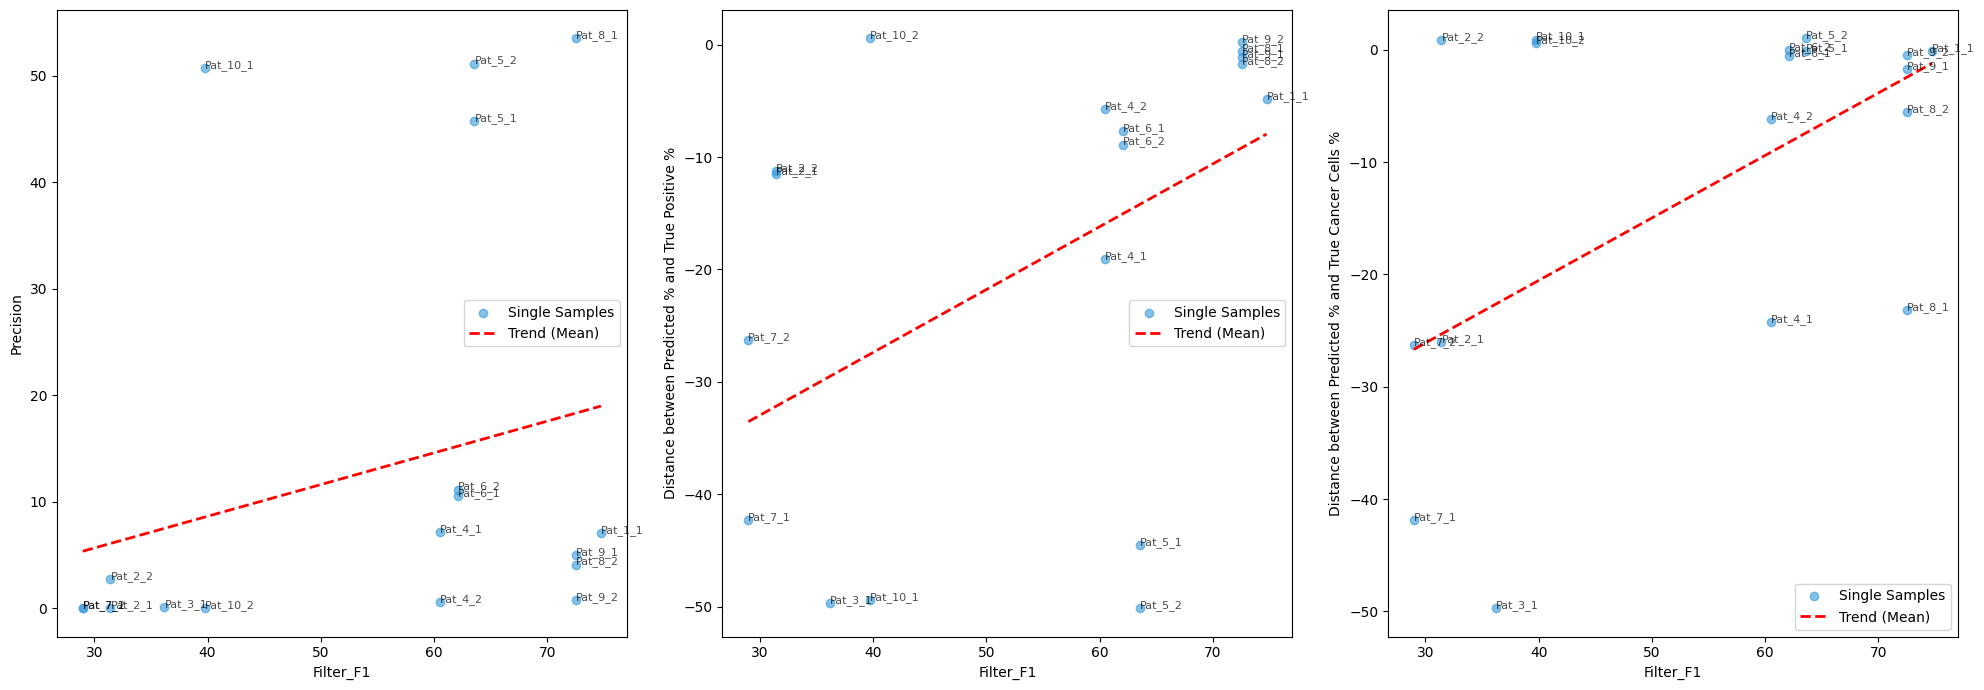

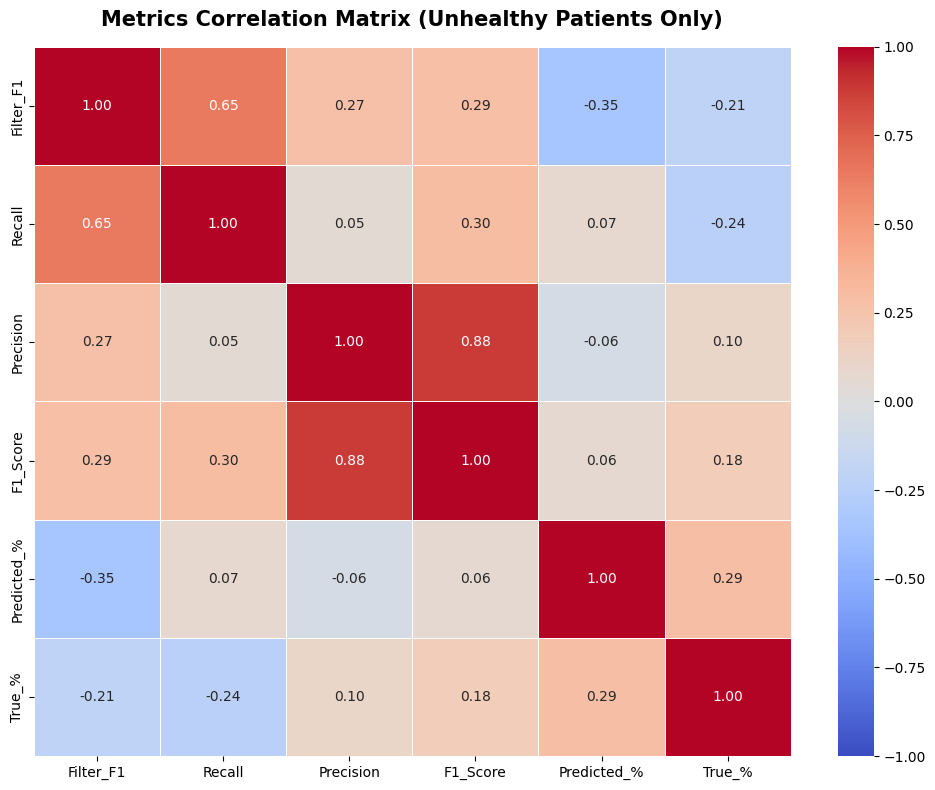

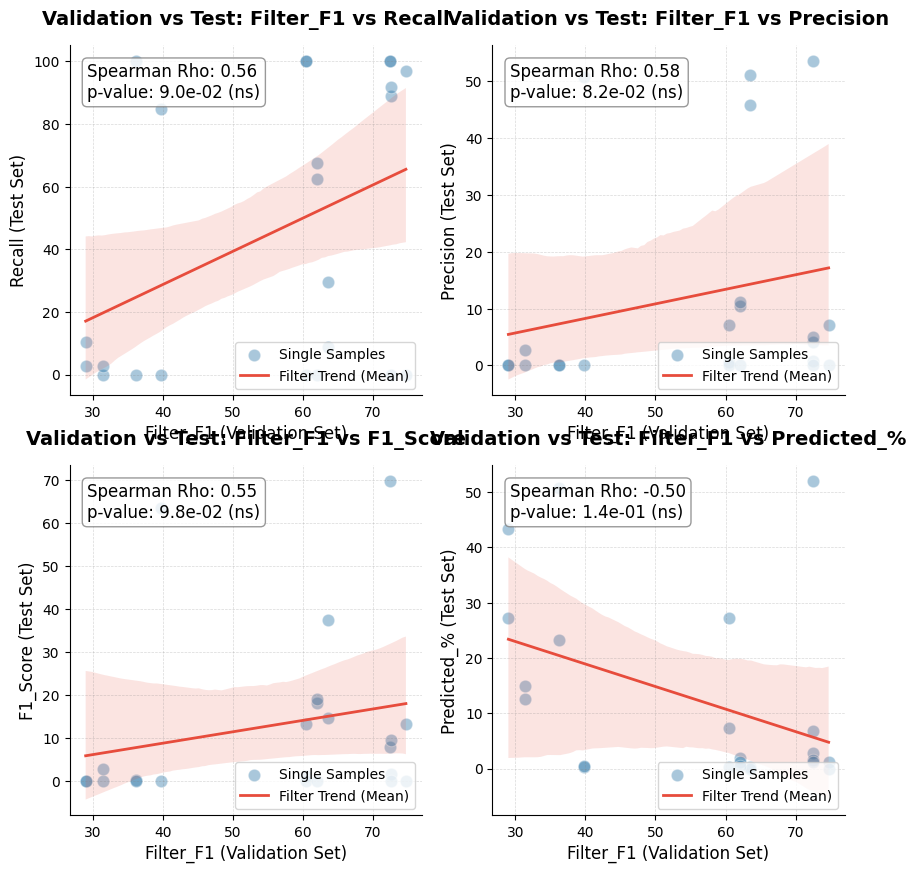

TypeError: cannot unpack non-iterable Figure object

In [ ]:
results = PipelineResults(summary_df)

results.show_metrics_across_filters_f1(condition='blast')          # ha senso solo sui malati
results.show_metrics_correlation_matrix(condition='blast')         # correlazioni su Recall/TP_% -> malati
#results.show_metrics_correlation_matrix(condition='healthy')       # correlazioni su Precision/FP -> anche sani

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for m, metric in enumerate(['Recall', 'Precision', 'F1_Score', 'Predicted_%']):

    results.show_corr(x='Filter_F1', y=metric, condition=None, axis = axs[m//2, m%2])

display(fig)
plt.close(fig)

#results.show_corr(x='Filter_F1', y='Precision', condition=None)


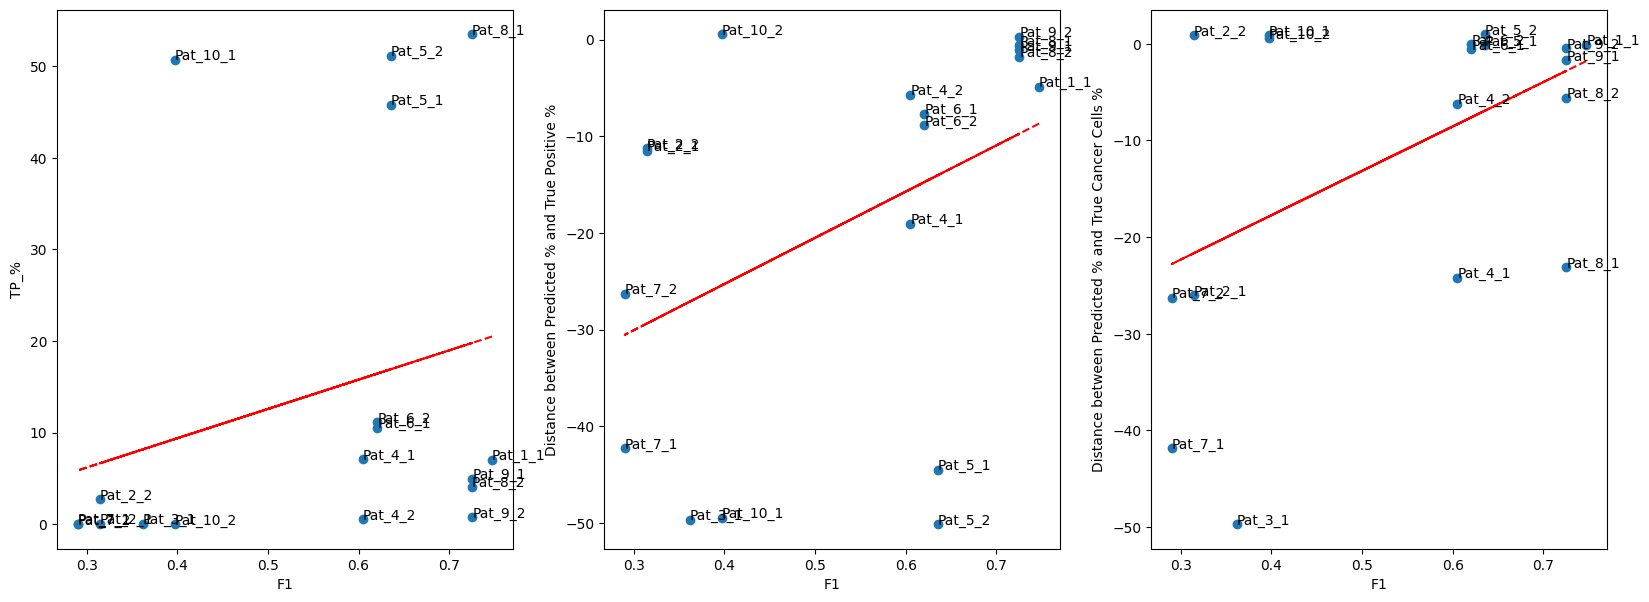

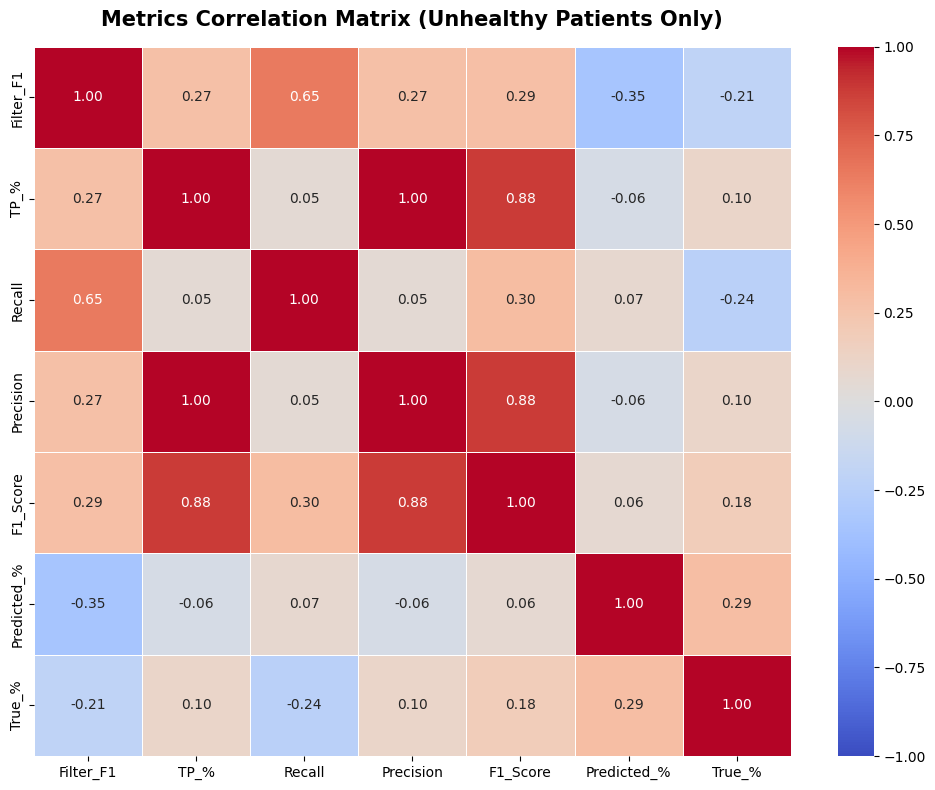

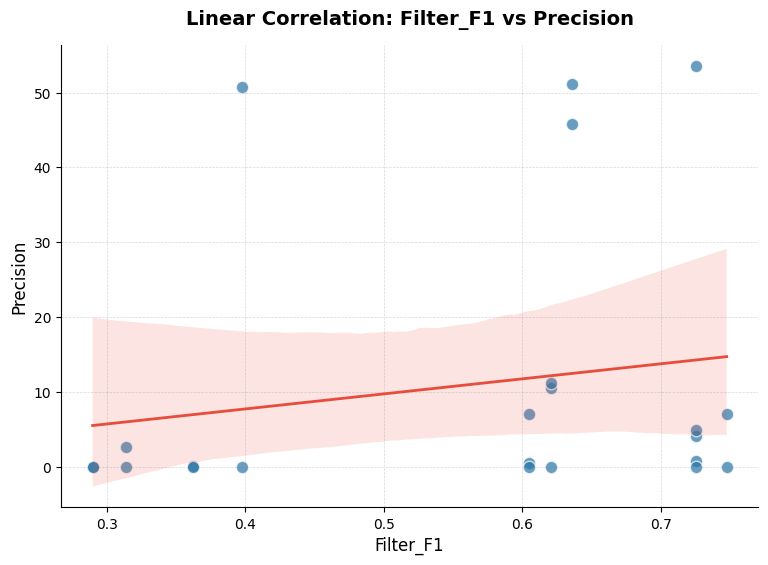

In [ ]:
results = PipelineResults(summary_df)

results.show_metrics_across_filters_f1(condition='blast')          # ha senso solo sui malati
results.show_metrics_correlation_matrix(condition='blast')         # correlazioni su Recall/TP_% -> malati
#results.show_metrics_correlation_matrix(condition='healthy')       # correlazioni su Precision/FP -> anche sani
results.show_corr(x='Filter_F1', y='Precision', condition=None)

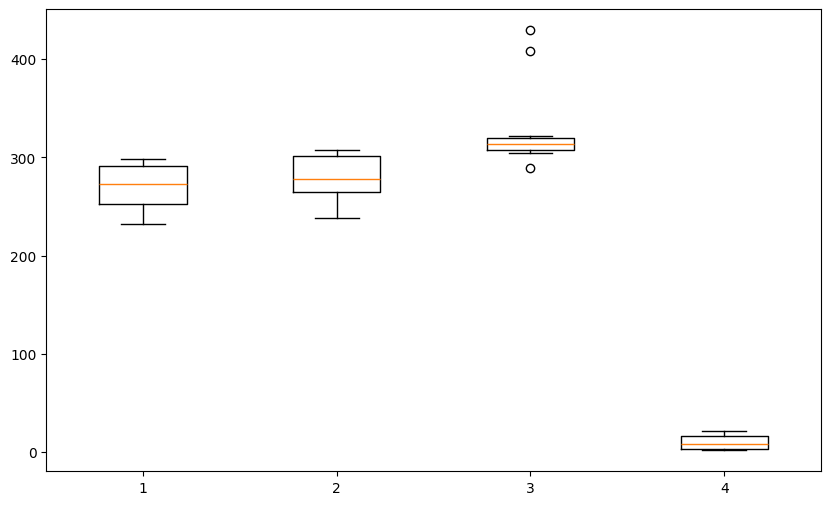

In [ ]:
def analyse_working_time(time_df):
    filter_time = time_df['end_filter_time'] - time_df['start_time']
    working_time = time_df['end_test_time'] - time_df['end_filter_time'] + filter_time
    logistic_working_time = time_df['end_logostic_test_time'] - time_df['end_logostic_thr_time'] + filter_time
    best_3_filt_working_time = time_df['end_3_filt_test_time'] - time_df['end_3_filt_thr_time']

    fig = plt.figure(figsize=(10, 6))
    plt.boxplot([filter_time, working_time, logistic_working_time, best_3_filt_working_time])
    display(fig)
    plt.close(fig)

analyse_working_time(time_summary_df)

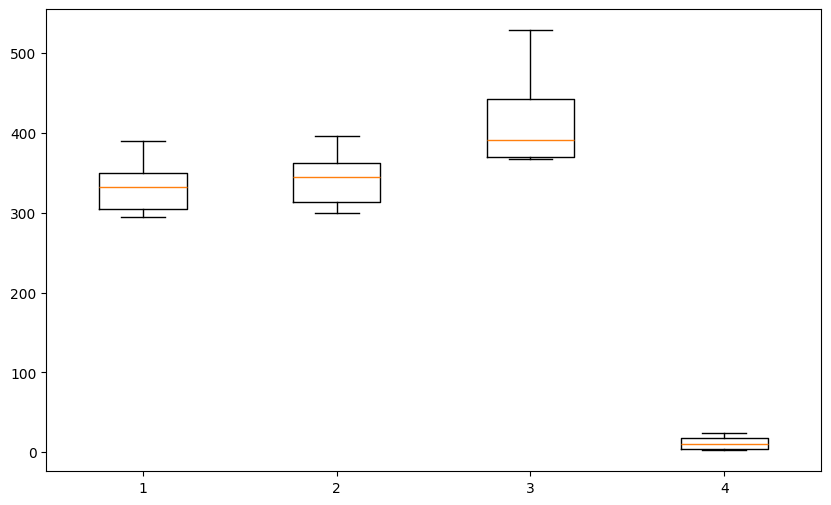

In [ ]:
def analyse_working_time(time_df):
    filter_time = time_df['end_filter_time'] - time_df['start_time']
    working_time = time_df['end_test_time'] - time_df['end_filter_time'] + filter_time
    logistic_working_time = time_df['end_logostic_test_time'] - time_df['end_logostic_thr_time'] + filter_time
    best_3_filt_working_time = time_df['end_3_filt_test_time'] - time_df['end_3_filt_thr_time']

    fig = plt.figure(figsize=(10, 6))
    plt.boxplot([filter_time, working_time, logistic_working_time, best_3_filt_working_time])
    display(fig)
    plt.close(fig)

analyse_working_time(time_summary_df)

In [ ]:
print_var_memory()

Variable                  Type                          Memory
-----------------------------------------------------------------
ALL_DATASETS              list                         1.52 GB
-----------------------------------------------------------------
TOTAL                                                  1.52 GB


['ALL_DATASETS']

In [ ]:
summary_df

,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,True_%,Predicted_Blasts,TP_%,Predicted_%,Recall,Precision,F1_Score,Accuracy,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1,True_Label
0,Pat_1_1,1,864000,757,0.0876,10381,7.061,1.2015,96.8296,7.061,13.1622,98.8806,733,24,9648,853595,0.747297,1
1,Pat_1_2,1,1947518,0,0.0000,109,0.000,0.0056,0.0000,0.000,0.0000,99.9944,0,0,109,1947409,0.747297,0


In [ ]:
logistic_summary_df

,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,True_%,Predicted_Blasts,TP_%,Predicted_%,Recall,Precision,F1_Score,Accuracy,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1,True_Label
0,Pat_1_1,1,864000,757,0.0876,10381,7.061,1.2015,96.8296,7.061,13.1622,98.8806,733,24,9648,853595,0.747297,1
1,Pat_1_2,1,1947518,0,0.0000,109,0.000,0.0056,0.0000,0.000,0.0000,99.9944,0,0,109,1947409,0.747297,0


In [ ]:
best_3_filt_summary_df

,Sample_ID,LOPO_Fold,Total_Cells,Real_Blasts,True_%,Predicted_Blasts,TP_%,Predicted_%,Recall,Precision,F1_Score,Accuracy,TP (Detected_Blasts),FN (Not_Detected_Blasts),FP (False_Positives),TN (Detected_Healthy),Filter_F1,True_Label
0,Pat_1_1,1,864000,757,0.0876,862044,0.0878,99.7736,100.0,0.0878,0.1754,0.3140,757,0,861287,1956,0.086244,1
1,Pat_1_2,1,1947518,0,0.0000,1667723,0.0000,85.6333,0.0,0.0000,0.0000,14.3667,0,0,1667723,279795,0.086244,0
